## Importations

In [2]:
import numpy as np
import pandas as pd
import math
from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, chi2_contingency, zscore, pearsonr, spearmanr, normaltest, levene, mannwhitneyu, ttest_ind
from statsmodels.stats.oneway import anova_oneway

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

import plotly.express as px

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pymysql

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")

### Data Loading

In [3]:
load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
db = os.getenv("DB_NAME")



engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
)

In [4]:
tables = [
    'champ', 'mvp', 'player_advance', 'player_season_stats', 'players', 
    'seasons', 'team_season_stats', 'teams'
]

try:
    for table in tables:
        df_name = f"{table}"
        
        globals()[df_name] = pd.read_sql_table(table, con=engine)
        
        rows, cols = globals()[df_name].shape
        print(f"{df_name:<22} | Shape: {rows:<6} rows, {cols:<3} columns")

except Exception as e:
    print(f"Error loading tables: {e}")

champ                  | Shape: 7      rows, 3   columns
mvp                    | Shape: 81     rows, 11  columns
player_advance         | Shape: 3421   rows, 29  columns
player_season_stats    | Shape: 4513   rows, 25  columns
players                | Shape: 1172   rows, 12  columns
seasons                | Shape: 7      rows, 2   columns
team_season_stats      | Shape: 210    rows, 32  columns
teams                  | Shape: 30     rows, 12  columns


In [5]:
# players = pd.read_csv("nba_players.csv")
# players_stats = pd.read_csv("nba_player_season_stats.csv")
# teams = pd.read_csv("nba_teams.csv")
# mvp = pd.read_csv("nba_mvp_votes.csv")
# seasons = pd.read_csv("nba_season.csv")
# champ = pd.read_csv("nba_champ.csv")

In [6]:
players_before = players.memory_usage().sum()
players_before

112640

In [7]:
for col in players.select_dtypes(include='number').columns:
    print(col , players[col].max() , players[col].min())

player_id 2172 1001
height_cm 229 170
weight_kg 141 72
draft_year 2025.0 1998.0
nba_debut 2026 1999
experience_years 23 1
is_active 1 0


In [8]:
players = players.astype({
    'player_id': 'uint16',
    'height_cm': 'uint8',
    'weight_kg': 'uint8',
    'draft_year': 'UInt16',
    'nba_debut': 'uint16',
    'experience_years': 'uint8',})

In [9]:
players_after = players.memory_usage().sum()
players_after

68104

In [10]:
teams_before = teams.memory_usage().sum()
teams_before

3008

In [11]:
for col in teams.select_dtypes(include='number').columns:
    print(col , teams[col].max() , teams[col].min())

team_id 30 1
from_year 2002 1946
to_year 2025 2025
total_games 6278 1932
total_wins 3751 878
total_losses 3359 1054
playoffs 66 9
conference_championships 19 0
division_championships 36 0
championships 18 0


In [12]:
teams = teams.astype({
    'team_id': 'uint8',
    'from_year': 'uint16',
    'to_year': 'uint16',
    'total_games': 'uint16',
    'total_wins': 'uint16',
    'total_losses': 'uint16',
    'playoffs': 'uint8',
    'conference_championships': 'uint8',
    'division_championships': 'uint8',
    'championships': 'uint8'})

In [13]:
teams_after = teams.memory_usage().sum()
teams_after

1058

In [14]:
for col in mvp.select_dtypes(include='number').columns:
    print(col , mvp[col].max() , mvp[col].min())

MVP_id 81 1
player_id 2111 1022
season_id 7 1
team_id 30.0 2.0
rank 13 1
first_place_votes 91 0
points_won 971 1
points_max 1010 990
share 0.961 0.001
win_shares 17.0 3.1
win_shares_per_48 0.323 0.075


In [15]:
mvp_before = mvp.memory_usage().sum()
mvp_before

7256

In [16]:
mvp = mvp.astype({
    'MVP_id': 'uint8',
    'player_id': 'uint16',
    'season_id': 'uint8',
    'team_id': 'UInt8',
    'rank': 'uint8',
    'first_place_votes': 'uint8',
    'points_won': 'uint16',
    'points_max': 'uint16',
    'share': 'float32',
    'win_shares': 'float32',
    'win_shares_per_48': 'float32'})

In [17]:
mvp_after = mvp.memory_usage().sum()
mvp_after

2072

In [18]:
player_season_stats_before = player_season_stats.memory_usage().sum()
player_season_stats_before

902728

In [19]:
for col in player_season_stats.select_dtypes(include='number').columns:
    print(col , player_season_stats[col].max() , player_season_stats[col].min())

player_season_stats_id 4513 1
player_id 2172 1001
season_id 7 1
team_id 30 1
rank 605 1
games 82 1
games_started 82 0
minutes_played 3036 1
three_point_field_goals 357 0
three_point_field_goals_attempted 876 0
two_point_field_goals 803 0
two_point_field_goals_attempted 1393 0
effective_field_goal_percentage 1.5 0.0
free_throws 692 0
free_throws_attempted 803 0
offensive_rebounds 349 0
defensive_rebounds 826 0
assists 880 0
steals 229 0
blocks 254 0
turnovers 355 0
points 2484 0
personal_fouls 286 0
triple_doubles 38 0


In [20]:
player_season_stats = player_season_stats.astype({
    'player_season_stats_id': 'uint16',
    'player_id': 'uint16',
    'season_id': 'uint8',
    'team_id': 'uint8',
    'rank': 'uint16',
    'position': 'category',
    'games': 'uint8',
    'games_started': 'uint8',
    'minutes_played': 'uint16',
    #'field_goals': 'uint16',
    #'field_goals_attempted': 'uint16',
    'three_point_field_goals': 'uint16',
    'three_point_field_goals_attempted': 'uint16',
    'two_point_field_goals': 'uint16',
    'two_point_field_goals_attempted': 'uint16',
    'effective_field_goal_percentage': 'float32',
    'free_throws': 'uint16',
    'free_throws_attempted': 'uint16',
    'offensive_rebounds': 'uint16',
    'defensive_rebounds': 'uint16',
    'assists': 'uint16',
    'steals': 'uint8',
    'blocks': 'uint16',
    'turnovers': 'uint16',
    'points': 'uint16',
    'personal_fouls': 'uint16',
    'triple_doubles': 'uint8'})

In [21]:
player_season_stats_after = player_season_stats.memory_usage().sum()
player_season_stats_after

203425

In [22]:
team_season_stats_before = team_season_stats.memory_usage().sum()
team_season_stats_before

53888

In [23]:
for col in team_season_stats.select_dtypes(include='number').columns:
    print(col , team_season_stats[col].max() , team_season_stats[col].min())

team_season_stats_id 210 1
team_id 30 1
season_id 7 1
wins 68 14
losses 68 14
finish 5 1
average_weight 228.0 201.0
average_age 30.4 22.1
simple_rating_system 12.7 -12.14
pace 105.1 94.8
relative_pace 4.9 -4.6
offensive_rating 123.2 103.5
relative_offensive_rating 7.9 -8.8
games 82 64
minutes_played 19980 15560
three_point_field_goals 1457 631
three_point_field_goal_attempts 3955 1872
two_point_field_goals 2776 1640
two_point_field_goal_attempts 5069 3246
free_throws 1804 983
free_throws_attempts 2251 1258
offensive_rebounds 1233 574
defensive_rebounds 3083 2041
assists 2542 1456
steals 856 428
blocks 538 211
turnovers 1417 799
points 10110 6687
personal_fouls 1813 1188


In [24]:
team_season_stats = team_season_stats.astype({
    'team_season_stats_id': 'uint8',
    'team_id': 'uint8',
    'season_id': 'uint8',
    'wins': 'uint8',
    'losses': 'uint8',
    'finish': 'uint8',
    'average_weight': 'float32',
    'average_age': 'float32',
    'simple_rating_system': 'float32',
    'pace': 'float32',
    'relative_pace': 'float32',
    'offensive_rating': 'float32',
    'relative_offensive_rating': 'float32',
    'games': 'uint8',
    'minutes_played': 'uint16',
    'three_point_field_goals': 'uint16',
    'three_point_field_goal_attempts': 'uint16',
    'two_point_field_goals': 'uint16',
    'two_point_field_goal_attempts': 'uint16',
    'free_throws': 'uint16',
    'free_throws_attempts': 'uint16',
    'offensive_rebounds': 'uint16',
    'defensive_rebounds': 'uint16',
    'assists': 'uint16',
    'steals': 'uint16',
    'blocks': 'uint16',
    'turnovers': 'uint16',
    'points': 'uint16',
    'personal_fouls': 'uint16'
})

In [25]:
team_season_stats_after = team_season_stats.memory_usage().sum()
team_season_stats_after

18818

In [26]:
before = players_before + teams_before + mvp_before + player_season_stats_before + team_season_stats_before
after = players_after + teams_after + mvp_after + player_season_stats_after + team_season_stats_after

In [27]:
before - after

786043

In [28]:
print(f'{((before - after) / before * 100):.2f} % reduction in memory usage')

72.81 % reduction in memory usage


In [29]:
player_season_stats.columns

Index(['player_season_stats_id', 'player_id', 'season_id', 'team_id', 'rank',
       'position', 'games', 'games_started', 'minutes_played',
       'three_point_field_goals', 'three_point_field_goals_attempted',
       'two_point_field_goals', 'two_point_field_goals_attempted',
       'effective_field_goal_percentage', 'free_throws',
       'free_throws_attempted', 'offensive_rebounds', 'defensive_rebounds',
       'assists', 'steals', 'blocks', 'turnovers', 'points', 'personal_fouls',
       'triple_doubles'],
      dtype='object')

In [30]:
players.columns

Index(['player_id', 'name', 'birth_date', 'height_cm', 'weight_kg', 'position',
       'draft_year', 'nba_debut', 'experience_years', 'is_active',
       'birth_place', 'shoots'],
      dtype='object')

In [31]:
mvp.columns

Index(['MVP_id', 'player_id', 'season_id', 'team_id', 'rank',
       'first_place_votes', 'points_won', 'points_max', 'share', 'win_shares',
       'win_shares_per_48'],
      dtype='object')

In [32]:
team_season_stats.columns

Index(['team_season_stats_id', 'team_id', 'season_id', 'league', 'wins',
       'losses', 'finish', 'average_height', 'average_weight', 'average_age',
       'simple_rating_system', 'pace', 'relative_pace', 'offensive_rating',
       'relative_offensive_rating', 'top_win_shares_player', 'games',
       'minutes_played', 'three_point_field_goals',
       'three_point_field_goal_attempts', 'two_point_field_goals',
       'two_point_field_goal_attempts', 'free_throws', 'free_throws_attempts',
       'offensive_rebounds', 'defensive_rebounds', 'assists', 'steals',
       'blocks', 'turnovers', 'points', 'personal_fouls'],
      dtype='object')

Build the season-level analysis table: one row per player per season,
joined with player biography, team name, and season label.

Merge correctness notes:
- player_id is a primary key on `players`, so this left join cannot fan out
 player_season_stats rows -- row count after the merge equals row count before.
- `players_stats` and `players` both have a "position" column; suffixes=("", "_bio")
 keeps the LEFT frame's (season-specific) "position" unchanged, which is the one
 `position_main` below correctly uses -- not the player's career-long position.

In [33]:
data = player_season_stats.merge(players[["player_id", "name", "height_cm", "weight_kg", "position", "birth_place", "shoots",
                     "draft_year", "nba_debut", "experience_years", "is_active"]],
           on="player_id", how="left", suffixes=("", "_bio")).merge(teams[["team_id", "team_name"]], on="team_id", how="left").merge(seasons, on="season_id", how="left")

# the career-position column created by the "position" name collision above is
# never used (position_main uses the season-specific "position" instead) -- drop it
data = data.drop(columns=["position_bio"])

In [34]:
# core derived per-game / shooting metrics
data["field_goals"] = data["two_point_field_goals"] + data["three_point_field_goals"]
data["field_goals_attempted"] = data["two_point_field_goals_attempted"] + data["three_point_field_goals_attempted"]
data["fg_pct"] = data["field_goals"] / data["field_goals_attempted"].replace(0, np.nan) 
data["ft_pct"] = data["free_throws"] / data["free_throws_attempted"].replace(0, np.nan)
data["points_per_game"] = data["points"] / data["games"].replace(0, np.nan)
data["assists_per_game"] = data["assists"] / data["games"].replace(0, np.nan)
data["rebounds_per_game"] = (data["offensive_rebounds"] + data["defensive_rebounds"]) / data["games"].replace(0, np.nan)
data["true_shooting_pct"] = data["points"] / (2 * (data["field_goals_attempted"] + 0.44 * data["free_throws_attempted"])).replace(0, np.nan)

Season-specific experience fix:

players.experience_years / players.is_active are the player's CURRENT totals, not what they were during this particular season row. Attaching that static value to every historical season is misleading for any season-level test (e.g. "experience_years_bin" would overstate how experienced a player was in an old season if they're still playing today). Reconstruct experience AT THE TIME OF EACH SEASON from nba_debut instead, and keep the static column too but rename it so its "current, not season-specific" meaning is explicit.

In [35]:
data = data.rename(columns={"experience_years": "experience_years_current_total"})
data["season_year"] = data["season"].astype(str).str[:4].astype(int)
data["experience_years"] = (data["season_year"] - data["nba_debut"]).clip(lower=0)

data.shape

(4513, 46)

#### First look at the data

In [138]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   player_season_stats_id             4513 non-null   uint16  
 1   player_id                          4513 non-null   uint16  
 2   season_id                          4513 non-null   uint8   
 3   team_id                            4513 non-null   uint8   
 4   rank                               4513 non-null   uint16  
 5   position                           4513 non-null   category
 6   games                              4513 non-null   uint8   
 7   games_started                      4513 non-null   uint8   
 8   minutes_played                     4513 non-null   uint16  
 9   three_point_field_goals            4513 non-null   uint16  
 10  three_point_field_goals_attempted  4513 non-null   uint16  
 11  two_point_field_goals              4513 non

In [139]:
data.head(10)

,player_season_stats_id,player_id,season_id,team_id,rank,position,games,games_started,minutes_played,three_point_field_goals,...,is_undrafted,height_cm_bin,experience_years_bin,player_origin,is_starter,field_goals,field_goals_attempted,fg_pct,true_shooting_pct,experience_years
0,1,1415,1,11,1,SG,68,68,2483,299,...,Drafted,Average (190-198cm),Veteran (10+ yr),USA,Starter,672,1514,0.443857,0.625670,10
1,2,1623,1,25,2,PG,66,66,2474,270,...,Drafted,Short (<190cm),Prime (5-9 yr),USA,Starter,624,1349,0.462565,0.627172,7
2,3,1101,1,24,3,SG,70,70,2512,141,...,Drafted,Average (190-198cm),Developing (2-4 yr),USA,Starter,627,1283,0.488698,0.618132,4
3,4,1022,1,17,4,PF,63,63,1917,89,...,Drafted,Very Tall (206cm+),Prime (5-9 yr),International,Starter,685,1238,0.553312,0.612968,6
4,5,2166,1,1,5,PG,60,60,2120,205,...,Drafted,Short (<190cm),Rookie,USA,Starter,546,1249,0.437150,0.594665,1
5,6,1271,1,7,6,PG,61,61,2047,171,...,Drafted,Tall (198-206cm),Rookie,International,Starter,581,1255,0.462948,0.585443,1
6,7,1068,1,30,7,SG,57,57,2053,170,...,Drafted,Average (190-198cm),Prime (5-9 yr),USA,Starter,593,1303,0.455104,0.578759,7
7,8,1512,1,14,8,PG,67,67,2316,148,...,Drafted,Tall (198-206cm),Veteran (10+ yr),USA,Starter,643,1303,0.493477,0.577300,16
8,9,1723,1,29,9,SG,69,69,2364,173,...,Drafted,Short (<190cm),Developing (2-4 yr),USA,Starter,602,1342,0.448584,0.557735,2
9,10,1244,1,14,10,PF,62,62,2131,72,...,Drafted,Very Tall (206cm+),Prime (5-9 yr),USA,Starter,551,1096,0.502737,0.609646,7


In [42]:
print("The dataset contains", data.shape[0], "rows and", data.shape[1], "columns.")
print("The dataset contains", data.duplicated().sum(), "duplicate rows.")

The dataset contains 4513 rows and 42 columns.
The dataset contains 0 duplicate rows.


In [43]:
# Target: did this player-season receive at least one MVP vote?
# This is the binary outcome used throughout the "vs target" analysis below,
# playing the same role the Anxious/Not-Anxious label plays in the reference notebook.
mvp_pairs = set(zip(mvp["player_id"], mvp["season_id"]))
data["win_mvp"] = data.apply(lambda r: int((r["player_id"], r["season_id"]) in mvp_pairs), axis=1)
target = "win_mvp"
data["win_mvp"].value_counts()

win_mvp
0    4430
1      83
Name: count, dtype: int64

In [140]:
numeric_columns = ["minutes_played",
                   "field_goals", "field_goals_attempted",
                   "three_point_field_goals", "three_point_field_goals_attempted",
                   "two_point_field_goals", "two_point_field_goals_attempted",
                   "free_throws", "free_throws_attempted",
                   "offensive_rebounds", "defensive_rebounds", "assists", "steals", "blocks",
                   "turnovers", "points", "personal_fouls", "triple_doubles",
                   "points_per_game", "assists_per_game", "rebounds_per_game",
                   "fg_pct", "ft_pct", "true_shooting_pct",
                   "height_cm", "weight_kg",
                   "games", "games_started", "experience_years"]

categorical_columns = ["position_main", "team_name", "season", "shoots",
                       "is_active", "win_mvp"]

In [141]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
player_season_stats_id,4513.0,2257.0,1302.935212,1.0,1129.0,2257.0,3385.0,4513.0
player_id,4513.0,1579.512963,338.901388,1001.0,1287.0,1578.0,1870.0,2172.0
season_id,4513.0,4.046089,1.983443,1.0,2.0,4.0,6.0,7.0
team_id,4513.0,15.56858,8.707814,1.0,8.0,15.0,23.0,30.0
rank,4513.0,285.297585,160.259976,1.0,149.0,288.0,421.0,605.0
games,4513.0,39.161755,24.84787,1.0,16.0,39.0,62.0,82.0
games_started,4513.0,18.36694,24.402652,0.0,0.0,5.0,31.0,82.0
minutes_played,4513.0,886.993796,771.588031,1.0,185.0,680.0,1473.0,3036.0
three_point_field_goals,4513.0,46.941281,56.748042,0.0,3.0,23.0,74.0,357.0
three_point_field_goals_attempted,4513.0,130.191225,149.494272,0.0,12.0,72.0,208.0,876.0


In [142]:
players.describe().T

,count,mean,min,25%,50%,75%,max,std
player_id,1172.0,1586.5,1001.0,1293.75,1586.5,1879.25,2172.0,338.471565
birth_date,1172,1997-07-31 06:23:20.682593920,1977-01-26 00:00:00,1994-09-13 12:00:00,1998-04-21 12:00:00,2001-03-08 18:00:00,2006-12-21 00:00:00,NaN
height_cm,1172.0,198.715017,170.0,193.0,198.0,203.75,229.0,8.413868
weight_kg,1172.0,96.501706,72.0,88.0,96.0,104.0,141.0,10.784869
draft_year,749.0,2017.813084,1998.0,2014.0,2019.0,2022.0,2025.0,5.370477
nba_debut,1172.0,2019.078498,1999.0,2017.0,2020.0,2023.0,2026.0,4.967424
experience_years,1172.0,5.25256,1.0,2.0,4.0,8.0,23.0,4.373006
is_active,1172.0,0.62116,0.0,0.0,1.0,1.0,1.0,0.485305


## Before Cleaning

### Normality

In [49]:
def normality_checker(df, columns=None, alpha=0.05) -> pd.DataFrame:

    if columns is None:
        columns = df.select_dtypes(include="number").columns

    results = []

    for col in columns:
        clean_data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        n = len(clean_data)

        if n < 3:
            results.append([col, n, None, "Not enough data"])
            continue

        sample = clean_data.sample(min(n, 5000), random_state=42)
        stat, p_value = shapiro(sample)

        result = "Normal" if p_value > alpha else "Not normal"

        results.append([col, n, p_value, result])

    result_df = pd.DataFrame(
        results,
        columns=["Column", "Sample Size", "p-value", "Result"]
    )

    return result_df

In [50]:
normality_checker(data, numeric_columns)

,Column,Sample Size,p-value,Result
0,minutes_played,4513,2.029056e-46,Not normal
1,three_point_field_goals,4513,3.783170e-59,Not normal
2,three_point_field_goals_attempted,4513,2.444412e-57,Not normal
3,two_point_field_goals,4513,1.020425e-59,Not normal
4,two_point_field_goals_attempted,4513,5.226048e-59,Not normal
5,free_throws,4513,2.348743e-66,Not normal
6,free_throws_attempted,4513,4.001775e-65,Not normal
7,offensive_rebounds,4513,2.141776e-63,Not normal
8,defensive_rebounds,4513,3.980548e-55,Not normal
9,assists,4513,4.528872e-63,Not normal


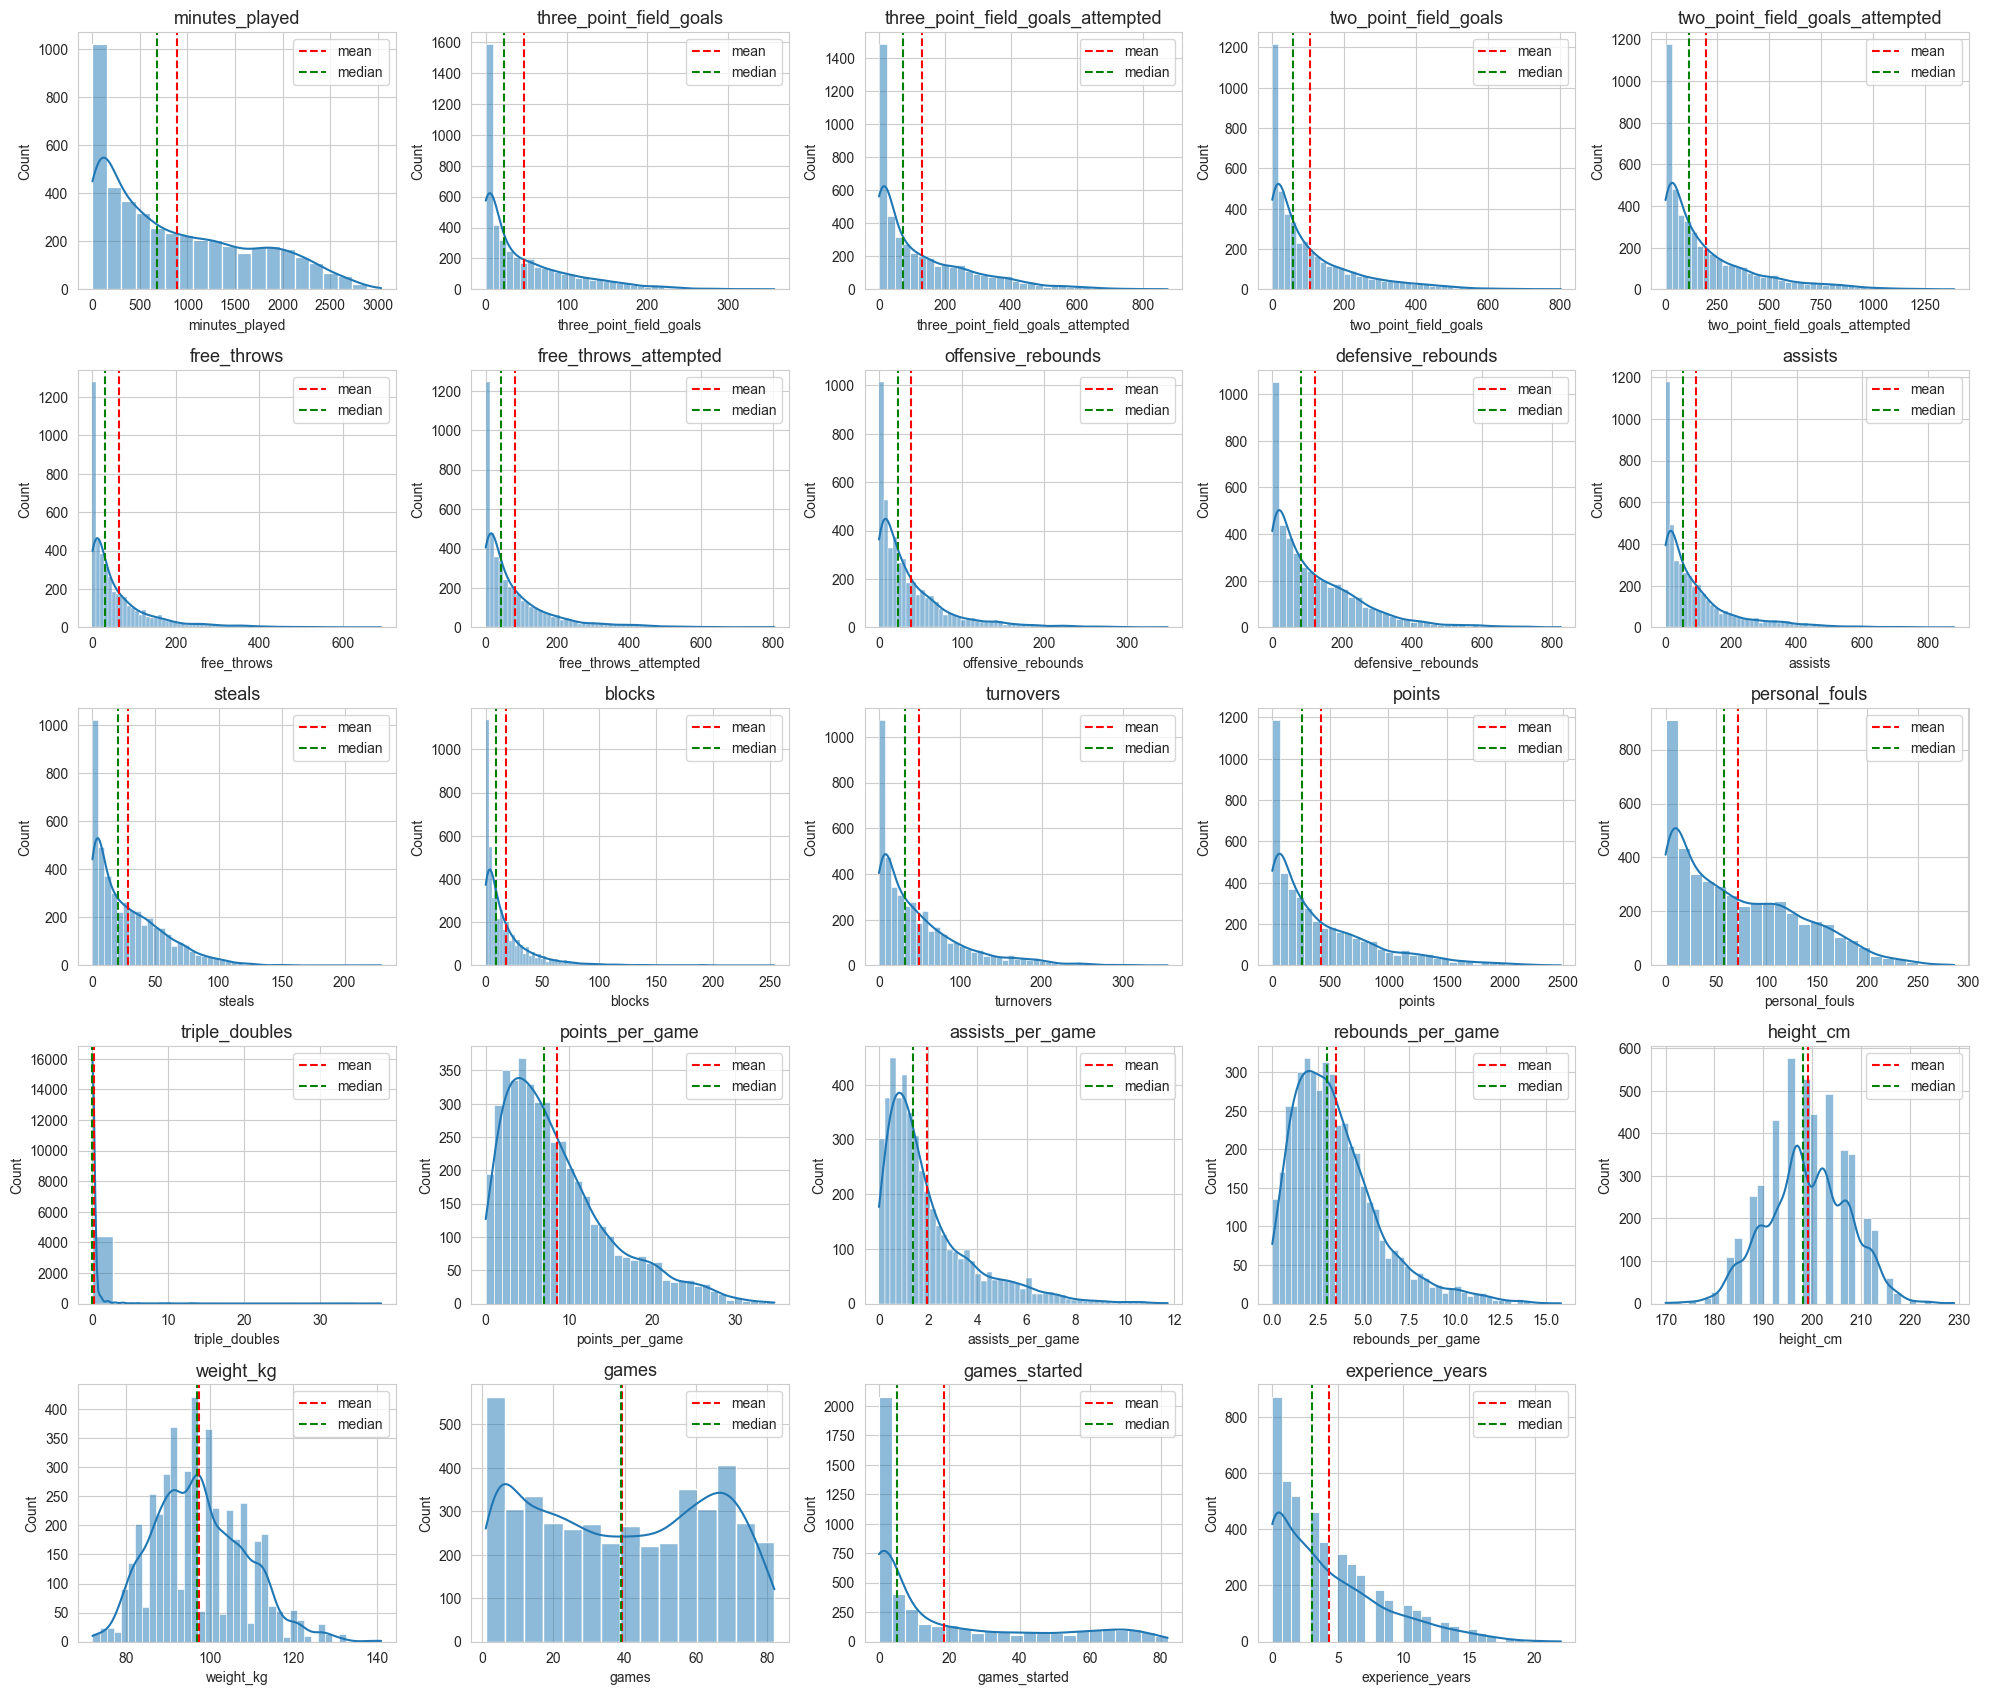

In [51]:
fig, axes = plt.subplots(6, 5, figsize=(20, 20))
axes = axes.flatten()

for ax, c in zip(axes, numeric_columns):
    sns.histplot(data[c].replace([np.inf, -np.inf], np.nan), kde=True, ax=ax)
    ax.axvline(data[c].mean(), color="red", linestyle="--", label="mean")
    ax.axvline(data[c].median(), color="green", linestyle="--", label="median")
    ax.set_title(c, fontsize=13)
    ax.legend(fontsize=10)

for ax in axes[len(numeric_columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### NaN percentage

In [52]:
def nan_percentage(df: pd.DataFrame) -> pd.DataFrame:
    total_rows = len(df)
    missing_count = [df[col].isna().sum() for col in df.columns]
    nan_pct = [(df[col].isna().sum() / total_rows) * 100 for col in df.columns]
    result = pd.DataFrame({"Missing Count": missing_count, "Nan Percent": nan_pct}, index=df.columns)
    return result.sort_values(by="Nan Percent", ascending=False)

In [53]:
nan_percentage(data)

,Missing Count,Nan Percent
draft_year,1192,26.412586
ft_pct,314,6.957678
effective_field_goal_percentage,37,0.819854
player_season_stats_id,0,0.000000
nba_debut,0,0.000000
triple_doubles,0,0.000000
name,0,0.000000
height_cm,0,0.000000
weight_kg,0,0.000000
birth_place,0,0.000000


In [54]:
# draft_year is missing precisely for undrafted players -- check the relationship
# between missing draft_year and having a recorded nba_debut
pd.crosstab(data["draft_year"].isna(), data["nba_debut"].notna())

nba_debut,True
draft_year,
False,3321
True,1192


## Cleaning Data

In [55]:
# draft_year is genuinely missing for undrafted players -- this is meaningful information,
# not noise, so it gets an explicit label instead of being dropped or median-filled
data["is_undrafted"] = data["draft_year"].isna().map({True: "Undrafted", False: "Drafted"})
data["is_undrafted"].value_counts()

is_undrafted
Drafted      3321
Undrafted    1192
Name: count, dtype: int64

### Impute NaNs

In [56]:
def fill_numeric(data, cols):
    data = data.copy()
    for c in cols:
        if data[c].isnull().sum() > 0:
            med = data[c].median()
            print(c, "->", data[c].isnull().sum(), "filled with median", round(med, 3))
            data[c] = data[c].fillna(med)
    return data

def fill_categorical(data, cols):
    data = data.copy()
    for c in cols:
        if data[c].isnull().sum() > 0:
            m = data[c].mode()[0]
            print(c, "->", data[c].isnull().sum(), "filled with mode", m)
            data[c] = data[c].fillna(m)
    return data

In [61]:
numeric_to_fill = ["ft_pct", "effective_field_goal_percentage"]

In [62]:
data = fill_numeric(data, numeric_to_fill)

ft_pct -> 314 filled with median 0.773
effective_field_goal_percentage -> 37 filled with median 0.529


In [63]:
print("Remaining missing values (excluding draft_year, kept as-is):",
      data.drop(columns=["draft_year"]).isnull().sum().sum())

Remaining missing values (excluding draft_year, kept as-is): 0


## Outliers, Binning & Reclassifying

### Outliers

In [64]:
def outlier_detector(col, method="iqr", k=1.5, z_thresh=3, clip=False) -> pd.Series:
    col = col.replace([np.inf, -np.inf], np.nan)

    if method == "iqr":
        q1, q3 = col.quantile(0.25), col.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (col < lower) | (col > upper)

        if clip:
            return col.clip(lower, upper)
        return mask

    elif method == "zscore":
        z = col.sub(col.mean()).div(col.std()).abs()
        mask = z > z_thresh

        if clip:
            mean, std = col.mean(), col.std()
            lower = mean - z_thresh * std
            upper = mean + z_thresh * std
            return col.clip(lower, upper)
        return mask

    elif method == "intersection":
        iqr_mask = outlier_detector(col, "iqr", k=k, clip=False)
        z_mask = outlier_detector(col, "zscore", z_thresh=z_thresh, clip=False)
        mask = iqr_mask & z_mask

        if clip:
            q1, q3 = col.quantile(0.25), col.quantile(0.75)
            iqr_val = q3 - q1
            iqr_lower, iqr_upper = q1 - k * iqr_val, q3 + k * iqr_val
            result = col.copy()
            result[mask] = result[mask].clip(iqr_lower, iqr_upper)
            return result
        return mask

In [65]:
for c in numeric_columns:
    print(c, int(outlier_detector(data[c]).sum()))

minutes_played 0
three_point_field_goals 161
three_point_field_goals_attempted 134
two_point_field_goals 255
two_point_field_goals_attempted 247
free_throws 331
free_throws_attempted 311
offensive_rebounds 292
defensive_rebounds 138
assists 345
steals 60
blocks 317
turnovers 225
points 147
personal_fouls 7
triple_doubles 254
points_per_game 166
assists_per_game 288
rebounds_per_game 166
height_cm 9
weight_kg 62
games 0
games_started 60
experience_years 44


### Binning

Binning turns a continuous variable into a smaller number of meaningful groups — useful when the
raw scale is noisy but a coarser grouping tells a clearer story (e.g. career stage instead of
exact years of experience).

In [66]:
def binning(data, col, method="custom", bins=5, thresholds=None, labels=None):

    df = data.copy()
    new_col = col + "_bin"

    if method == "equal width":
        df[new_col] = pd.cut(df[col], bins=bins, labels=labels)
    elif method == "quantile":
        df[new_col] = pd.qcut(df[col], q=bins, labels=labels, duplicates="drop")
    elif method == "custom":
        df[new_col] = pd.cut(df[col], bins=thresholds, labels=labels)

    print("column:", new_col)
    print("number of groups:", df[new_col].nunique())

    return df

In [67]:
data = binning(data, "height_cm", method="custom",
               thresholds=[0, 190, 198, 206, 260],
               labels=["Short (<190cm)", "Average (190-198cm)", "Tall (198-206cm)", "Very Tall (206cm+)"])
data["height_cm_bin"].value_counts().sort_index()

column: height_cm_bin
number of groups: 4


height_cm_bin
Short (<190cm)          849
Average (190-198cm)    1536
Tall (198-206cm)       1300
Very Tall (206cm+)      828
Name: count, dtype: int64

In [68]:
data = binning(data, "experience_years", method="custom",
               thresholds=[-0.01, 1, 4, 9, 30],
               labels=["Rookie", "Developing (2-4 yr)", "Prime (5-9 yr)", "Veteran (10+ yr)"])
data["experience_years_bin"].value_counts().sort_index()

column: experience_years_bin
number of groups: 4


experience_years_bin
Rookie                 1444
Developing (2-4 yr)    1333
Prime (5-9 yr)         1156
Veteran (10+ yr)        580
Name: count, dtype: int64

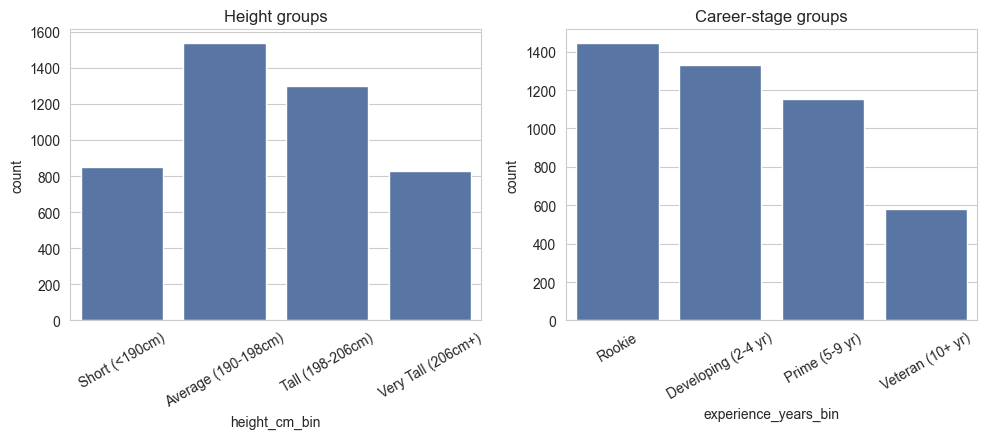

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

sns.countplot(data=data, x="height_cm_bin", color="#4C72B0", ax=axes[0])
axes[0].set_title("Height groups")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=data, x="experience_years_bin", color="#4C72B0", ax=axes[1])
axes[1].set_title("Career-stage groups")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Reclassifying categorical variables

In [70]:
def reclassify_categorical(data, col, mapping_fn, new_col=None):
    data = data.copy()
    new_col = new_col or f"{col}_recls"
    data[new_col] = data[col].apply(mapping_fn)
    return data

In [71]:
# US states (birth_place is a US state for domestic players, a country name otherwise)
US_STATES = {
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut",
    "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan",
    "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia",
    "Wisconsin", "Wyoming", "District of Columbia"
}

def origin_group(place):
    if pd.isna(place):
        return "Unknown"
    return "USA" if place in US_STATES else "International"

data = reclassify_categorical(data, "birth_place", origin_group, new_col="player_origin")
data["player_origin"].value_counts()

player_origin
USA              3493
International    1020
Name: count, dtype: int64

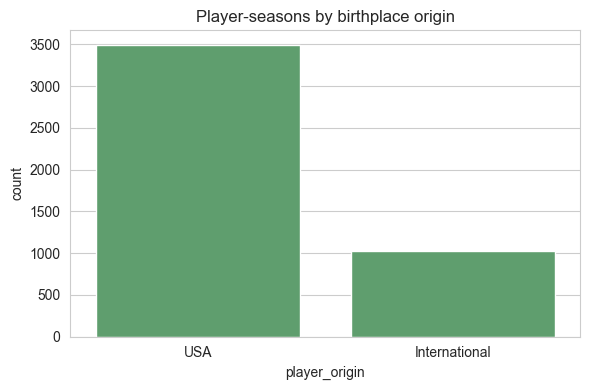

In [72]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="player_origin", color="#55A868")
plt.title("Player-seasons by birthplace origin")
plt.tight_layout()
plt.show()

### Final Columns

In [73]:
data.tail()

,player_season_stats_id,player_id,season_id,team_id,rank,position,games,games_started,minutes_played,three_point_field_goals,...,points_per_game,assists_per_game,rebounds_per_game,season_year,experience_years,win_mvp,is_undrafted,height_cm_bin,experience_years_bin,player_origin
4508,4509,2017,7,13,578,PF,8,0,32,0,...,0.125,0.125,0.375,2025,0,0,Undrafted,Tall (198-206cm),Rookie,International
4509,4510,1131,7,6,579,SG,1,0,3,0,...,0.000,0.000,1.000,2025,0,0,Undrafted,Short (<190cm),Rookie,USA
4510,4511,1308,7,5,580,PF,2,0,6,0,...,0.000,0.000,0.000,2025,0,0,Drafted,Tall (198-206cm),Rookie,International
4511,4512,1312,7,20,581,SF,5,0,8,0,...,0.000,0.000,0.400,2025,1,0,Undrafted,Tall (198-206cm),Rookie,International
4512,4513,1442,7,28,582,PG,2,0,13,0,...,0.000,1.000,0.500,2025,0,0,Undrafted,Short (<190cm),Rookie,USA


In [74]:
data.columns

Index(['player_season_stats_id', 'player_id', 'season_id', 'team_id', 'rank',
       'position', 'games', 'games_started', 'minutes_played',
       'three_point_field_goals', 'three_point_field_goals_attempted',
       'two_point_field_goals', 'two_point_field_goals_attempted',
       'effective_field_goal_percentage', 'free_throws',
       'free_throws_attempted', 'offensive_rebounds', 'defensive_rebounds',
       'assists', 'steals', 'blocks', 'turnovers', 'points', 'personal_fouls',
       'triple_doubles', 'name', 'height_cm', 'weight_kg', 'birth_place',
       'shoots', 'draft_year', 'nba_debut', 'experience_years_current_total',
       'is_active', 'team_name', 'season', 'ft_pct', 'points_per_game',
       'assists_per_game', 'rebounds_per_game', 'season_year',
       'experience_years', 'win_mvp', 'is_undrafted', 'height_cm_bin',
       'experience_years_bin', 'player_origin'],
      dtype='object')

## Column Descriptions

### 1) players_stats columns (raw per-player, per-season stats)
- **player_id**: Unique identifier for the player
- **team_id**: Identifier of the team the player played for that season
- **season_id**: Numeric identifier for the season
- **rank**: Player's rank for that season (e.g., in voting or a statistical leaderboard)
- **age**: Player's age during that season
- **position**: Player's position for that season (e.g., Guard, Forward, Center — may be a combination like "Forward and Center")
- **games**: Number of games played that season
- **games_started**: Number of games started as a starter
- **minutes_played**: Total minutes played that season
- **field_goal_percentage**: FG% = field_goals ÷ field_goals_attempted
- **three_point_field_goals**: Successful three-point shots made
- **three_point_field_goals_attempted**: Three-point shot attempts
- **three_point_field_goal_percentage**: 3P% success rate
- **two_point_field_goals**: Successful two-point shots made
- **two_point_field_goals_attempted**: Two-point shot attempts
- **two_point_field_goal_percentage**: 2P% success rate
- **effective_field_goal_percentage**: Shooting efficiency metric that accounts for the extra value of a 3-pointer: eFG% = (FG + 0.5 × 3P) ÷ FGA
- **free_throws**: Successful free throws made
- **free_throws_attempted**: Free throw attempts
- **free_throw_percentage**: FT% success rate
- **offensive_rebounds**: Rebounds collected on the offensive end
- **defensive_rebounds**: Rebounds collected on the defensive end
- **total_rebounds**: Sum of offensive and defensive rebounds
- **assists**: Passes leading directly to a made basket
- **steals**: Times the player took the ball away from an opponent
- **blocks**: Opponent shots blocked
- **turnovers**: Times the player lost possession of the ball
- **personal_fouls**: Personal fouls committed
- **points**: Total points scored that season
- **triple_doubles**: Games with double digits in three statistical categories (e.g., points, rebounds, assists)

### 2) players columns (player biography — static, not season-specific)
- **player_id**: Unique identifier for the player (join key to other tables)
- **name**: Player's full name
- **position**: Player's main/current position (dropped after the merge since it collides in name with the season-specific position, which is kept instead)
- **shoots**: Player's dominant shooting hand (Left/Right)
- **height_cm**: Player's height in centimeters
- **weight_kg**: Player's weight in kilograms
- **draft_year**: Year the player was drafted (empty if undrafted)
- **nba_debut**: Year of the player's first NBA appearance
- **experience_years**: Player's total career experience **as of today** (a static, current-total value, not season-specific — later renamed to experience_years_current_total)
- **is_active**: Whether the player is currently active in the league
- **birth_date**: Player's date of birth
- **birth_place**: Player's place of birth

### 3) mvp columns (MVP voting results)
- **player_id**: Identifier of the nominated/winning player
- **season_id**: Identifier of the season the vote was held for
- **team_id**: Identifier of the player's team that season
- **rank**: Player's rank in that season's MVP voting
- **first_place_votes**: Number of first-place votes received
- **points_won**: Total weighted score received from the voting
- **points_max**: Maximum possible score in that voting (used to normalize share)
- **share**: Player's share of the maximum possible score = points_won ÷ points_max
- **win_shares**: Advanced metric estimating how many of the team's wins the player "generated"
- **win_shares_per_48**: win_shares normalized per 48 minutes played (for fair comparison between players with different playing time)

### 4) Columns created in data (after merging and feature engineering)
- **team_name**: Team name (added from the teams table)
- **season**: Human-readable season label, e.g. "2020-21" (added from the seasons table)
- **ft_pct**: Free throw percentage, recomputed = free_throws ÷ free_throws_attempted
- **points_per_game**: Average points per game = points ÷ games
- **assists_per_game**: Average assists per game = assists ÷ games
- **rebounds_per_game**: Average total rebounds per game = (offensive_rebounds + defensive_rebounds) ÷ games
- **experience_years_current_total**: The original experience_years from the players table (the player's total career experience as of today, not season-specific) — renamed for clarity
- **season_year**: Starting calendar year of the season, parsed from the first 4 characters of season (e.g., 2020 from "2020-21")
- **experience_years**: Player's experience **specifically during that season** = season_year − nba_debut (floored at 0) — the corrected, season-specific version, replacing the static career-total value
- **win_mvp**: Binary target variable (0 or 1) — whether the player received at least one MVP vote that season (based on whether the (player_id, season_id) pair exists in the mvp table)
- **height_cm_bin**: Height binned into 4 groups: Short (<190cm), Average (190–198cm), Tall (198–206cm), Very Tall (206cm+)
- **experience_years_bin**: Season-specific experience binned into 4 groups: Rookie, Developing (2–4 yr), Prime (5–9 yr), Veteran (10+ yr)


In [86]:
numeric_columns_pp = [
    "rank", "games", "games_started", "minutes_played",
    "three_point_field_goals", "three_point_field_goals_attempted",
    "two_point_field_goals", "two_point_field_goals_attempted",
    "effective_field_goal_percentage",
    "free_throws", "free_throws_attempted",
    "offensive_rebounds", "defensive_rebounds",
    "assists", "steals", "blocks", "turnovers", "personal_fouls", "points", "triple_doubles",
    "height_cm", "weight_kg",
    "ft_pct", "points_per_game", "assists_per_game", "rebounds_per_game",
    "experience_years_current_total", "experience_years", "season_year"
]

categorical_columns_pp = [
    "position", "season", "shoots",
    "is_active", "is_undrafted", "player_origin",
    "height_cm_bin", "experience_years_bin",
    "win_mvp"
]

# Visualization

In [76]:
Blue = "#7B9FF9"
Orange = "#F7A98B"
TARGET_PALETTE = {0: Orange, 1: Blue}

FALLBACK_PALETTE = ["#7B9FF9", "#BDAF88", "#87A16A", "#DAB552", "#C0A2D4", "#66BB87"]

sns.set_theme(style="whitegrid", font_scale=1.0)

import matplotlib.colors as mcolors
import matplotlib.cm as cm

base = cm.get_cmap("coolwarm")
colors = base(np.linspace(0.20, 0.80, 256))
soft_coolwarm = mcolors.LinearSegmentedColormap.from_list("soft_coolwarm", colors)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_36840\2688169019.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = cm.get_cmap("coolwarm")


## Data overview after preprocessing

In [134]:
def overview_numeric(df, col, k=1.5):

    data = df[col].dropna()


    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    n_lower = (data < lower).sum()
    n_upper = (data > upper).sum()

    
    shapiro_stat, p_shapiro = stats.shapiro(data)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4)
    )

    fig.suptitle(
        col,
        fontsize=14,
        fontweight="bold"
    )

    # Boxplot
    sns.boxplot(
        x=data,
        ax=axes[0]
    )

    axes[0].set_title("Boxplot")

    axes[0].text(
        0.02,
        0.90,
        f"Lower outliers: {n_lower}",
        transform=axes[0].transAxes
    )

    axes[0].text(
        0.02,
        0.80,
        f"Upper outliers: {n_upper}",
        transform=axes[0].transAxes
    )

    # Histogram
    sns.histplot(
        data,
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title("Histogram + KDE")
    axes[1].set_xlabel(col)

    # Q-Q Plot
    stats.probplot(
        data,
        dist="norm",
        plot=axes[2]
    )

    axes[2].set_title(
        f"Q-Q Plot (p-value = {p_shapiro:.4f})"
    )

    plt.tight_layout()
    plt.show()

In [77]:
def plot_numeric_overview(df, numeric_cols, k=1.5):
    n = len(numeric_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.5 * n))

    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(numeric_cols):
        clean = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        q1, q3 = clean.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        n_lower = (clean < lower).sum()
        n_upper = (clean > upper).sum()

        sns.boxplot(x=clean, ax=axes[i, 0], color=Blue, fliersize=4)
        axes[i, 0].set_title(f"{col} - Boxplot  (lower: {n_lower}, upper: {n_upper})", fontsize=10)

        sns.histplot(clean, kde=True, ax=axes[i, 1], color=Blue, edgecolor="white")
        axes[i, 1].set_title(f"{col} - Histogram + KDE")

    plt.tight_layout()
    plt.show()

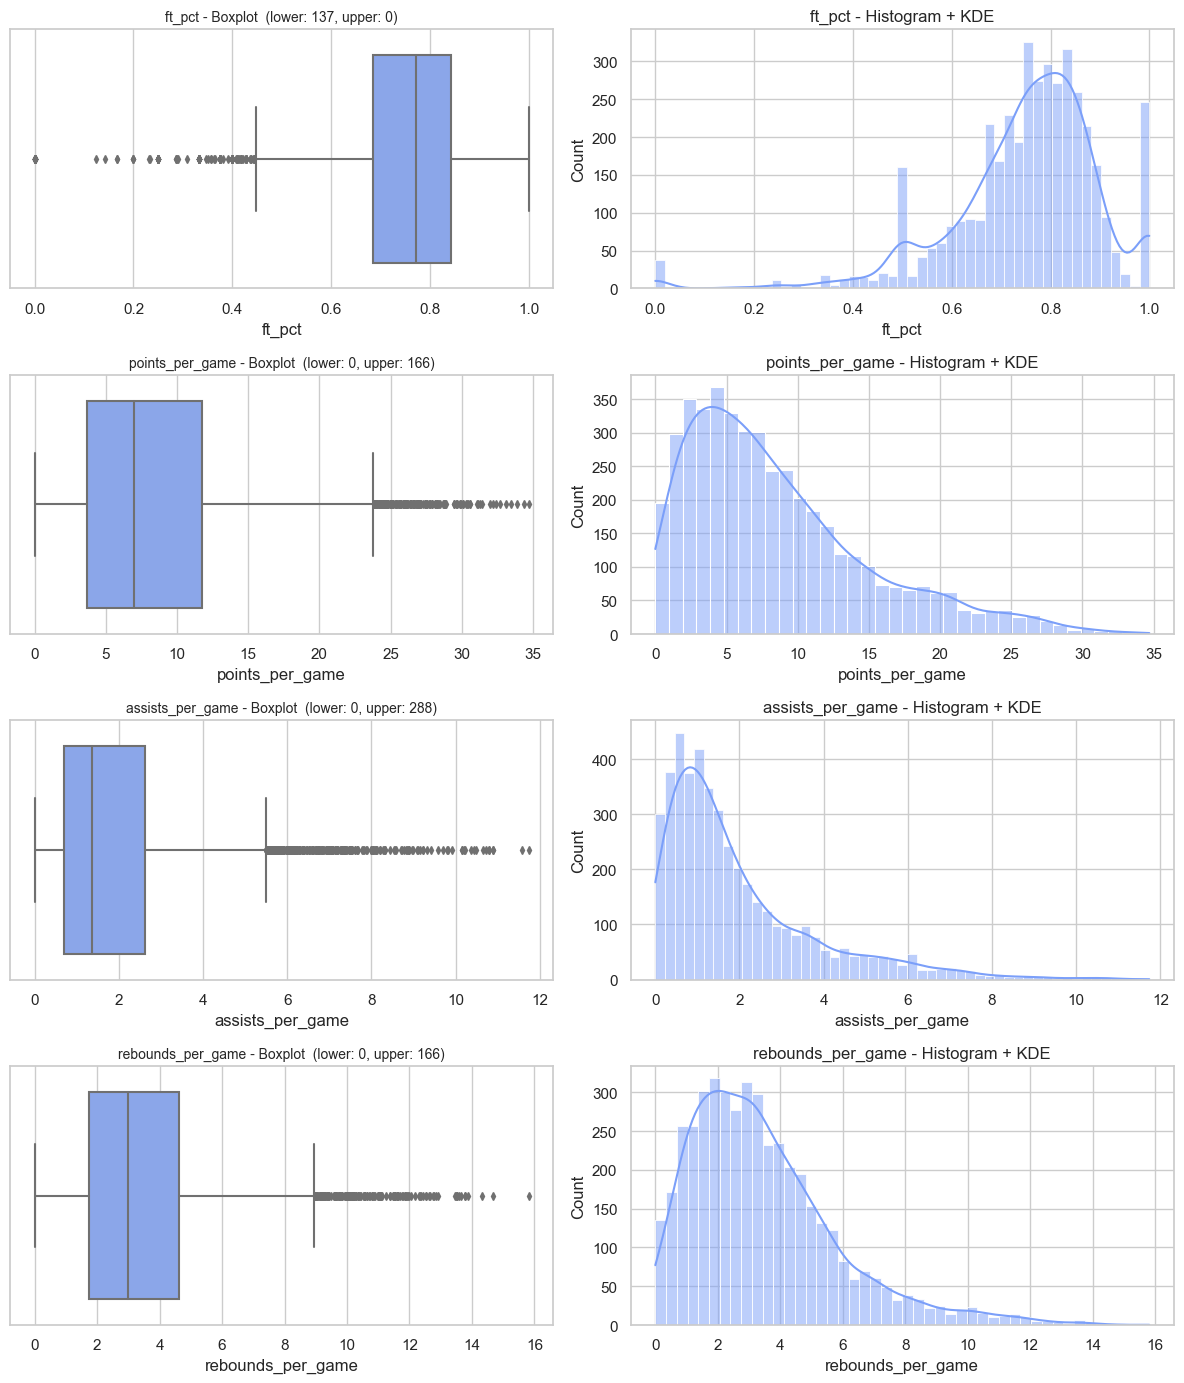

In [138]:
plot_numeric_overview(data, ["ft_pct", "points_per_game", "assists_per_game", "rebounds_per_game"], k=1.5)

In [80]:
def plot_categorical_overview(df, categorical_cols, ncols=3, top_n=8):
    n = len(categorical_cols)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(categorical_cols):
        ax = axes[i]
        counts = df[col].value_counts(dropna=False)

        # collapse long tails into "Other" so the pie stays readable
        if len(counts) > top_n:
            top = counts.iloc[:top_n]
            other = pd.Series({"Other": counts.iloc[top_n:].sum()})
            counts = pd.concat([top, other])

        # use the Target palette for binary 0/1 columns, fallback palette otherwise
        if set(counts.index) <= {0, 1}:
            colors = [TARGET_PALETTE[v] for v in counts.index]
        else:
            colors = [FALLBACK_PALETTE[j % len(FALLBACK_PALETTE)] for j in range(len(counts))]

        wedges, _, autotexts = ax.pie(
            counts,
            labels=counts.index.astype(str),
            autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
            colors=colors,
            startangle=90,
            pctdistance=0.78,
            wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
            textprops=dict(fontsize=9),
        )
        for t in autotexts:
            t.set_color("white")
            t.set_fontweight("bold")

        ax.set_title(col, fontsize=12, fontweight="bold", y=1.0)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Categorical Columns Overview", fontsize=16, fontweight="bold")
    plt.tight_layout(pad=1.5, w_pad=2.5, h_pad=1.5, rect=[0, 0, 1, 0.97])
    plt.show()

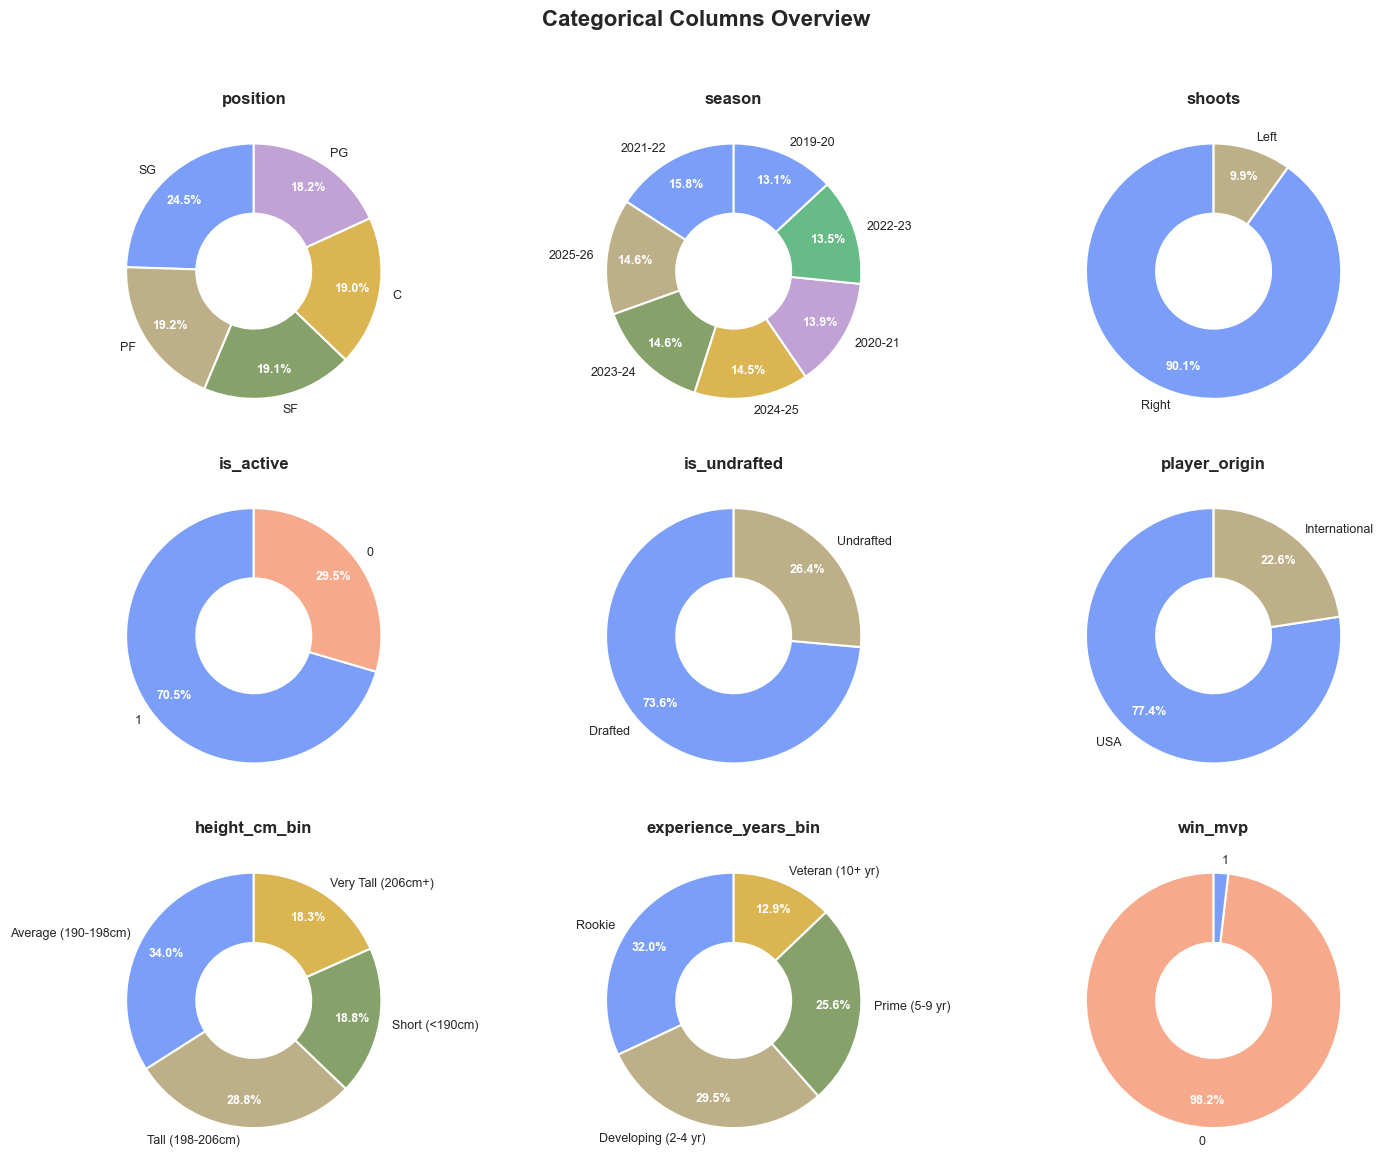

In [81]:
plot_categorical_overview(data, categorical_columns_pp)

## Correlation Overview

#### For numeric columns

In [82]:
def corr_heatmap(numeric_df, method="spearman"):
    cor = numeric_df.corr(method=method)
    plt.figure(figsize=(20,10))
    sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0,
                annot_kws={"size": 10})
    plt.title(f"Correlation Heatmap: {method}")
    plt.tight_layout()
    plt.show()

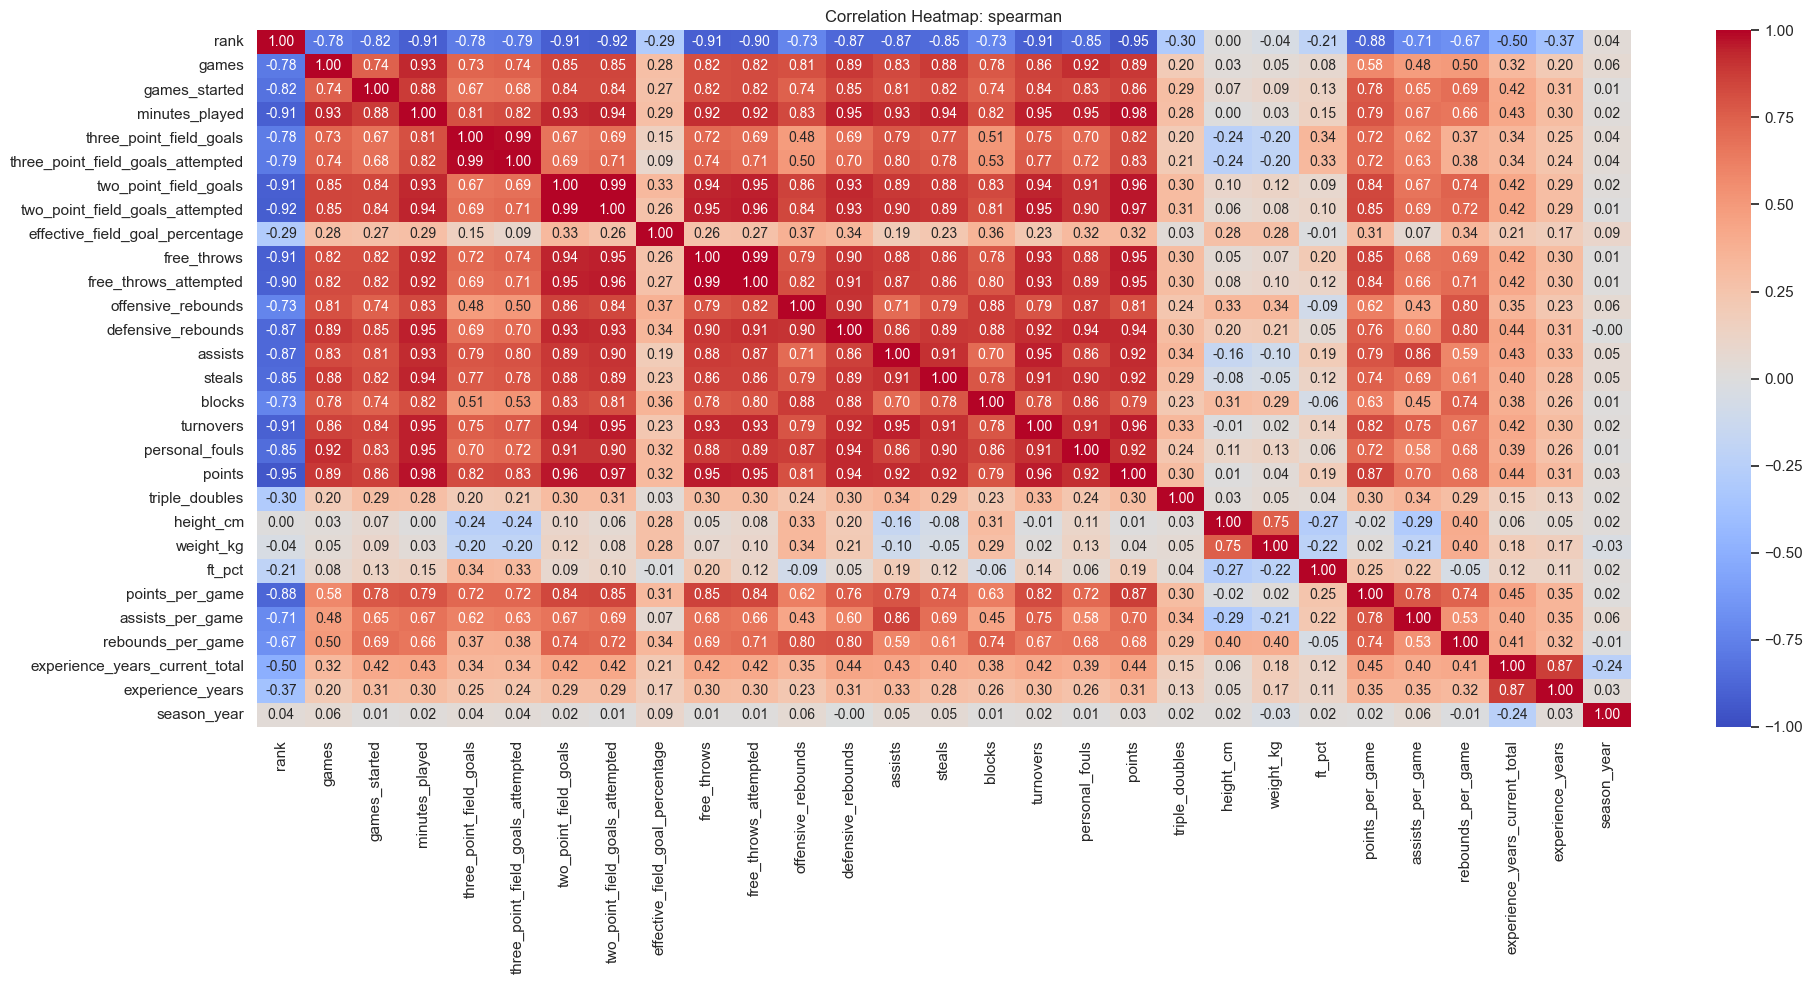

In [87]:
corr_heatmap(data[numeric_columns_pp], method="spearman")

## Two-variable comparison

### Numeric vs Categorical Plot

In [88]:
def numeric_vs_categorical_plot(df, col, target="win_mvp"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f"{col} by {target}", fontsize=14, fontweight="bold")

    target_values = sorted(df[target].dropna().unique())
    if set(target_values).issubset(TARGET_PALETTE.keys()):
        palette = TARGET_PALETTE
    else:
        palette = dict(zip(target_values, FALLBACK_PALETTE[:len(target_values)]))

    sns.histplot(data=df, x=col, hue=target, multiple="stack", palette=palette, ax=axes[0])
    axes[0].set_title("Stacked count")

    sns.histplot(data=df, x=col, hue=target, multiple="fill", palette=palette, ax=axes[1])
    axes[1].set_title("Proportion")

    sns.boxplot(data=df, x=target, y=col, palette=palette, ax=axes[2])
    axes[2].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

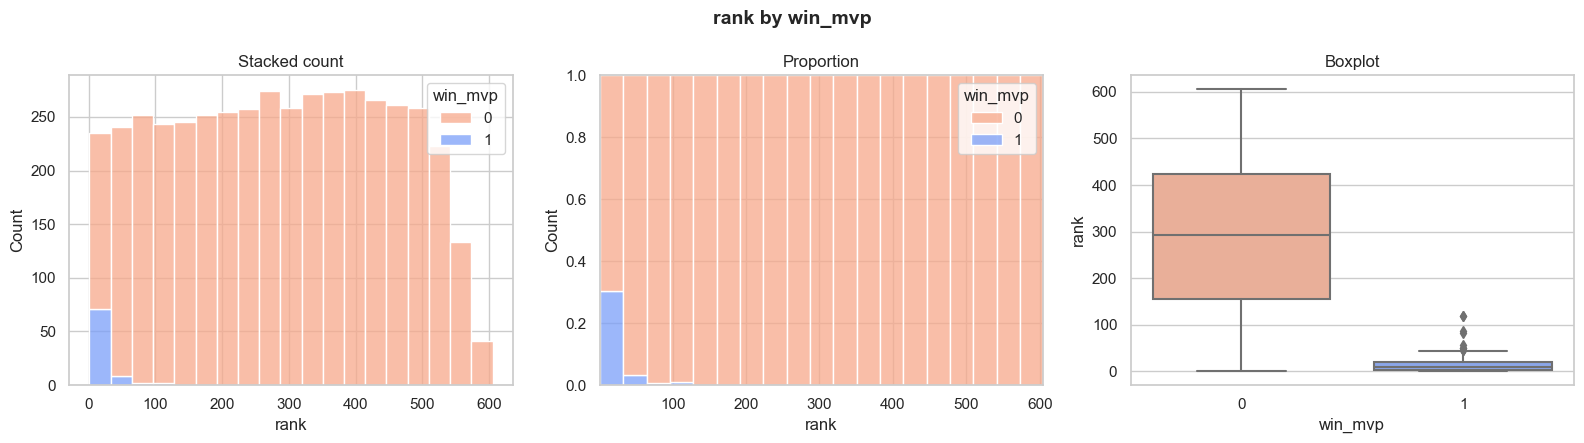

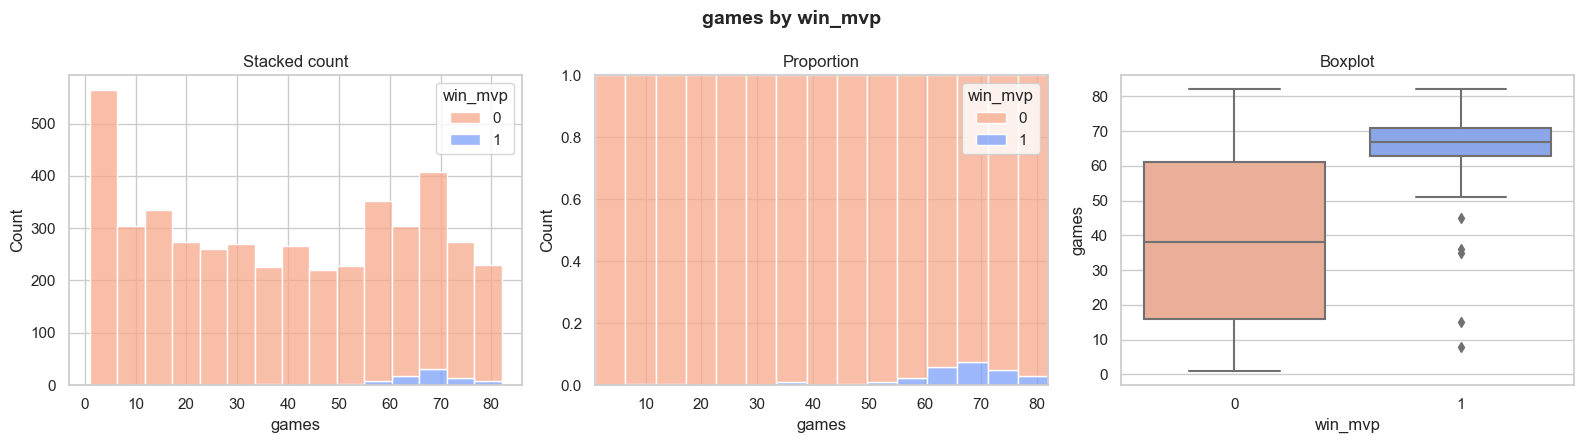

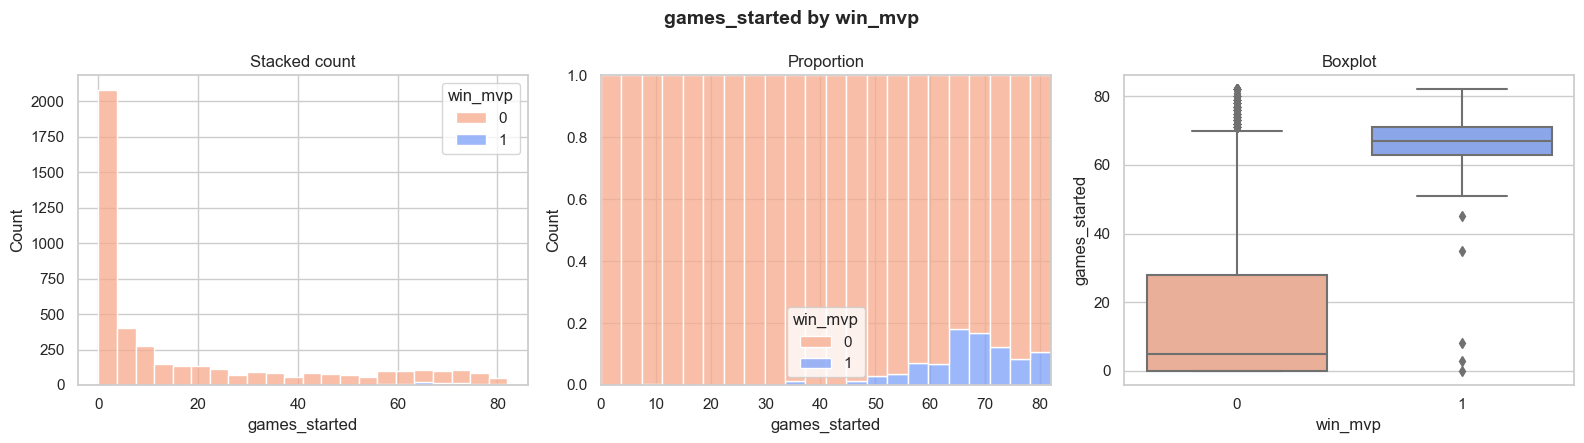

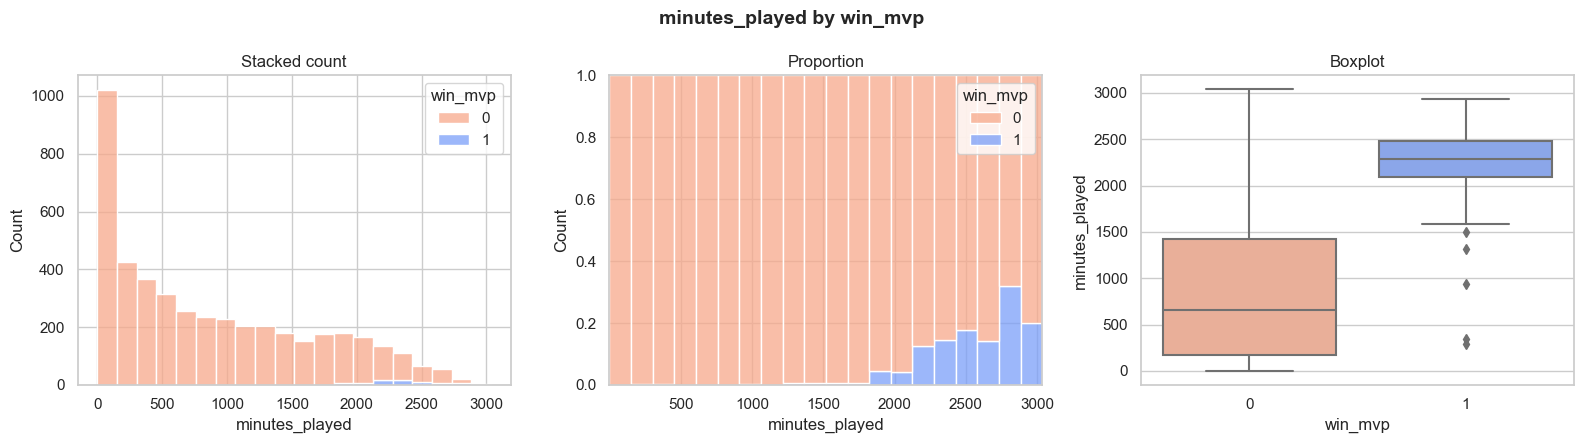

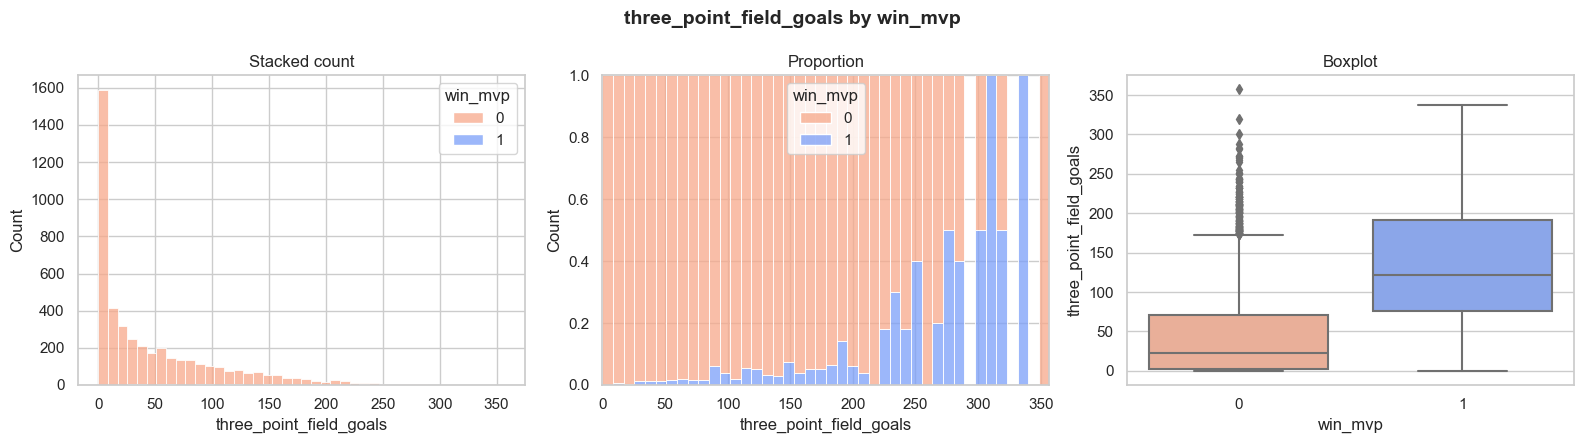

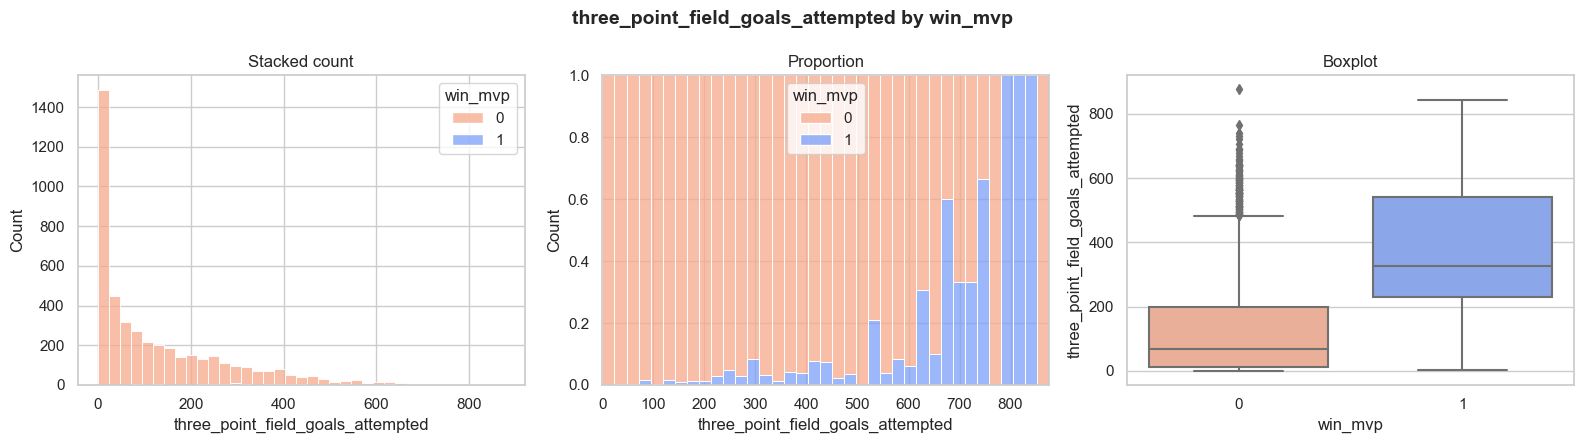

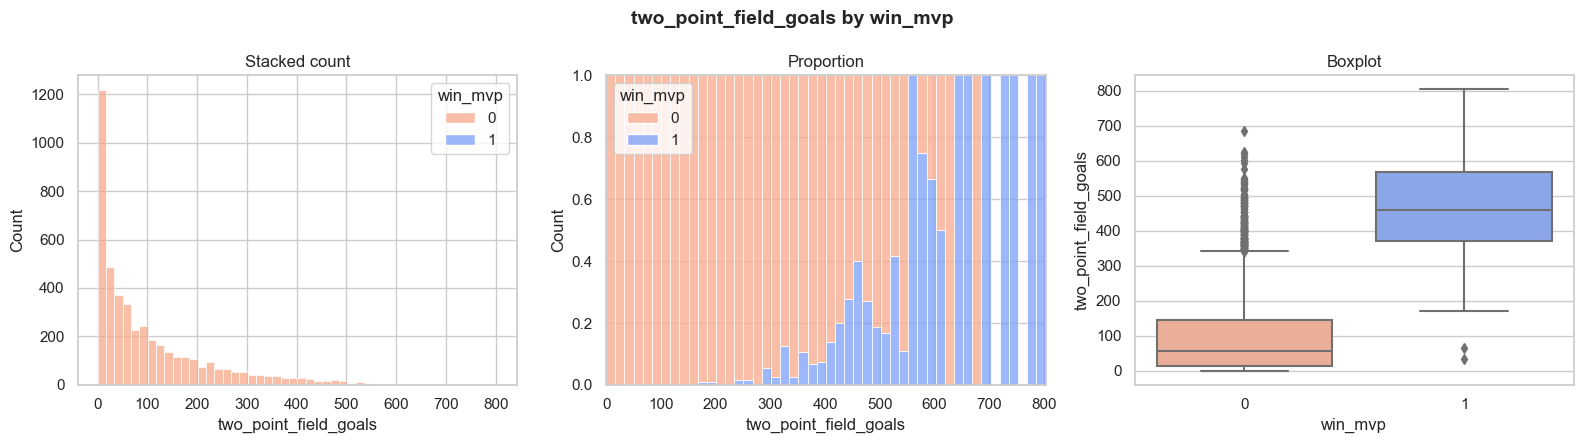

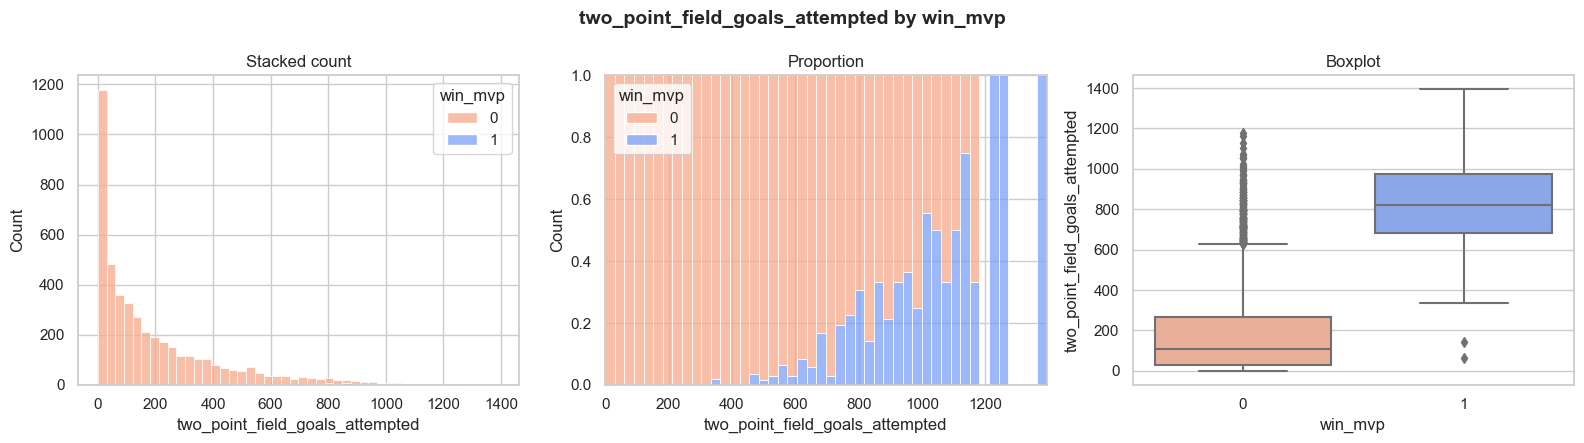

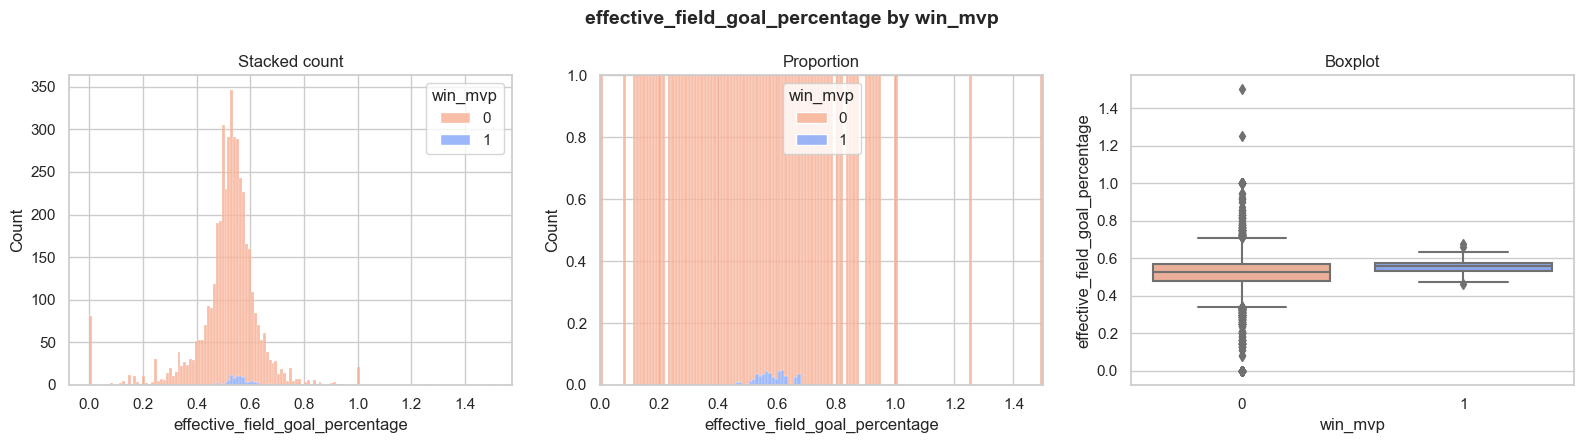

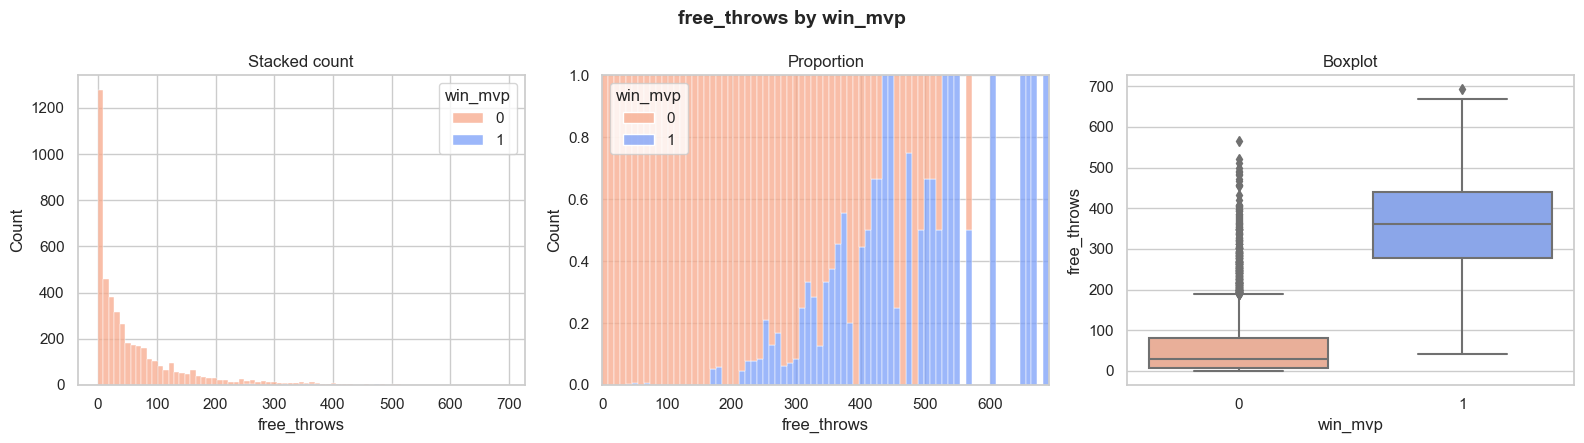

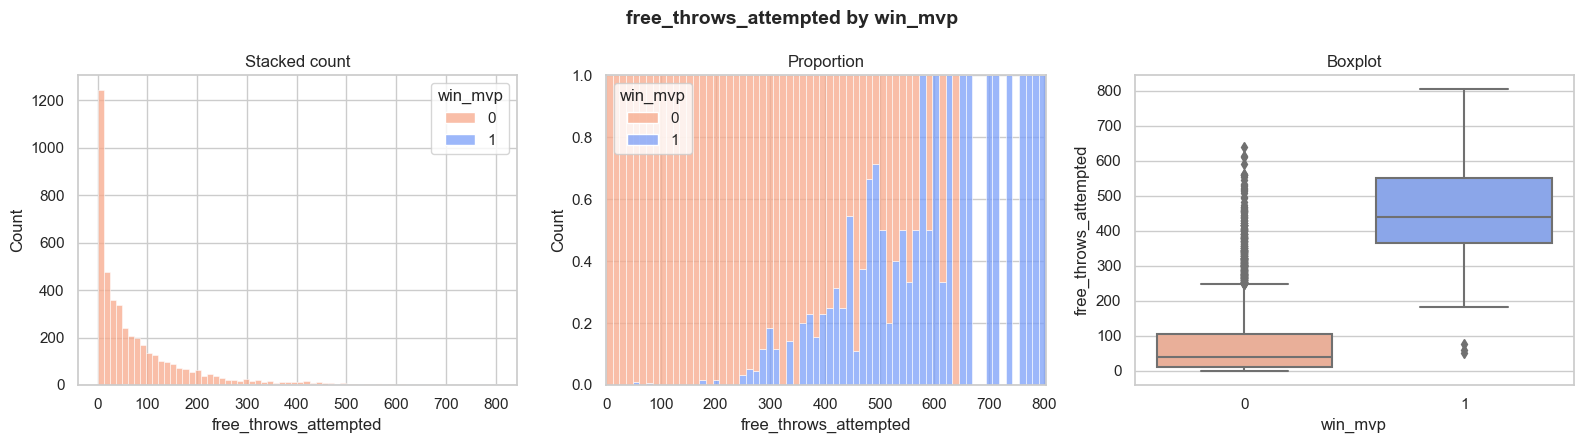

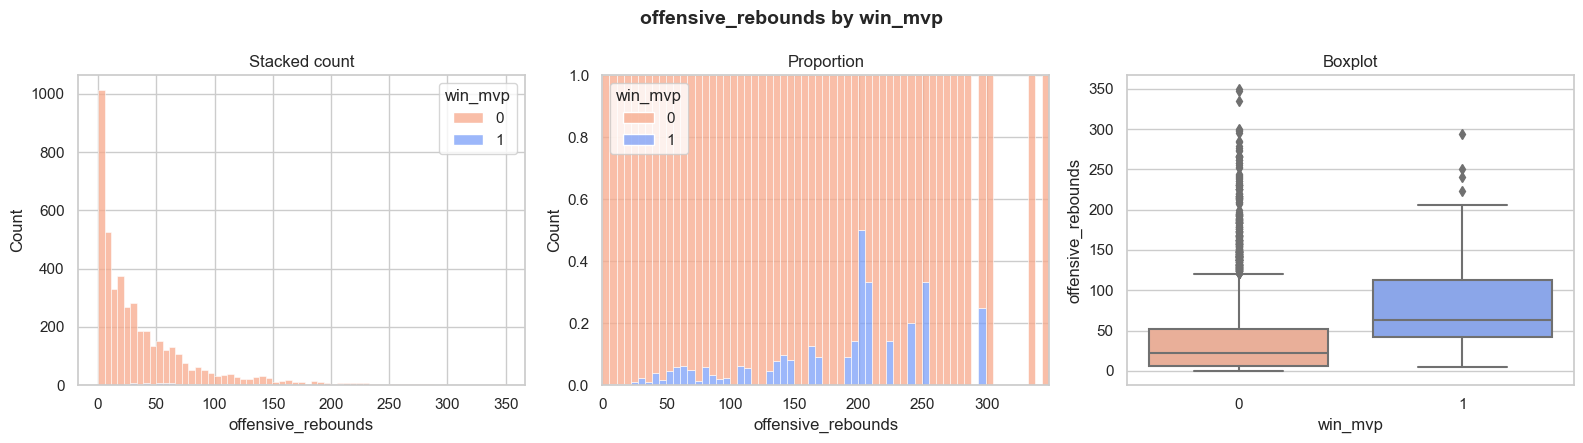

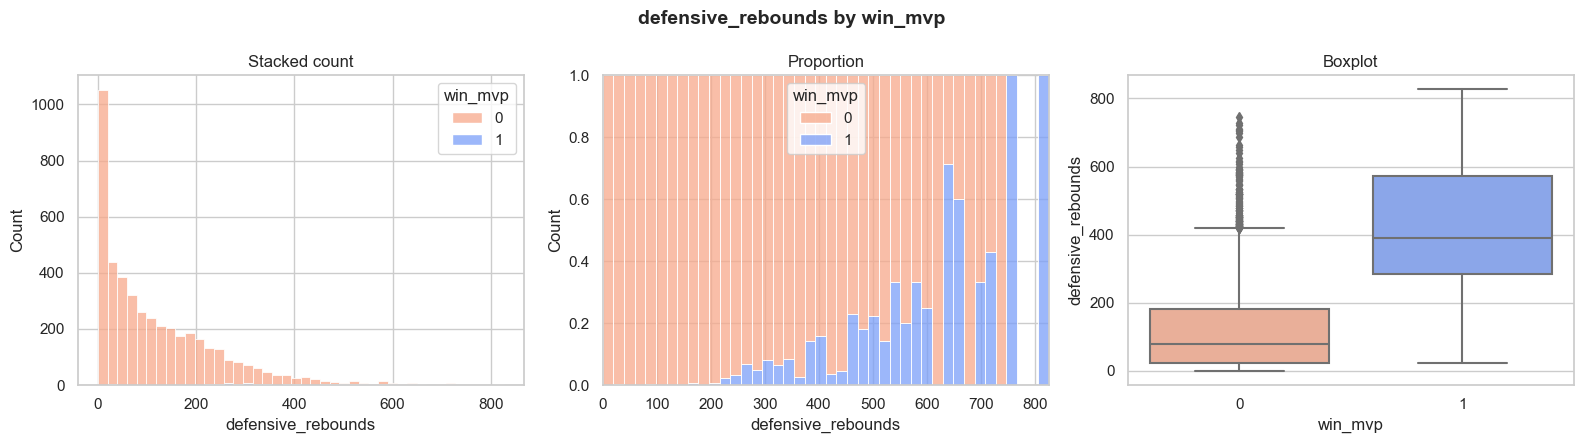

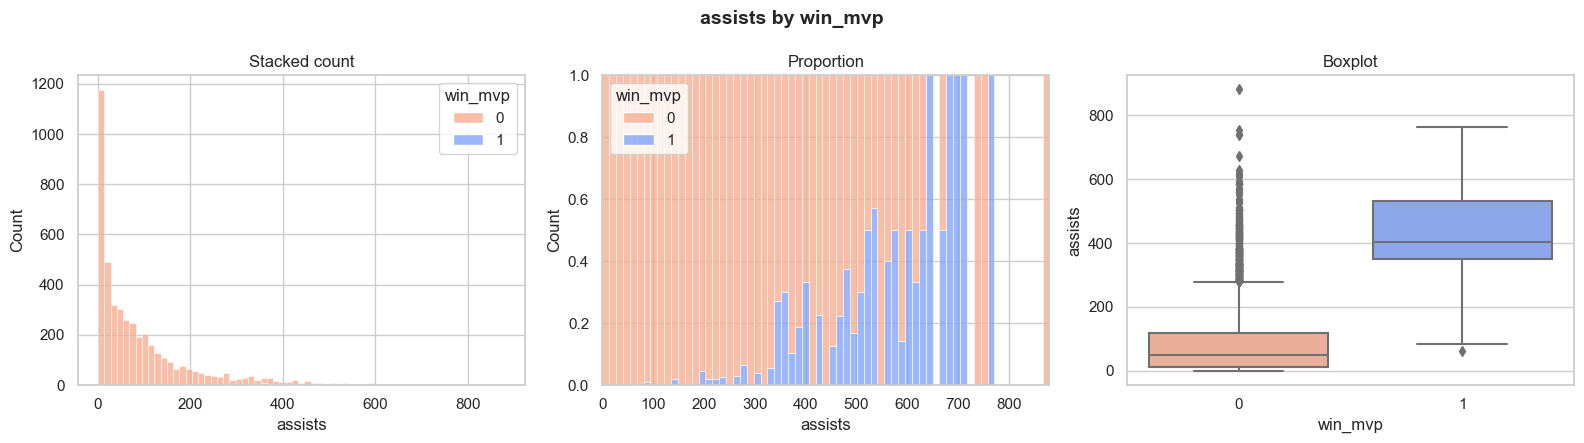

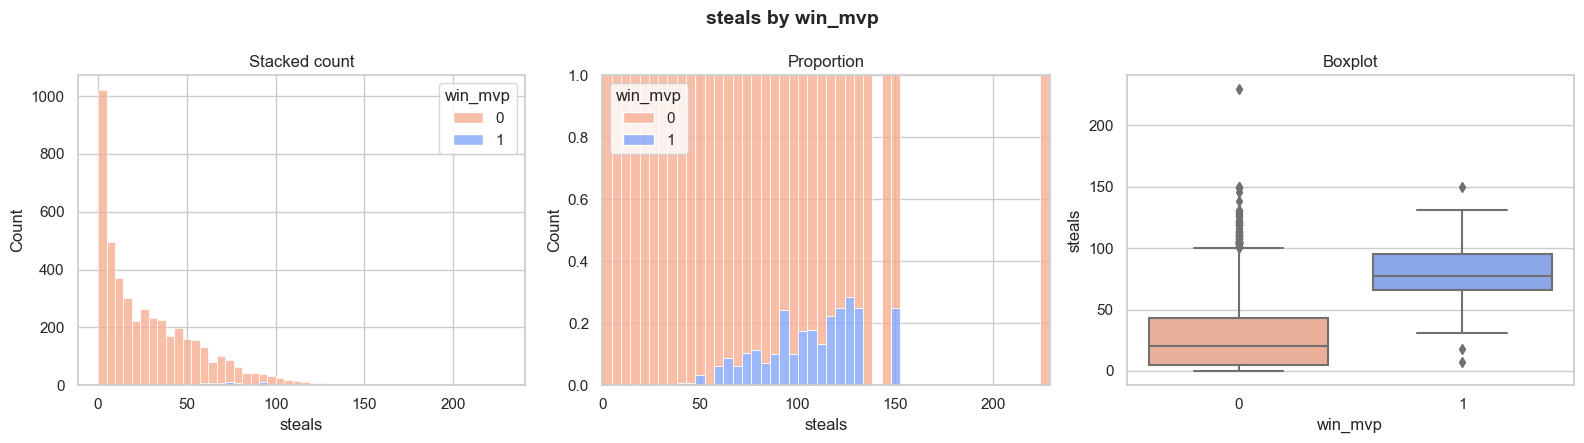

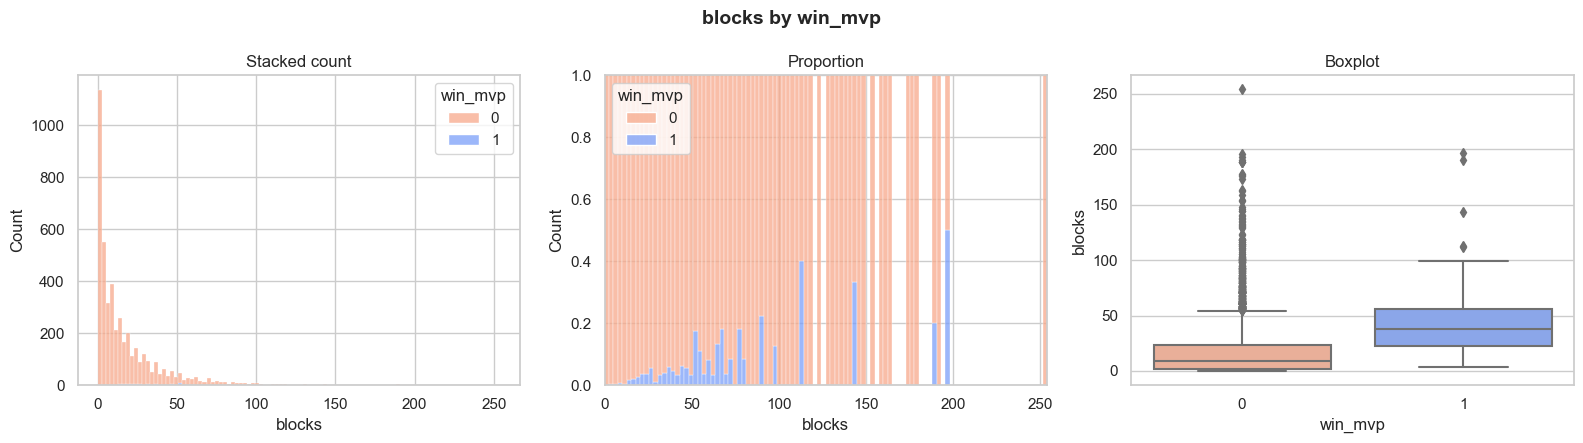

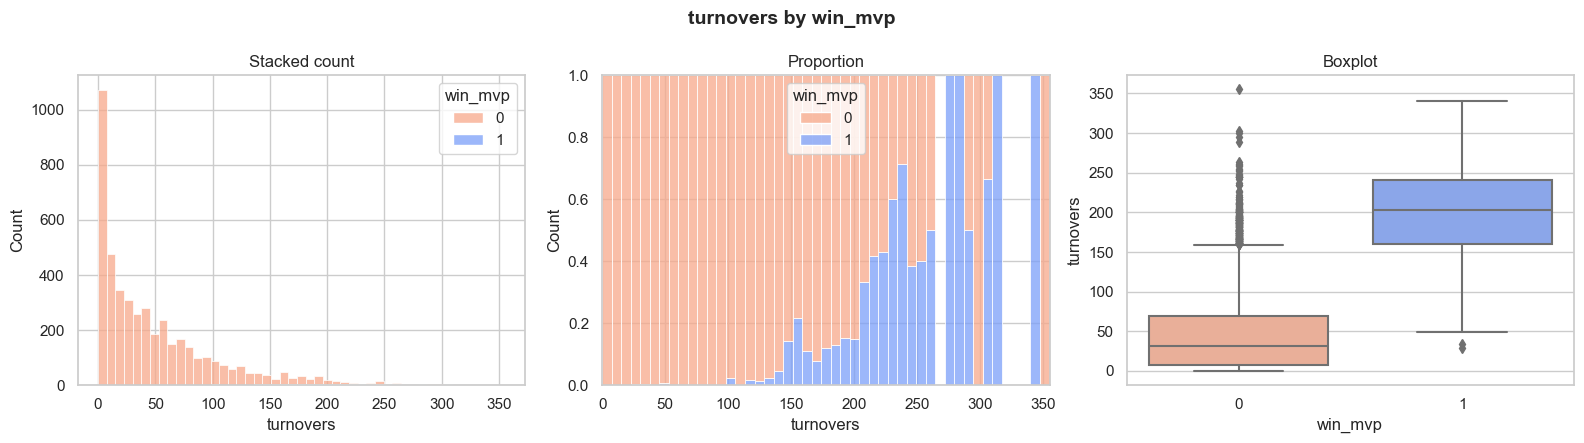

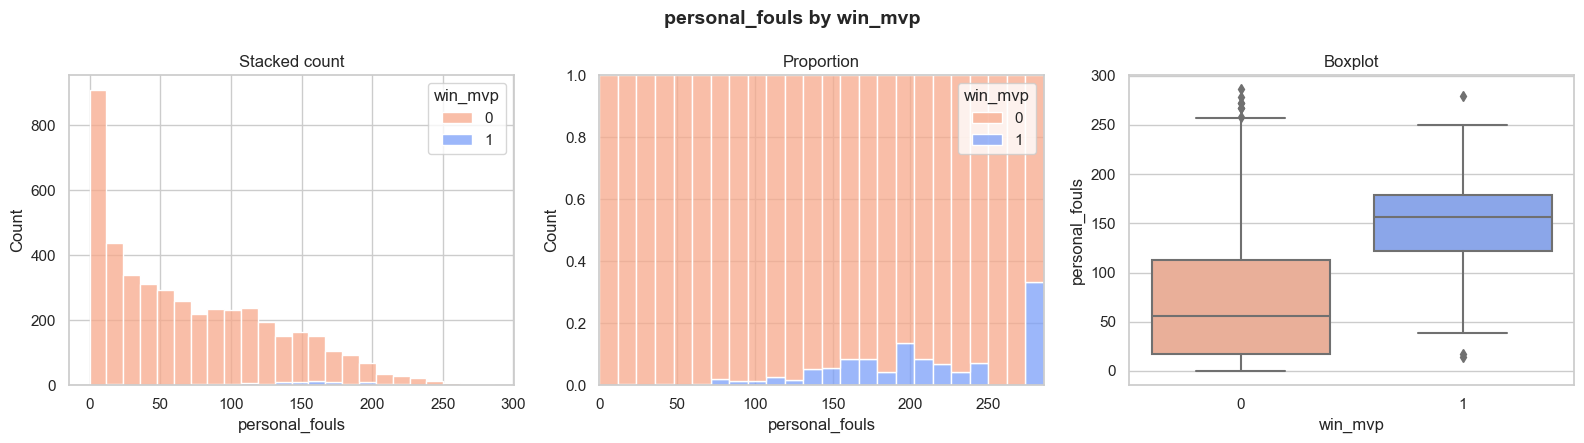

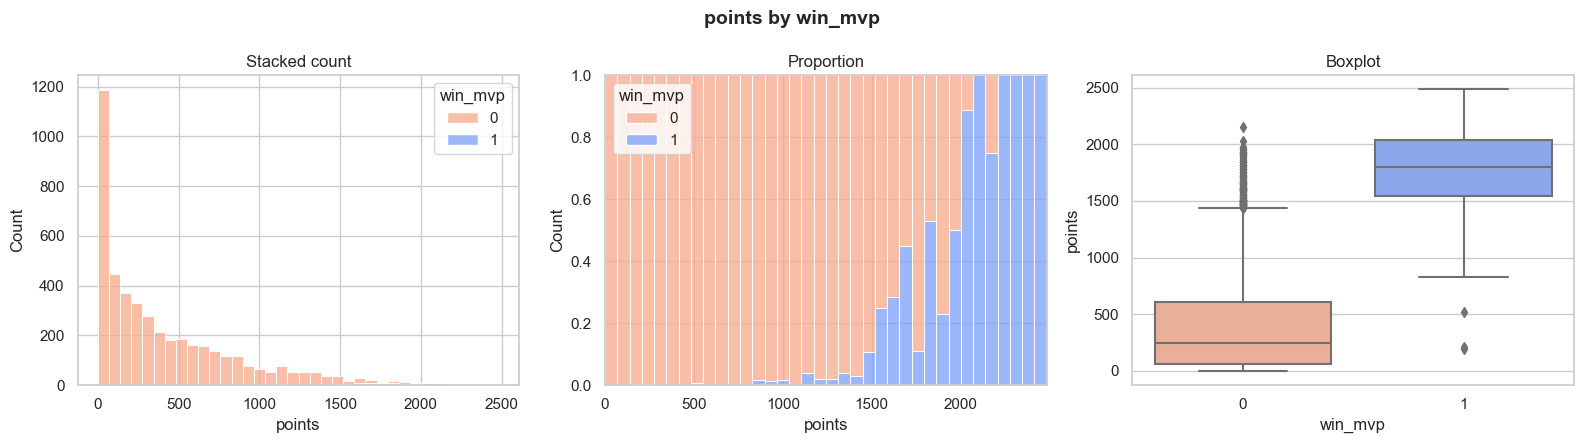

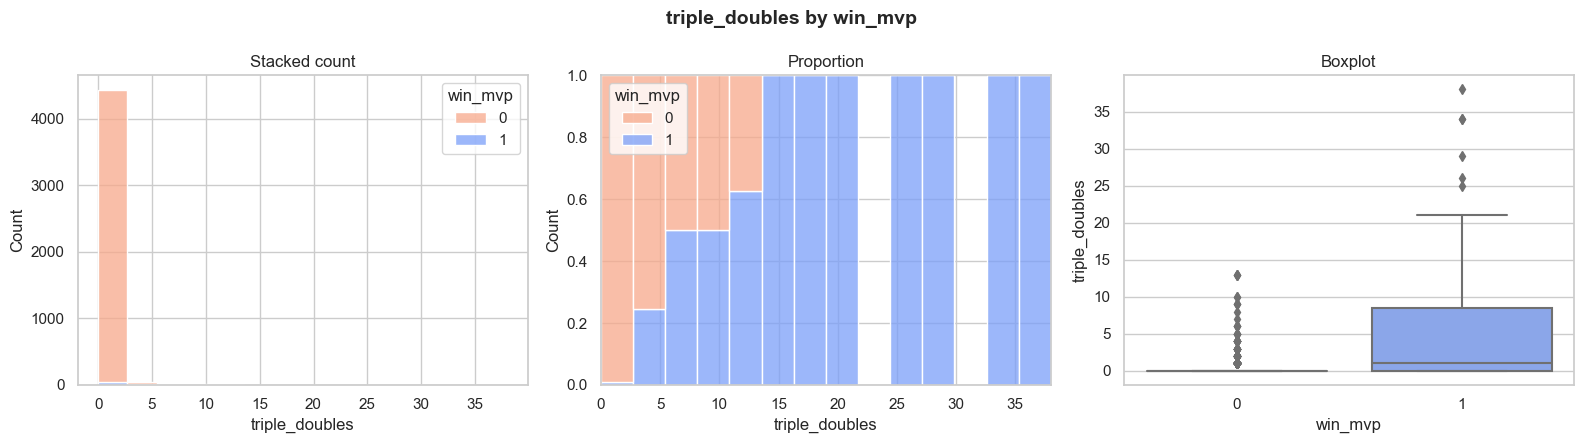

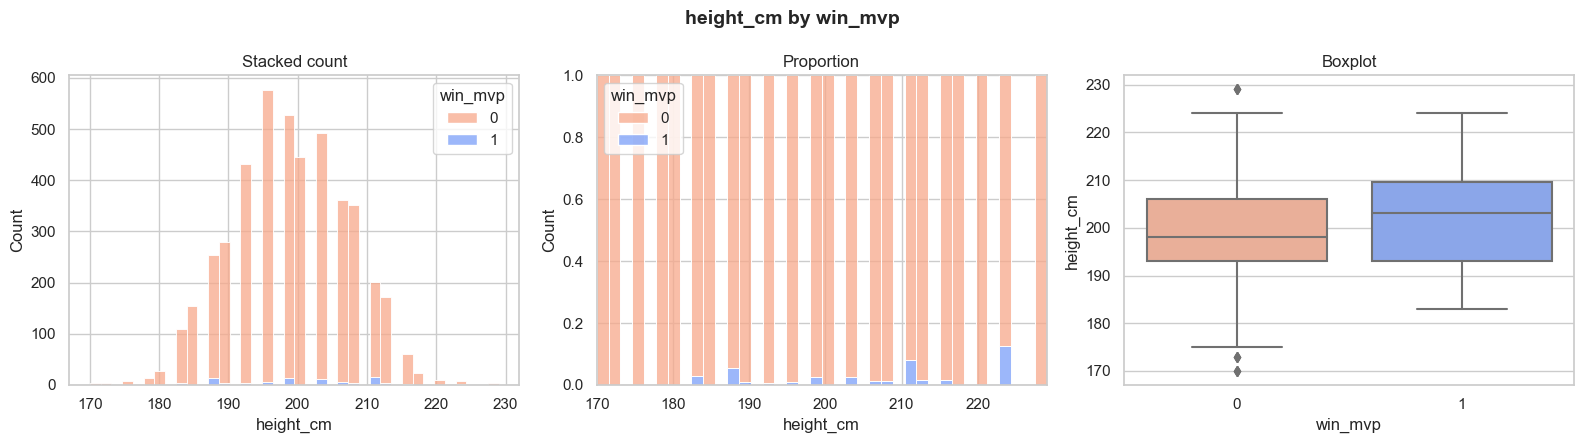

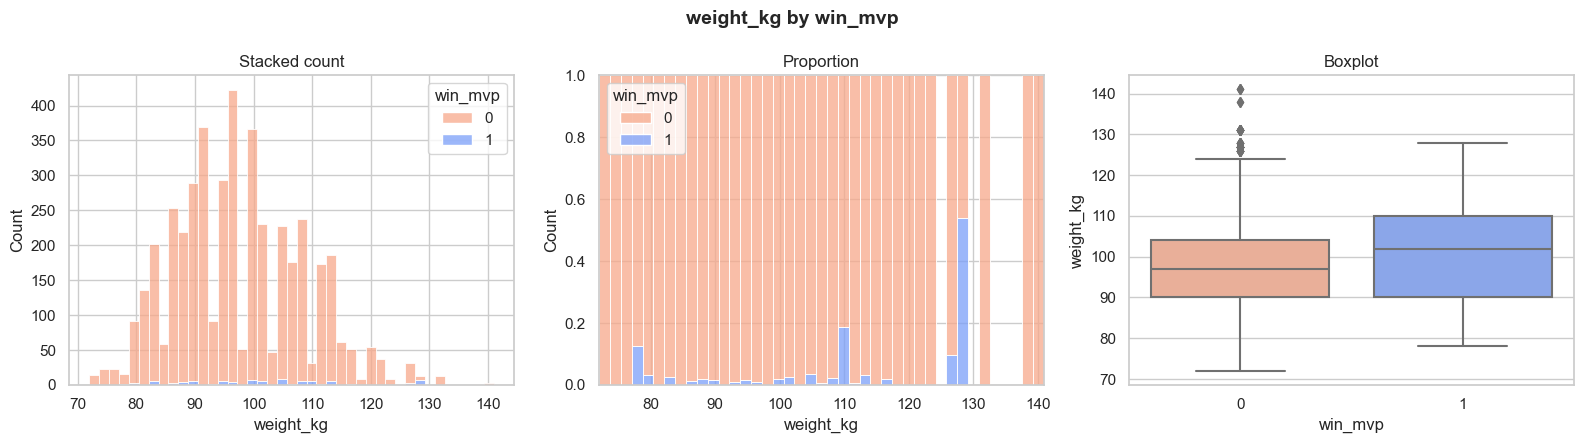

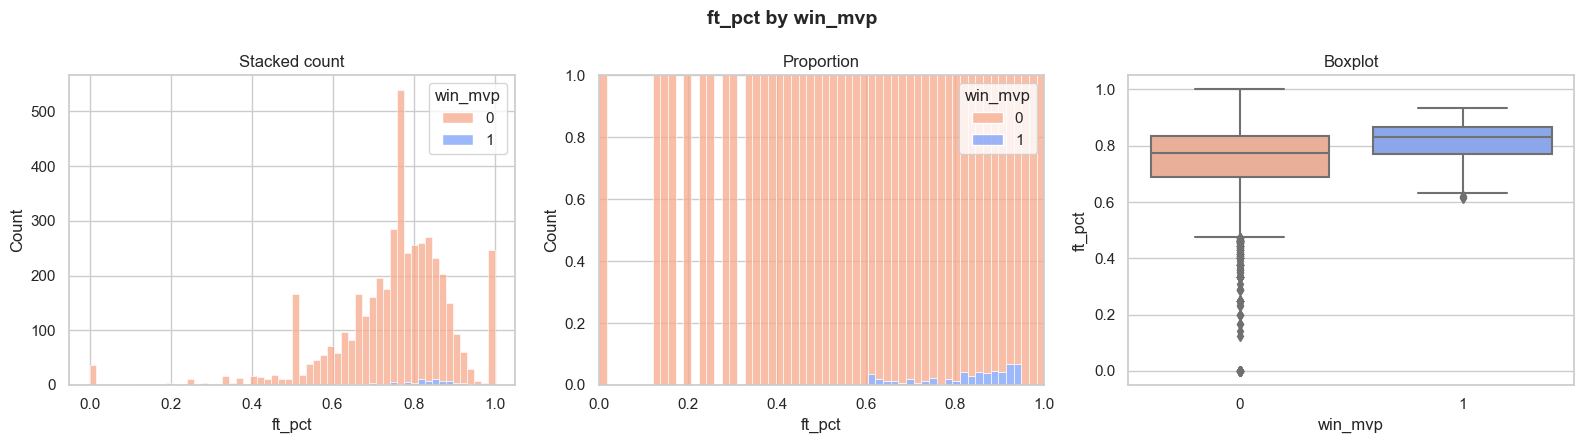

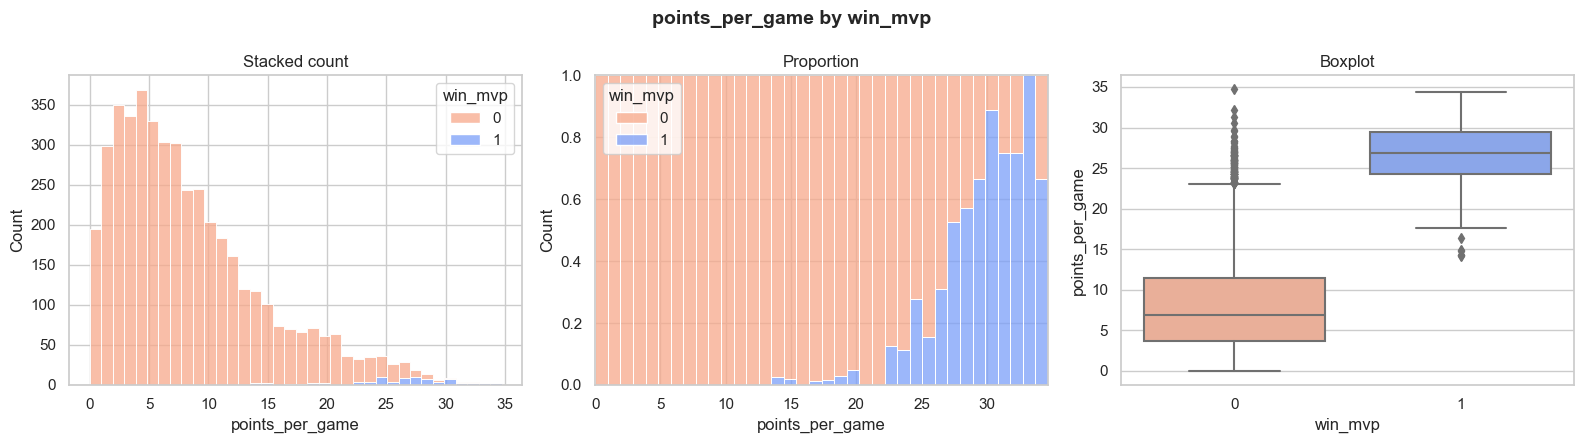

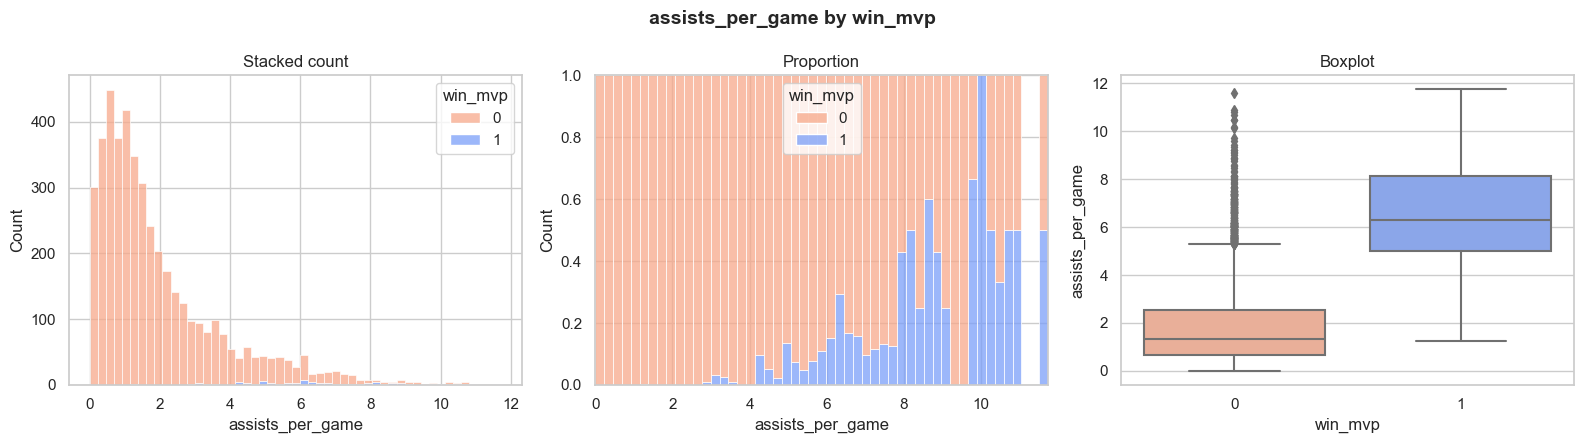

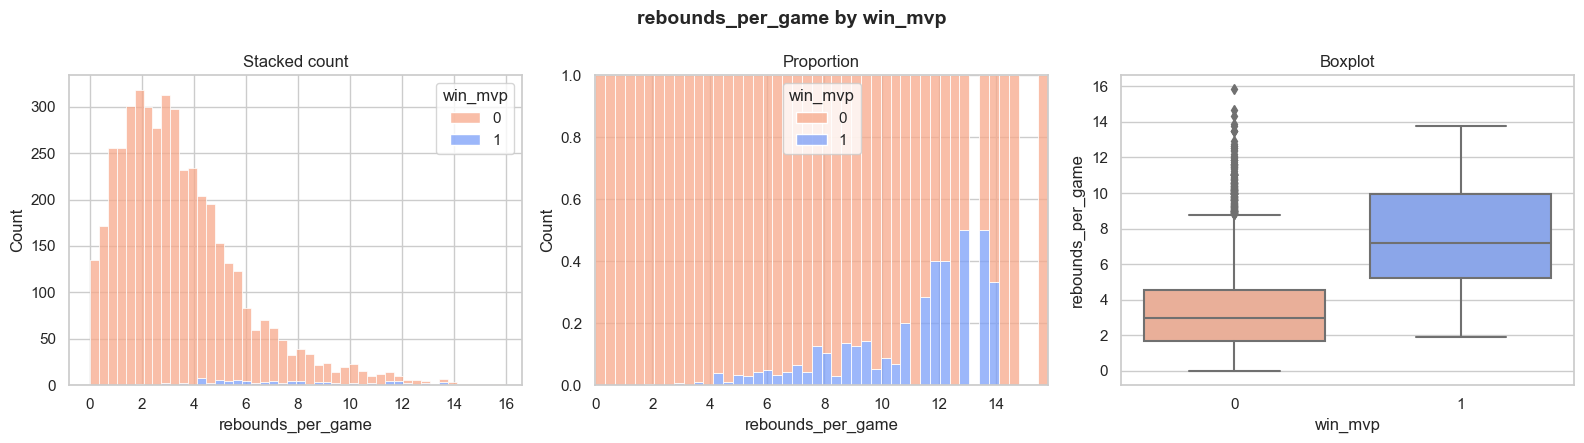

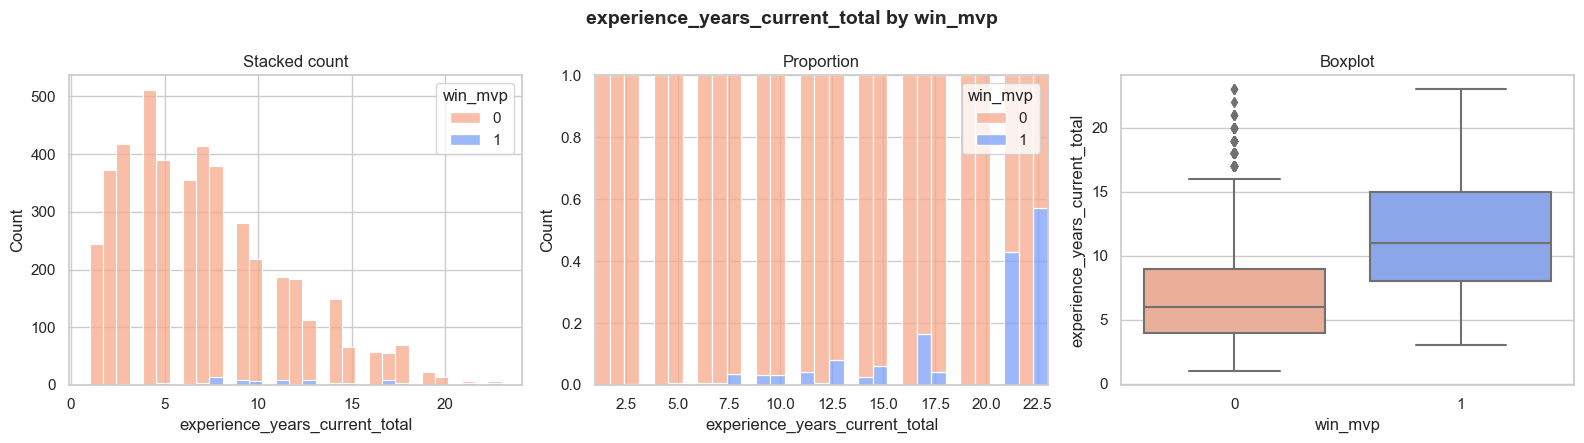

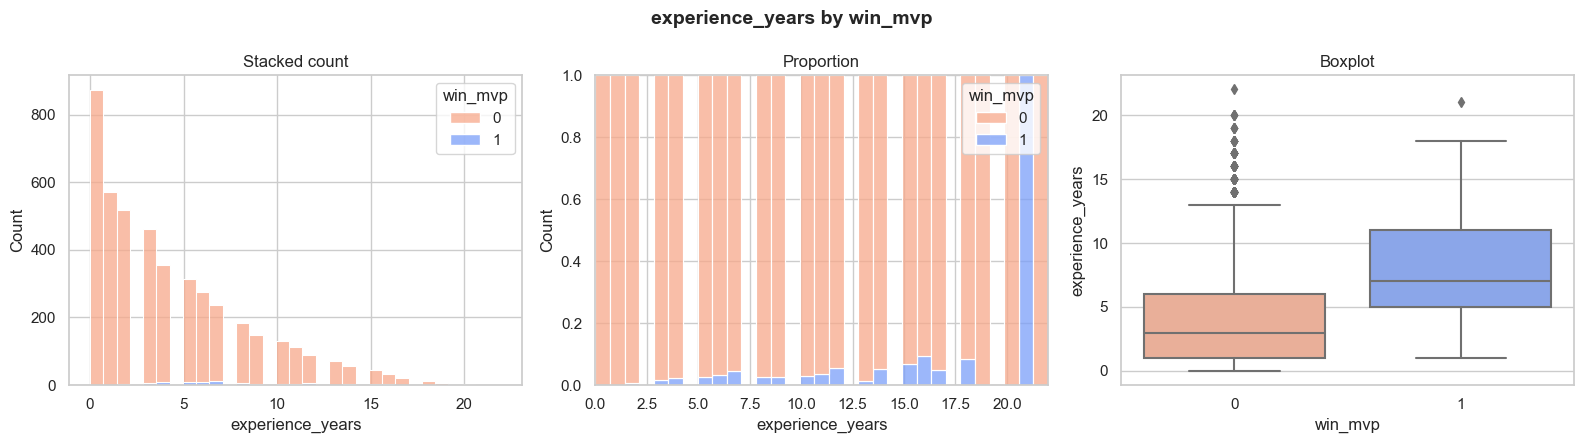

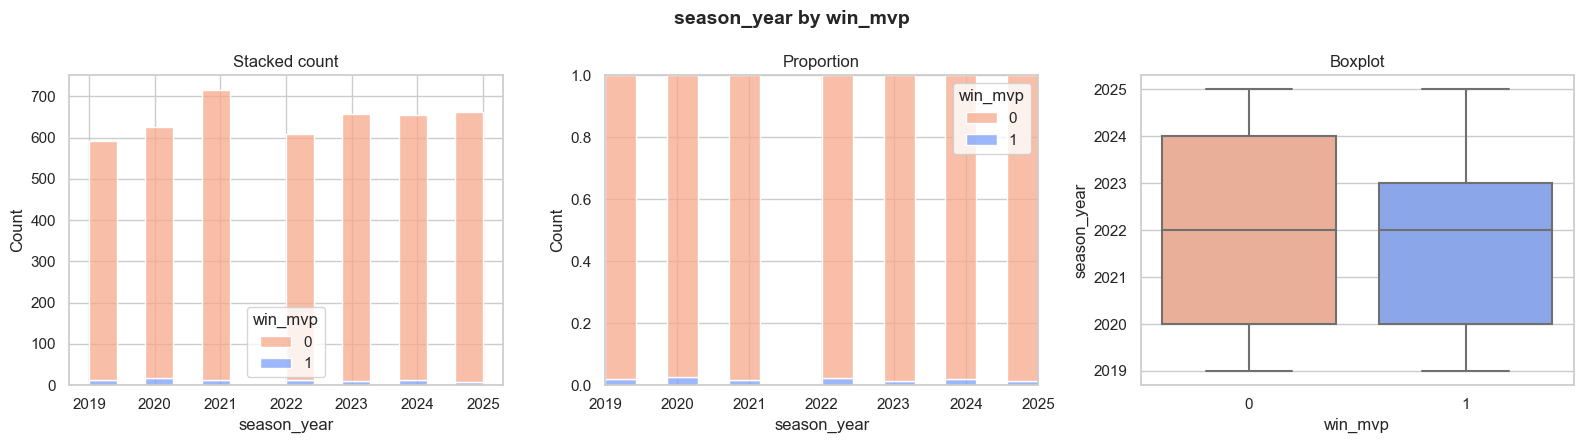

In [89]:
for col in numeric_columns_pp:
    numeric_vs_categorical_plot(data, col)

### Categorical vs Categorical Plot

In [90]:
def two_categorical_plot(df, col, target="win_mvp"):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), squeeze=False)
    fig.suptitle(col, fontsize=14, fontweight="bold")

    order = df[col].value_counts().index
    target_values = sorted(df[target].dropna().unique())

    if set(target_values).issubset(TARGET_PALETTE.keys()):
        palette = TARGET_PALETTE
    else:
        palette = dict(zip(target_values, FALLBACK_PALETTE[:len(target_values)]))

    # cont_table = pd.crosstab(df[col], df[target])
    # sns.heatmap(cont_table, annot=True, fmt=".0f", cmap=soft_coolwarm, cbar=False, ax=axes[0, 0])

    prop_table = pd.crosstab(df[col], df[target], normalize="index")
    sns.heatmap(prop_table, annot=True, fmt=".2%", cmap=soft_coolwarm, cbar=False, ax=axes[0, 0])

    sns.countplot(data=df, x=col, hue=target, order=order, palette=palette, ax=axes[0, 1])
    axes[0, 1].tick_params(axis="x", rotation=45)
    axes[0, 1].set_title("Grouped count")

    # ct = pd.crosstab(df[col], df[target], normalize="index").reindex(order)
    # ct.plot(kind="bar", stacked=True, color=[palette[v] for v in ct.columns], ax=axes[1, 1])
    # axes[1, 1].tick_params(axis="x", rotation=45)
    # axes[1, 1].set_title("Proportion by " + target)

    plt.tight_layout()
    plt.show()

### Numeric vs Numeric Plot

In [91]:
def numeric_vs_numeric_plot(df, x, y, hue=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{x} vs {y}", fontsize=14, fontweight="bold")

    clean = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    pearson_r, pearson_p = pearsonr(clean[x], clean[y])
    spearman_r, spearman_p = spearmanr(clean[x], clean[y])

    # scatter + regression line
    sns.regplot(
        data=df, x=x, y=y, ax=axes[0],
        scatter_kws=dict(alpha=0.35, s=18, color=Blue, edgecolor="none"),
        line_kws=dict(color=Orange, linewidth=2.2),
    )
    axes[0].set_title(
        f"pearson r={pearson_r:.2f} (p={pearson_p:.1g})   |   spearman ρ={spearman_r:.2f}",
        fontsize=10
    )
    axes[0].spines[["top", "right"]].set_visible(False)

    #colored by a category if given, otherwise a density view
    if hue is not None:
        hue_values = sorted(df[hue].dropna().unique())
        if set(hue_values).issubset(TARGET_PALETTE.keys()):
            palette = TARGET_PALETTE
        else:
            palette = dict(zip(hue_values, FALLBACK_PALETTE[:len(hue_values)]))

        sns.scatterplot(
            data=df, x=x, y=y, hue=hue, palette=palette,
            alpha=0.5, s=22, edgecolor="none", ax=axes[1]
        )
        axes[1].set_title(f"colored by {hue}", fontsize=11)
        axes[1].legend(frameon=False, title=hue)
    else:
        sns.kdeplot(data=df, x=x, y=y, fill=True, cmap=soft_coolwarm, thresh=0.05, ax=axes[1])
        axes[1].set_title("Density", fontsize=11)

    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

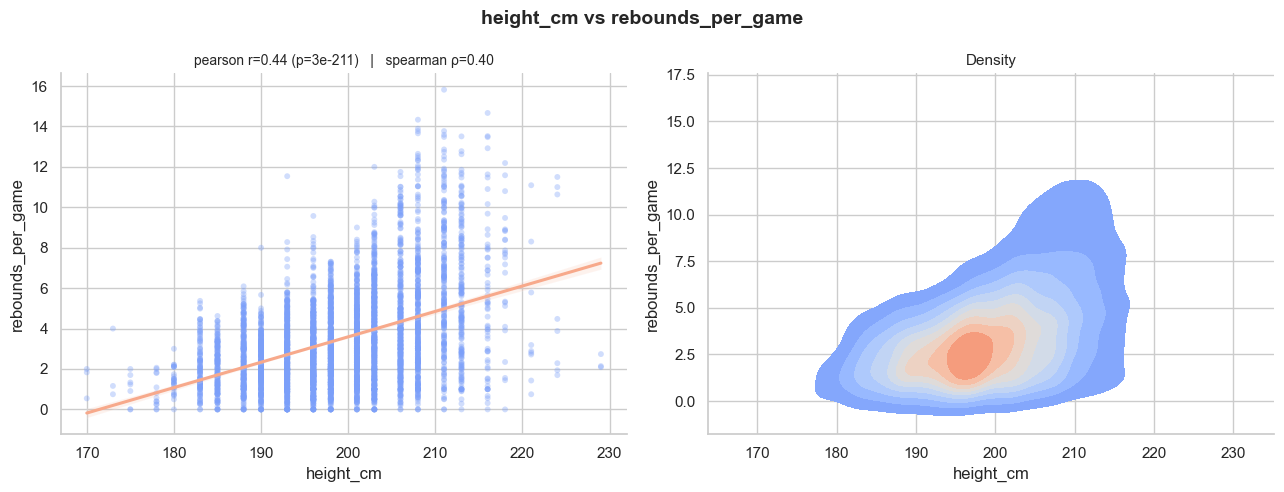

In [92]:
numeric_vs_numeric_plot(data, "height_cm", "rebounds_per_game")

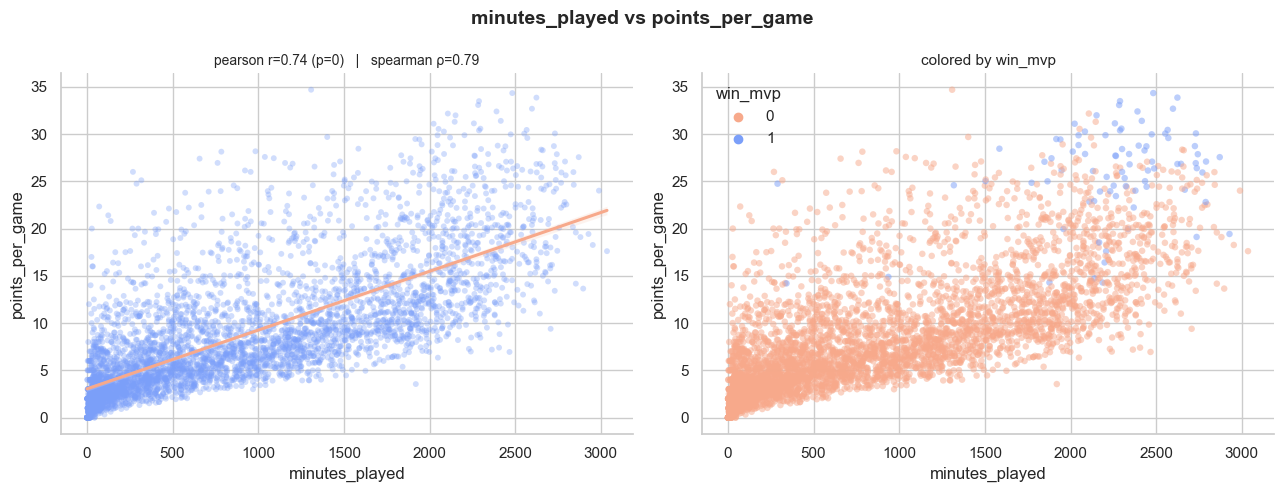

In [93]:
numeric_vs_numeric_plot(data, "minutes_played", "points_per_game", hue="win_mvp")

### Season Trend Plot

In [100]:
def plot_season_trend(df, col, season_col="season", season_order_col="season_year", hue=None):
    fig, ax = plt.subplots(figsize=(7, 4))

    order = (
        df[[season_col, season_order_col]]
        .drop_duplicates()
        .sort_values(season_order_col)[season_col]
    )

    if hue is not None:
        hue_values = sorted(df[hue].dropna().unique())
        if set(hue_values).issubset(TARGET_PALETTE.keys()):
            palette = TARGET_PALETTE
        else:
            palette = dict(zip(hue_values, FALLBACK_PALETTE[:len(hue_values)]))

        summary = df.groupby([season_col, hue])[col].mean().reset_index()
        for val in hue_values:
            sub = summary[summary[hue] == val].set_index(season_col).reindex(order)
            ax.plot(order, sub[col], marker="o", linewidth=2.2, label=str(val), color=palette[val])
        ax.legend(title=hue, frameon=False)
    else:
        summary = df.groupby(season_col)[col].agg(["mean", "std", "count"]).reindex(order)
        se = summary["std"] / np.sqrt(summary["count"])
        ax.plot(order, summary["mean"], marker="o", linewidth=2.2, color=Blue)
        ax.fill_between(
            range(len(order)), summary["mean"] - se, summary["mean"] + se,
            color=Blue, alpha=0.15, label="± SE"
        )
        ax.legend(frameon=False)

    ax.set_title(f"{col} by season", fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.show()

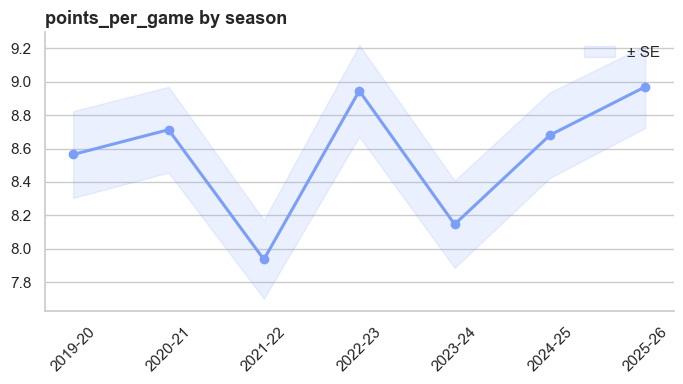

In [101]:
plot_season_trend(data, "points_per_game")

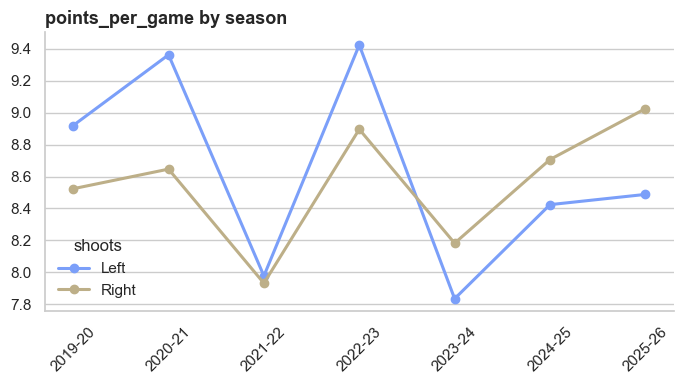

In [104]:
plot_season_trend(data, "points_per_game", hue="shoots")

In [105]:
def anova_boxplot(df, group_col, value_col, palette=None):
    order = df.groupby(group_col)[value_col].median().sort_values(ascending=False).index
    colors = palette or [FALLBACK_PALETTE[i % len(FALLBACK_PALETTE)] for i in range(df[group_col].nunique())]

    plt.figure(figsize=(8, 4.5))
    sns.boxplot(data=df, x=group_col, y=value_col, order=order, palette=colors)
    sns.stripplot(data=df, x=group_col, y=value_col, order=order, color="black", alpha=0.15, size=2)
    plt.title(f"{value_col} by {group_col}", fontsize=12, fontweight="bold", loc="left")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

In [147]:
def plot_features_vs_wins(
    data,
    feature_cols,
    target_col="wins",
    ncols=3
):

    nrows = math.ceil(len(feature_cols) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 5 * nrows)
    )

    axes = np.atleast_1d(axes).flatten()

    for i, feature in enumerate(feature_cols):

        plot_data = data[
            [feature, target_col]
        ].dropna()

        axes[i].scatter(
            plot_data[feature],
            plot_data[target_col],
            alpha=0.6
        )

        axes[i].set_title(
            f"{feature} vs {target_col}"
        )

        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target_col)
        axes[i].grid(alpha=0.3)

    
    plt.tight_layout()
    plt.show()

# Exploratory Data Analysis (EDA)

### Confidence Interval Analysis

- Confidence intervals estimate the likely range for the true population mean of a numeric
  variable, based on the sample we have.
- Applied here to `points_per_game`, `minutes_played`, and `true_shooting_pct` — instead of
  reporting only the sample mean, we report a 95% confidence interval so the result also
  communicates uncertainty.

In [106]:
def mean_ci(data, column, confidence=0.95):

    x = data[column].replace([np.inf, -np.inf], np.nan).dropna()
    n = len(x)
    mean = x.mean()
    std = x.std(ddof=1)
    se = std / np.sqrt(n)

    alpha = 1 - confidence
    t_critical = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin_error = t_critical * se

    result = pd.DataFrame({
        "Variable": [column],
        "Type": "Mean CI",
        "N": n,
        "Sample Mean": round(mean, 3),
        "Sample Std": round(std, 3),
        "Confidence Level": confidence,
        "CI Lower": round(mean - margin_error, 3),
        "CI Upper": round(mean + margin_error, 3),
    })

    return result

### ANOVA: numeric outcome across a multi-category variable

In [124]:
def anova_test_pro(df, group_col, target_col, equal_var=True):
    temp = df[[group_col, target_col]].dropna()

    if temp[group_col].nunique() < 2:
        print("Insufficient Groups")
        return None, None, "Insufficient Groups"

    if equal_var:
        groups = [g[target_col].values for _, g in temp.groupby(group_col)]
        f_stat, p = f_oneway(*groups)
        test_name = "Classic ANOVA"
    else:
        res = anova_oneway(
            data=temp[target_col],
            groups=temp[group_col],
            use_var="unequal"
        )
        f_stat = res.statistic
        p = res.pvalue
        test_name = "Welch ANOVA"

    result = "Significant" if p < 0.05 else "Not Significant"

    print(f"Test used: {test_name}")
    print(f"F-stat = {f_stat:.4f}")
    print(f"p-value = {p:.4g}")
    print(f"Result: {result}")

    return f_stat, p, result

In [108]:
def get_residuals(df, value_col, group_col):
    return df[value_col] - df.groupby(group_col)[value_col].transform('mean')

In [109]:
def levene_test(df, group_col, value_col, center='median'):
    groups = []

    for group in df[group_col].dropna().unique():
        sample = df.loc[df[group_col] == group, value_col].dropna()
        if len(sample) > 0:
            groups.append(sample)

    if len(groups) < 2:
        raise ValueError("Need at least 2 groups with data for Levene test.")

    stat, p = levene(*groups, center=center)
    print(f"P-value is: {p}")

### Chi-square test of independence between two categorical variables

- **Null Hypothesis (H0):** the two categorical variables are independent.
- **Alternative Hypothesis (H1):** the two categorical variables are associated.
- If p-value < 0.05, reject H0.

In [110]:
def compare_two_categorical(df, col_1, col_2, alpha=0.05):

    two_categorical_plot(df, col_1, col_2)

    contingency_table = pd.crosstab(df[col_1], df[col_2])
    chi2_stat, p_value, dof, expected_table = chi2_contingency(contingency_table)

    print(f"chi2_stat: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4g}")

    if p_value < alpha:
        print("Reject the Null Hypothesis")
        print(f"There IS a significant association between '{col_1}' and '{col_2}'.")
    else:
        print("Fail to Reject the Null Hypothesis")
        print(f"There is NO significant association between '{col_1}' and '{col_2}'.")

### Numeric vs categorical (binary target)

To compare a continuous feature against a binary target, first check normality per group
(Shapiro-Wilk). If both groups are normal, use an independent-samples t-test. If not, attempt
a Box-Cox transform and re-test; if it still isn't normal, fall back to the non-parametric
Mann-Whitney U test.

In [111]:
def numeric_vs_categorical(data, col_1, col_2, alpha=0.05):

    numeric_vs_categorical_plot(data, col_1, col_2)

    categories = data[col_2].dropna().unique()
    X1 = data.loc[data[col_2] == categories[0], col_1].replace([np.inf, -np.inf], np.nan).dropna()
    X2 = data.loc[data[col_2] == categories[1], col_1].replace([np.inf, -np.inf], np.nan).dropna()

    shapiro_p0 = stats.shapiro(X1.sample(min(len(X1), 5000), random_state=42)).pvalue
    shapiro_p1 = stats.shapiro(X2.sample(min(len(X2), 5000), random_state=42)).pvalue
    print(f"Shapiro group '{categories[0]}': p = {shapiro_p0:.4g}")
    print(f"Shapiro group '{categories[1]}': p = {shapiro_p1:.4g}")

    if shapiro_p0 > alpha and shapiro_p1 > alpha:
        t, p = stats.ttest_ind(X1, X2)
        print("Normal distribution -> t-test")
        print(f"t = {t:.4f}, p = {p:.4g}")
    else:
        try:
            X1_bc, _ = stats.boxcox(X1 - X1.min() + 1)
            X2_bc, _ = stats.boxcox(X2 - X2.min() + 1)
            shapiro_p0_bc = stats.shapiro(X1_bc.sample(min(len(X1_bc), 5000)) if hasattr(X1_bc, "sample") else X1_bc[:5000]).pvalue
            shapiro_p1_bc = stats.shapiro(X2_bc[:5000]).pvalue

            if shapiro_p0_bc > alpha and shapiro_p1_bc > alpha:
                t, p = stats.ttest_ind(X1_bc, X2_bc)
                print("Normal after Box-Cox -> t-test")
                print(f"t = {t:.4f}, p = {p:.4g}")
            else:
                u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
                print("Not normal after Box-Cox -> Mann-Whitney U")
                print(f"U = {u:.1f}, p = {p:.4g}")
        except Exception:
            u, p = stats.mannwhitneyu(X1, X2, alternative="two-sided")
            print("Box-Cox not applicable -> Mann-Whitney U")
            print(f"U = {u:.1f}, p = {p:.4g}")

    result = "Significant" if p < alpha else "Not Significant"
    print("Result:", result)
    return p

### numeric-vs-numeric

In [112]:
def numeric_vs_numeric_test(df, x, y, alpha=0.05):
    numeric_vs_numeric_plot(df, x, y)
    clean = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    rho, p = spearmanr(clean[x], clean[y])
    result = "Significant" if p < alpha else "Not Significant"
    print(f"Spearman rho = {rho:.4f}, p = {p:.4g}")
    print("Result:", result)
    return rho, p

In [113]:
mean_ci(data, "points_per_game")

,Variable,Type,N,Sample Mean,Sample Std,Confidence Level,CI Lower,CI Upper
0,points_per_game,Mean CI,4513,8.552,6.479,0.95,8.363,8.741


In [114]:
mean_ci(data, "minutes_played")

,Variable,Type,N,Sample Mean,Sample Std,Confidence Level,CI Lower,CI Upper
0,minutes_played,Mean CI,4513,886.994,771.588,0.95,864.476,909.511


### Q1: Do positions differ in scoring?

- **Variables:** `position_main`, `points_per_game`
- **Test:** Welch's one-way ANOVA (unequal variances)
- **H0:** the mean `points_per_game` is the same across all positions.
- **H1:** at least one position has a different mean.

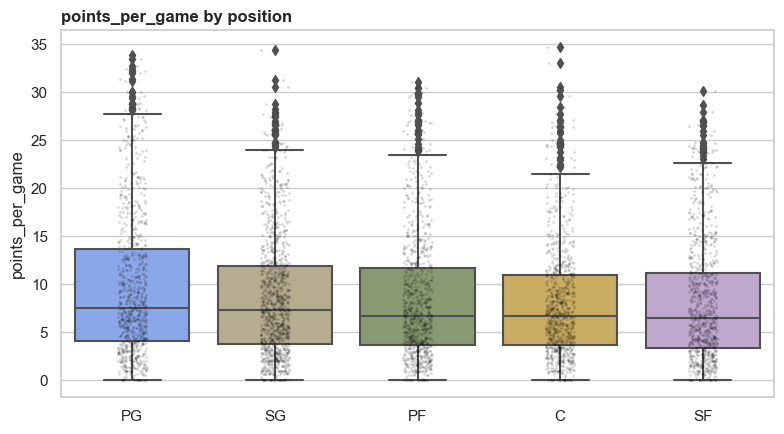

Test used: Welch ANOVA
F-stat = 8.5399
p-value = 7.764e-07
Result: Significant


(8.539881332740796, 7.764465044041174e-07, 'Significant')

In [127]:
anova_boxplot(data, "position", "points_per_game")
anova_test_pro(data, "position", "points_per_game", equal_var=False)

**Conclusion:**
There is a statistically significant difference in average scoring performance between the positions.
The boxplot indicates that the Point Guard (PG) position has a higher distribution of scoring compared to other positions.

### Q2: Do positions differ in blocking, passing, or rebounding?

- **Variables:** `position_main`, `blocks`, `assists`, `offensive_rebounds`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean stat is the same across all positions.
- **H1:** at least one position has a different mean.

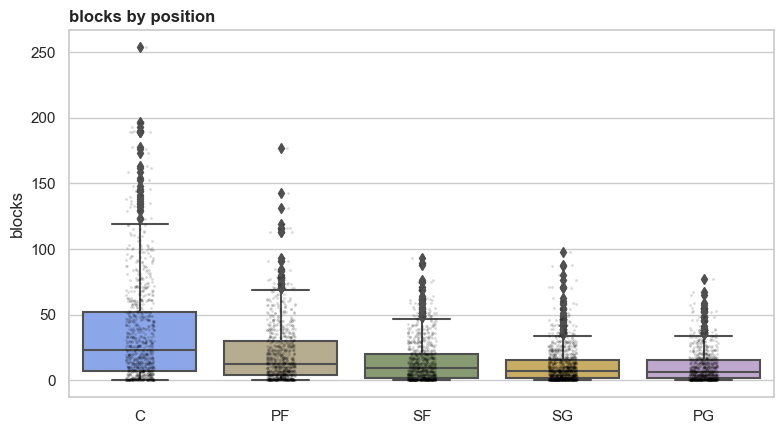

Test used: Welch ANOVA
F-stat = 120.2110
p-value = 1.293e-92
Result: Significant


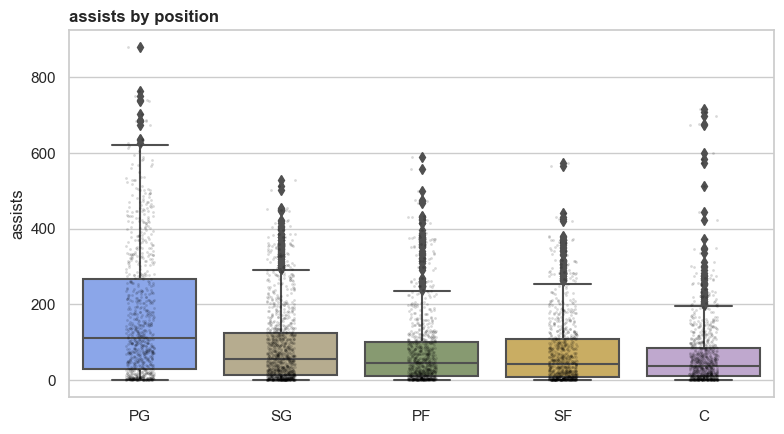

Test used: Welch ANOVA
F-stat = 66.5345
p-value = 3.425e-53
Result: Significant


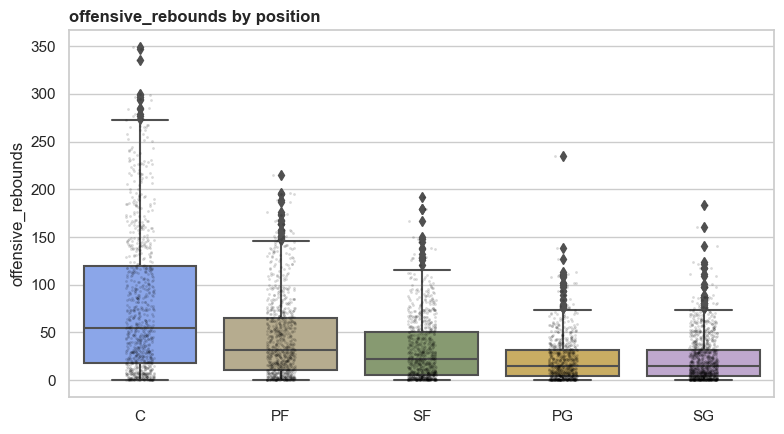

Test used: Welch ANOVA
F-stat = 169.8757
p-value = 2.363e-126
Result: Significant


In [128]:
for stat in ["blocks", "assists", "offensive_rebounds"]:
    anova_boxplot(data, "position", stat)
    anova_test_pro(data, "position", stat, equal_var=False)

**Conclusion:**

In all three categories, the p-value is extremely close to zero (𝑝 < 0.05), meaning we reject the null hypothesis for every metric. Player positions differ significantly in their blocking, passing, and rebounding contributions.

> The data clearly confirms traditional role specializations: Centers (C) lead significantly in blocks and offensive rebounds, while Point Guards (PG) dominate in assists.

> The very high F-statistics (especially for offensive rebounds and blocks) indicate that the “Position” variable is a very strong predictor of these specific physical and technical stats.

### Q3: Do experience groups differ in production?

- **Variables:** `experience_years_bin`, `points`, `assists`, `effective_field_goal_percentage`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean stat is equal across experience groups.
- **H1:** at least one experience group has a different mean.

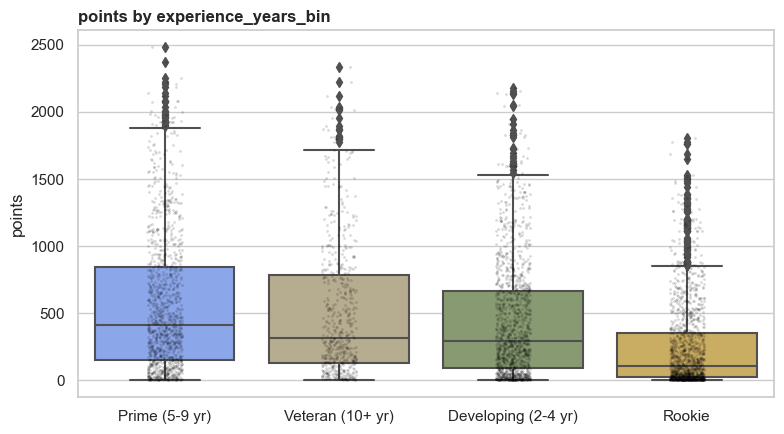

Test used: Welch ANOVA
F-stat = 158.4536
p-value = 1.44e-91
Result: Significant


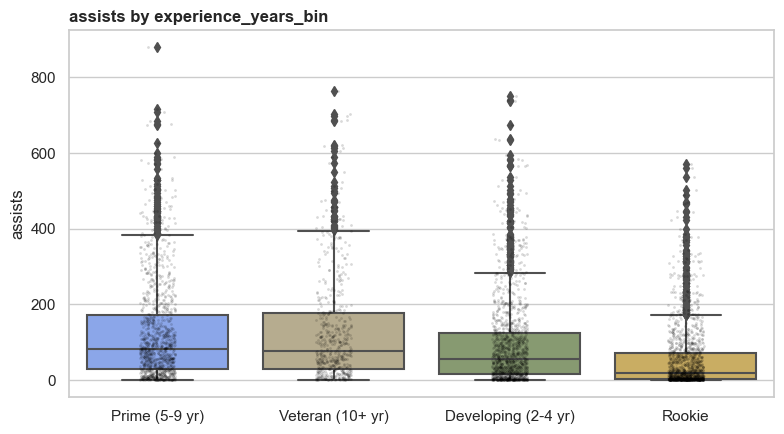

Test used: Welch ANOVA
F-stat = 122.5757
p-value = 1.869e-72
Result: Significant


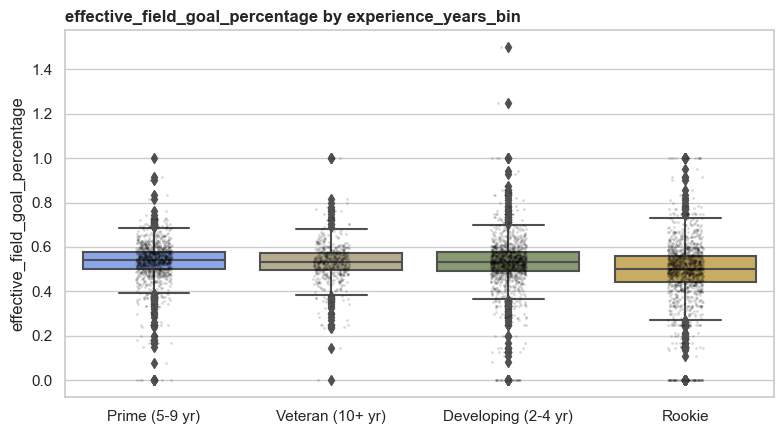

Test used: Welch ANOVA
F-stat = 34.5203
p-value = 8.755e-22
Result: Significant


In [129]:
for stat in ["points", "assists", "effective_field_goal_percentage"]:
    anova_boxplot(data, "experience_years_bin", stat)
    anova_test_pro(data, "experience_years_bin", stat, equal_var=False)

**Conclusion:**

Since p<0.05 for all variables, we reject the null hypothesis. Experience level has a statistically significant impact on a player’s scoring, playmaking, and shooting efficiency.


> Players in the Prime (5-9 years) group show the highest median points and strong efficiency, representing the peak of NBA production.

> There is a clear upward trend from Rookies (lowest in all categories) to the Developing and Prime stages.

> While total points dip slightly for Veterans (10+ years) compared to Prime players, their assist numbers remain high, suggesting a shift in role toward playmaking as they age.

### Q4: Do starters outperform non-starters?

- **Variables:** `is_starter`, `points_per_game`, `effective_field_goal_percentage`, `minutes_played`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of the stat is the same for starters and non-starters.
- **H1:** the distribution of the stat differs between starters and non-starters.

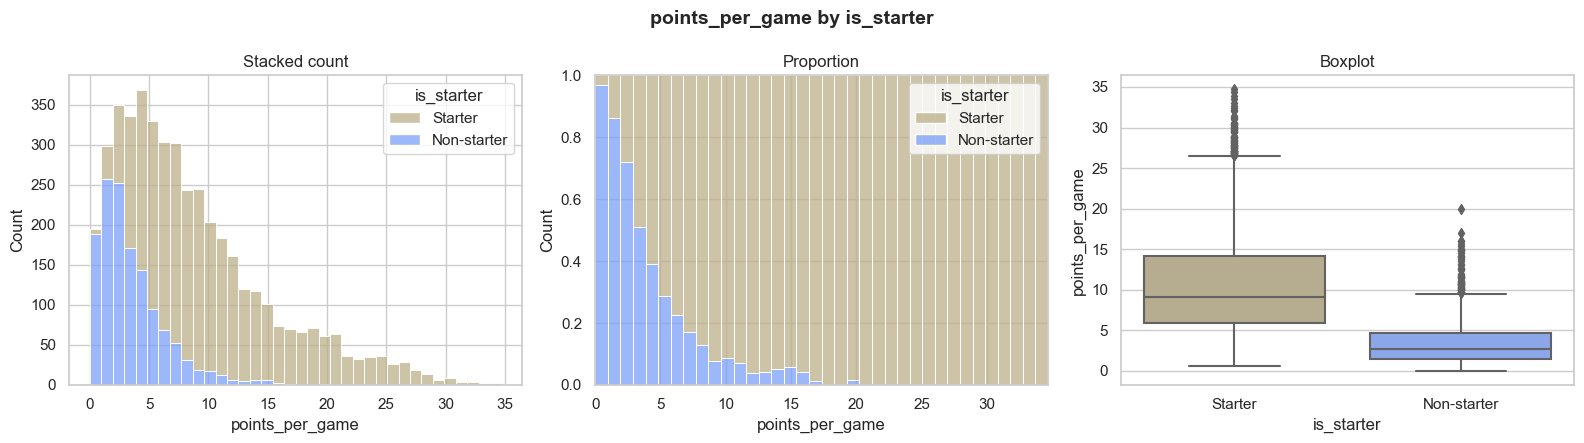

Shapiro group 'Starter': p = 4.392e-37
Shapiro group 'Non-starter': p = 3.02e-31
Not normal after Box-Cox -> Mann-Whitney U
U = 3750287.0, p = 0
Result: Significant


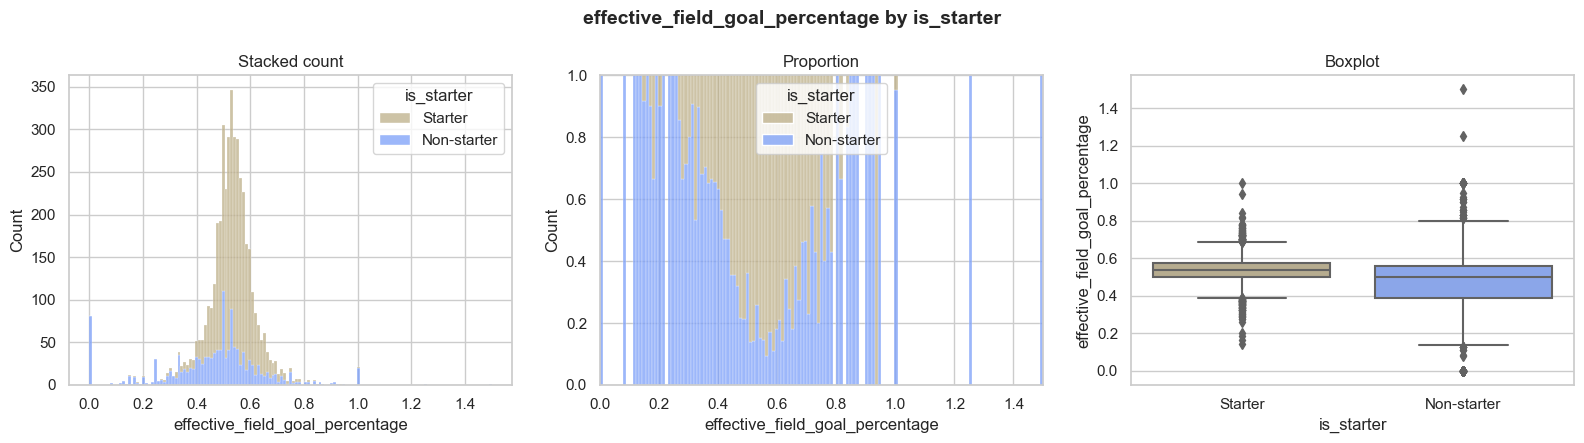

Shapiro group 'Starter': p = 7.462e-26
Shapiro group 'Non-starter': p = 1.272e-23
Not normal after Box-Cox -> Mann-Whitney U
U = 2758992.5, p = 5.43e-57
Result: Significant


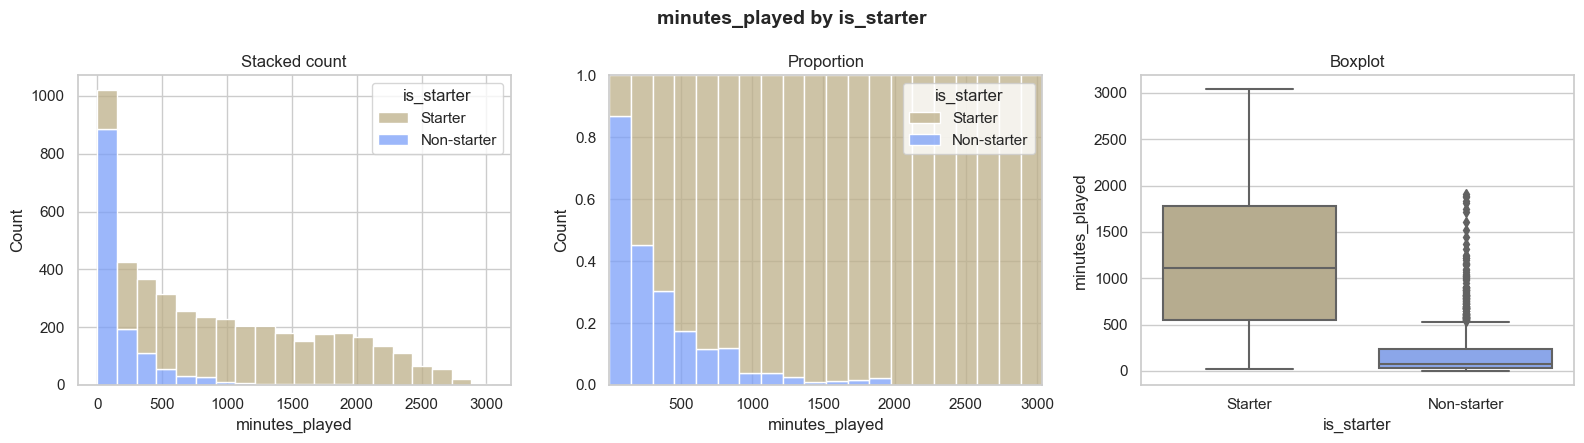

Shapiro group 'Starter': p = 5.87e-29
Shapiro group 'Non-starter': p = 2.757e-45
Not normal after Box-Cox -> Mann-Whitney U
U = 3956725.5, p = 0
Result: Significant


In [130]:
data["is_starter"] = np.where(data["games_started"] == 0, "Non-starter", "Starter")
for stat in ["points_per_game", "effective_field_goal_percentage", "minutes_played"]:
    numeric_vs_categorical(data, stat, "is_starter")

**Conclusion:**  
We reject $H_0$ for all three metrics. Starters and non-starters differ significantly in scoring, efficiency, and playing time. In general, **starters outperform non-starters**, with higher `points_per_game`, higher `effective_field_goal_percentage`, and much more `minutes_played`.


### Q5: Do right-handed players score differently than left-handed players?

- **Variables:** `shoots`, `points_per_game`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of points is the same for right- and left-handed players.
- **H1:** the distribution of points differs between right- and left-handed players.

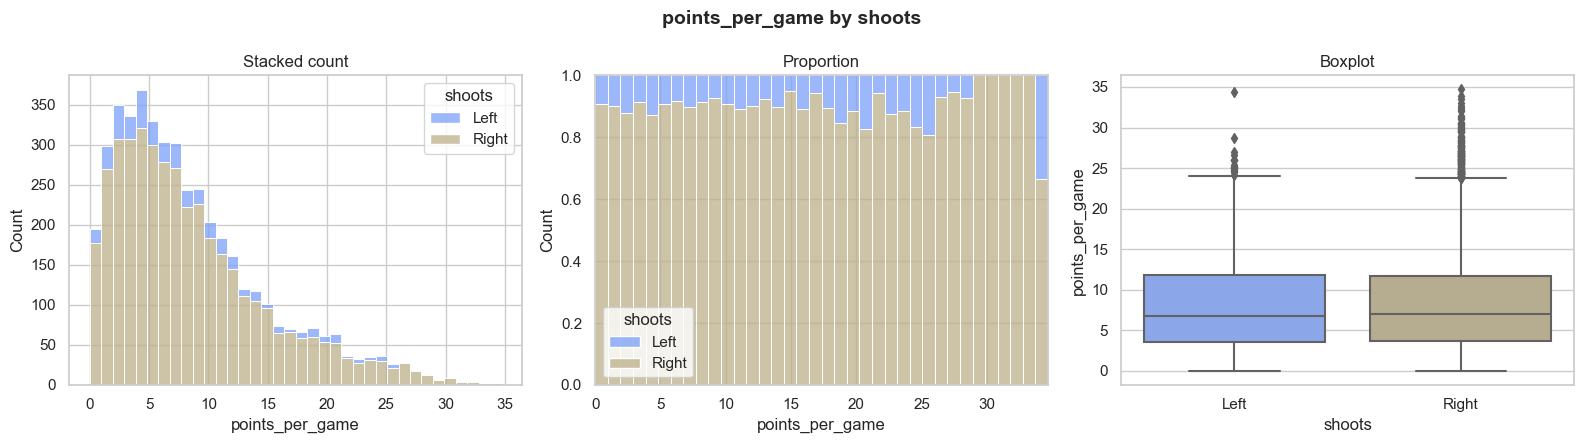

Shapiro group 'Left': p = 1.364e-16
Shapiro group 'Right': p = 5.967e-44
Not normal after Box-Cox -> Mann-Whitney U
U = 898492.5, p = 0.7464
Result: Not Significant


0.7463794809017086

In [94]:
numeric_vs_categorical(data, "points_per_game", "shoots")

**Conclusion:**  
We **fail to reject the null hypothesis ($H_0$)**. There is no statistically significant difference in scoring (`points_per_game`) between left-handed and right-handed players. 

> **Observation:** The boxplots and density proportions are nearly identical, confirming that shooting hand dominance has no apparent effect on a player's average scoring production.


### Q6: Are these player attributes associated with winning MVP?

- **Test:** Chi-square test of independence
- **H0:** the categorical variable and `win_mvp` are independent.
- **H1:** the categorical variable and `win_mvp` are associated.

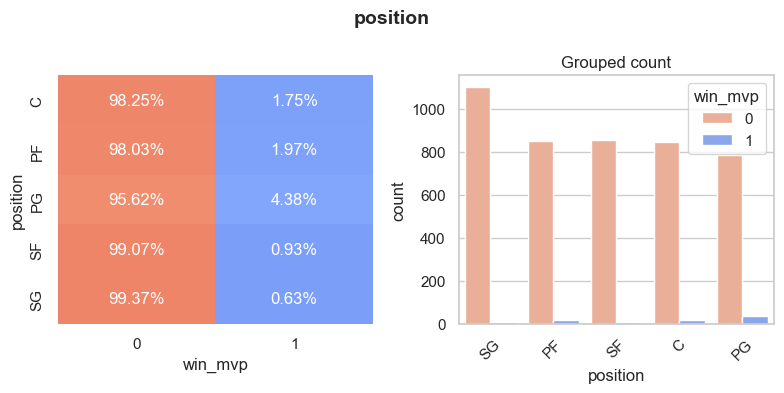

chi2_stat: 42.4797
p-value: 1.327e-08
Reject the Null Hypothesis
There IS a significant association between 'position' and 'win_mvp'.


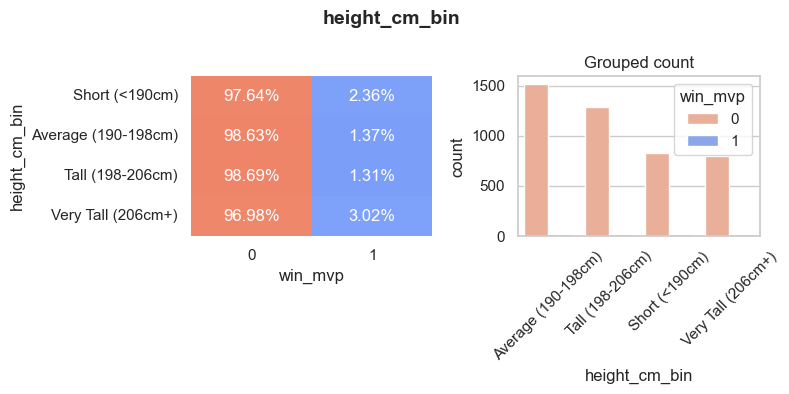

chi2_stat: 11.5721
p-value: 0.009003
Reject the Null Hypothesis
There IS a significant association between 'height_cm_bin' and 'win_mvp'.


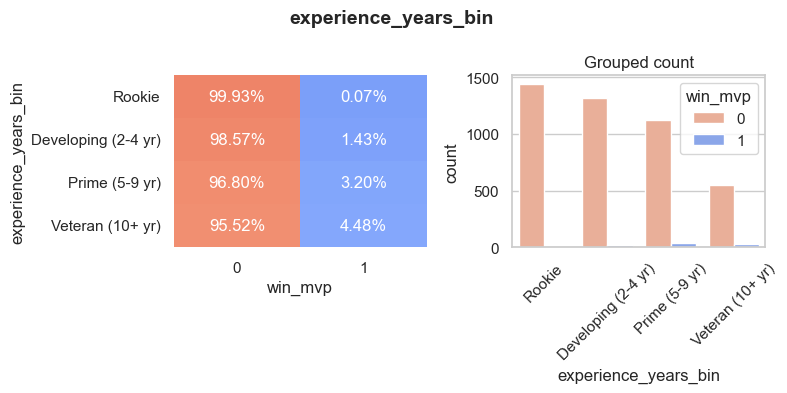

chi2_stat: 60.6437
p-value: 4.283e-13
Reject the Null Hypothesis
There IS a significant association between 'experience_years_bin' and 'win_mvp'.


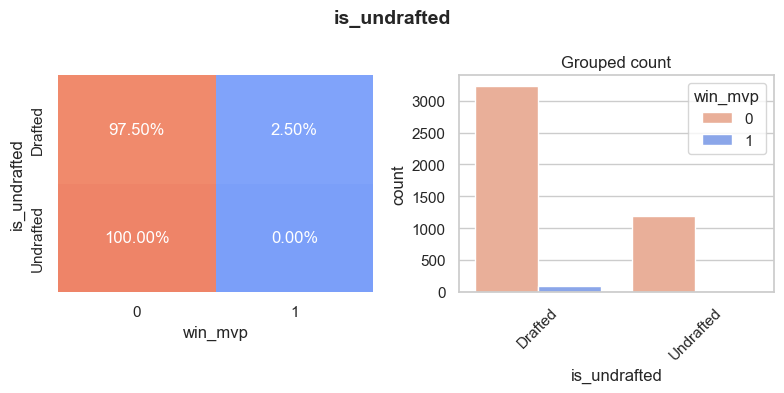

chi2_stat: 28.9806
p-value: 7.311e-08
Reject the Null Hypothesis
There IS a significant association between 'is_undrafted' and 'win_mvp'.


In [131]:
for col in ["position", "height_cm_bin", "experience_years_bin", "is_undrafted"]:
    compare_two_categorical(data, col, target)

**Conclusion:**  
We **reject the null hypothesis** for every attribute tested. There is a statistically significant association between all these factors and winning an MVP award.

*   Experience Matters: The likelihood of winning MVP increases with experience, peaking in the **Veteran (10+ yr)** and **Prime (5-9 yr)** groups. Rookies have a near-zero (0.07%) probability.
*   Position Bias: **Point Guards (PG)** and **Power Forwards (PF)** show higher percentages of MVP winners compared to Shooting Guards (SG).
*   The Undrafted Gap: There is a stark difference in draft status; in this dataset, **0% of undrafted players** have won MVP, whereas drafted players have a 2.5% win rate.
*   Physical Profile: **Very Tall (206cm+)** and **Short (<190cm)** players (likely elite PGs) have higher MVP proportions than "Average" height players.



### Q7: Is scoring or playing time different for MVP seasons?

- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of the stat is the same for MVP and non-MVP seasons.
- **H1:** MVP seasons have a different (higher) distribution.

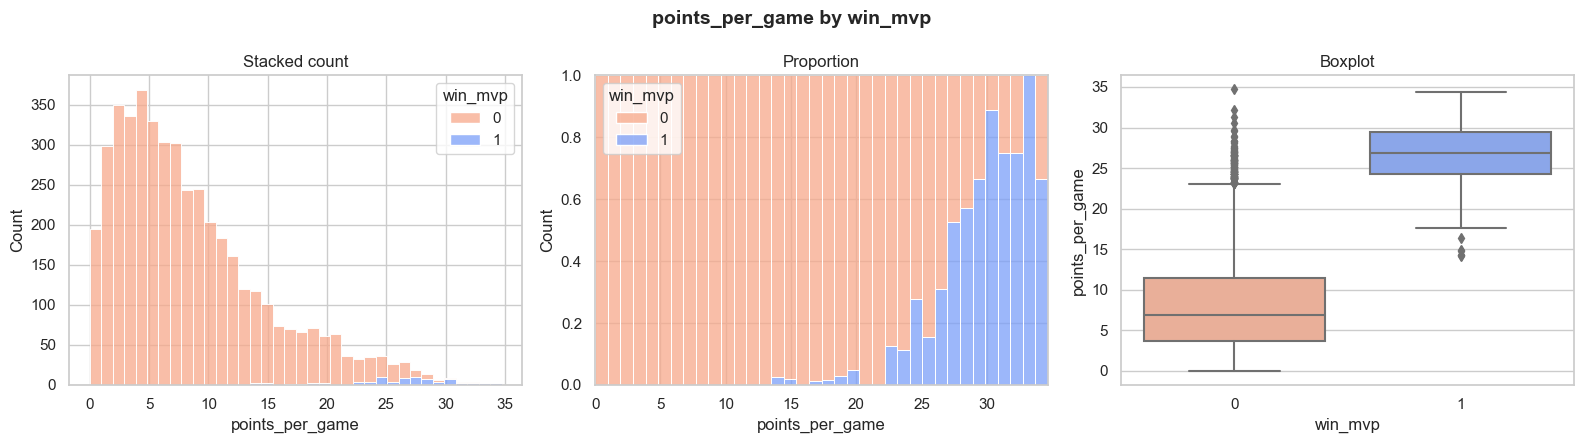

Shapiro group '1': p = 0.00035
Shapiro group '0': p = 2.277e-43
Not normal after Box-Cox -> Mann-Whitney U
U = 359442.5, p = 2.071e-50
Result: Significant


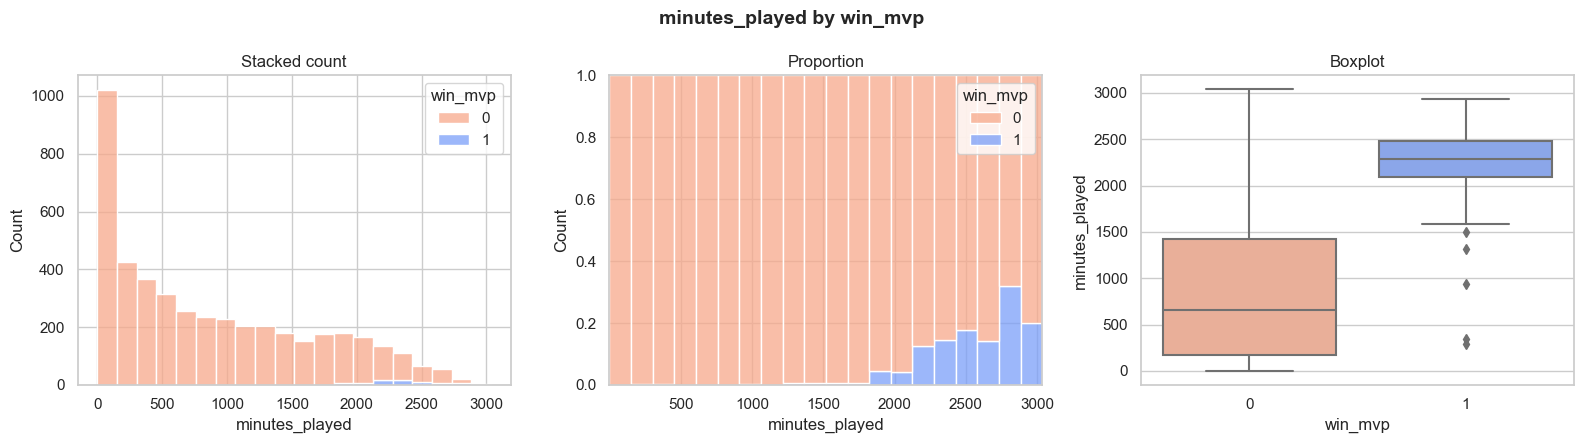

Shapiro group '1': p = 2.172e-08
Shapiro group '0': p = 3.717e-46
Not normal after Box-Cox -> Mann-Whitney U
U = 339593.5, p = 4.942e-40
Result: Significant


In [133]:
for stat in ["points_per_game", "minutes_played"]:
    numeric_vs_categorical(data, stat, target)

**Conclusion:**  
We **reject the null hypothesis ($H_0$)** for all three metrics. Statistical evidence confirms that MVP seasons are characterized by significantly higher scoring production, better shooting efficiency, and increased playing time.
*   The Point Threshold: The proportion chart for `points_per_game` shows that once a player crosses ~25 PPG, the likelihood of an MVP win increases dramatically.
*   Durability: MVP winners consistently rank in the top tier of `minutes_played`, usually exceeding 2000 minutes for the season.


### Q8: Do undrafted players who make an NBA roster get less playing time than drafted players?

- **Variables:** `is_undrafted`, `minutes_played`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of minutes played is the same regardless of draft status.
- **H1:** minutes played differs by draft status.

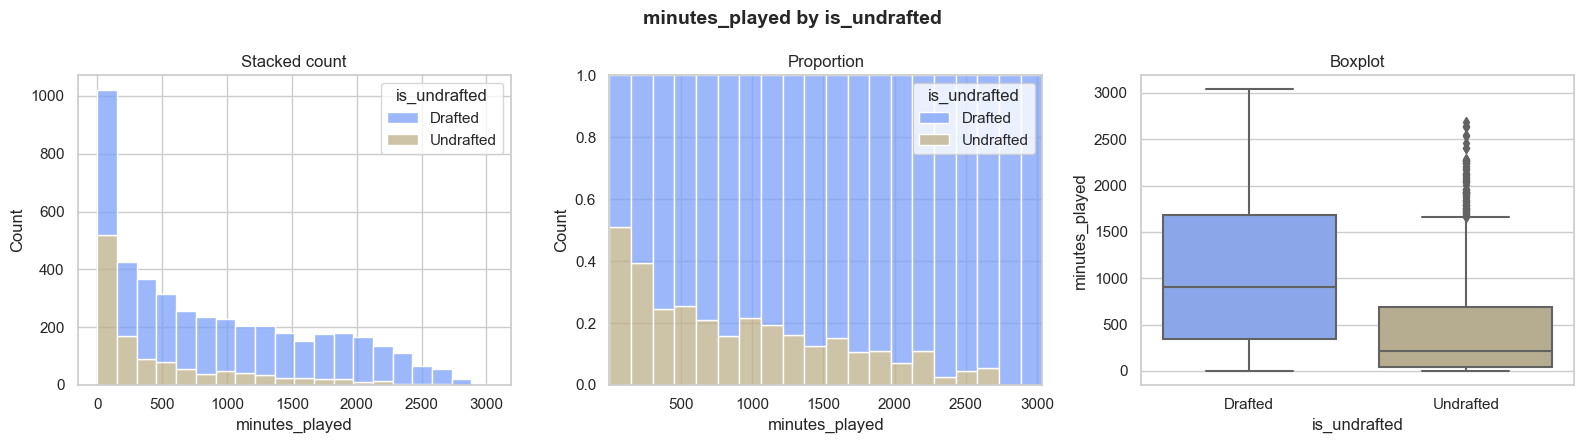

Shapiro group 'Drafted': p = 1.214e-35
Shapiro group 'Undrafted': p = 5.434e-37
Not normal after Box-Cox -> Mann-Whitney U
U = 2894511.0, p = 2.435e-124
Result: Significant


2.4354215117295756e-124

In [134]:
numeric_vs_categorical(data, "minutes_played", "is_undrafted")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is overwhelming statistical evidence ($p < 0.05$) that undrafted players who make an NBA roster receive significantly less playing time than their drafted counterparts.

*   The boxplot reveals a stark difference in median minutes. Drafted players have a median well above 500 minutes, while the median for undrafted players is significantly lower, often relegated to "garbage time" or deep bench roles.
*   The "Stacked count" histogram shows a massive concentration of undrafted players in the 0–250 minute range. Very few undrafted players cross the 2000-minute threshold.
*   The "Proportion" chart highlights that as minutes played increase, the percentage of the player pool that is undrafted shrinks. Drafted players dominate almost 100% of the high-minute (2500+) buckets.


### Q9: Does a heavier build predict better rebounding?

- **Variables:** `weight_kg`, `offensive_rebounds`
- **Test:** Spearman correlation significance test
- **H0:** rho = 0 (no monotonic relationship between weight and offensive rebounds).
- **H1:** rho ≠ 0.

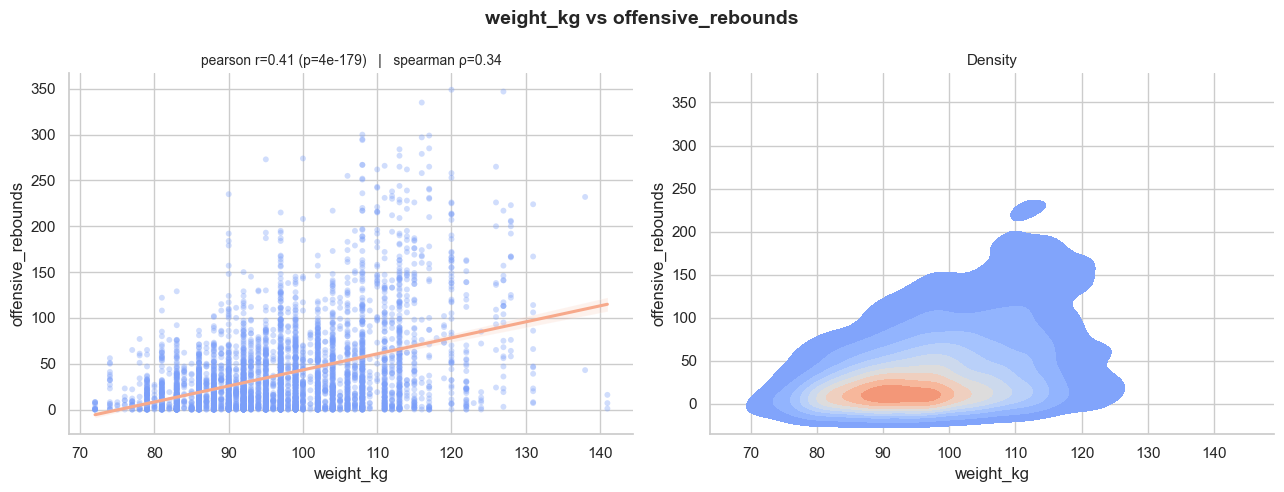

Spearman rho = 0.3353, p = 5.465e-119
Result: Significant


(0.33528157716254336, 5.464619175460971e-119)

In [135]:
numeric_vs_numeric_test(data, "weight_kg", "offensive_rebounds")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant positive relationship between player weight and offensive rebounds. Heavier players tend to grab more offensive boards.

*   The relationship is **positive but moderate**, so weight appears to help rebounding, but it is not the only factor involved.
*   The scatter/density plot shows a clear upward trend: as `weight_kg` increases, `offensive_rebounds` generally increase as well.


### Q10: Does shooting efficiency improve continuously with experience?

- **Variables:** `experience_years`, `true_shooting_pct`
- **Test:** Spearman correlation significance test
- **H0:** rho = 0 (no monotonic relationship between experience and shooting efficiency).
- **H1:** rho ≠ 0.

This is the continuous counterpart to Q3's binned ANOVA -- useful to check whether the
relationship looks smooth/monotonic or whether the binned groups were hiding a plateau.

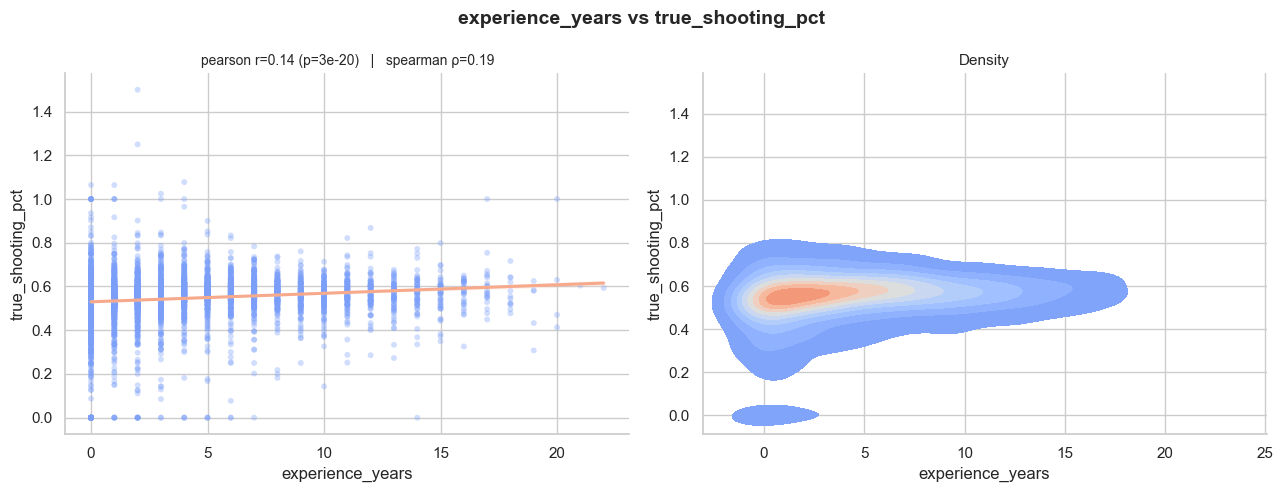

Spearman rho = 0.1934, p = 5.567e-39
Result: Significant


(0.19337502915525637, 5.5666602008946205e-39)

In [143]:
numeric_vs_numeric_test(data, "experience_years", "true_shooting_pct")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant positive monotonic relationship between a player's years of experience and their shooting efficiency (`true_shooting_pct`).

### Q11: Is shooting hand associated with playing position?

- **Variables:** `shoots`, `position_main`
- **Test:** Chi-square test of independence
- **H0:** shooting hand and position are independent.
- **H1:** shooting hand and position are associated.

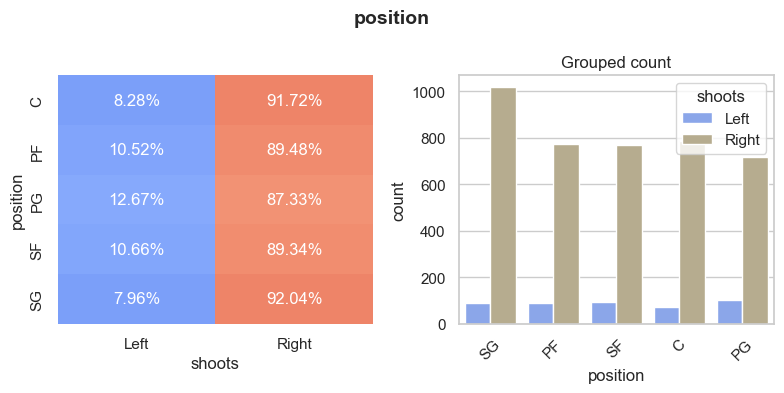

chi2_stat: 15.2271
p-value: 0.004253
Reject the Null Hypothesis
There IS a significant association between 'position' and 'shoots'.


In [144]:
compare_two_categorical(data, "position", "shoots")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant association between shooting hand and playing position.


### Q12: Do veteran players get more minutes than rookies?

- **Variables:** `experience_years_bin`, `minutes_played`
- **Test:** Welch's one-way ANOVA
- **H0:** the mean `minutes_played` is equal across experience groups.
- **H1:** at least one experience group differs.

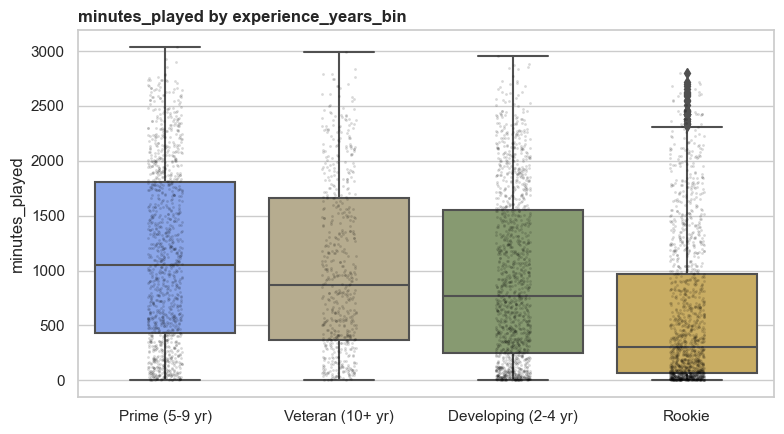

Test used: Welch ANOVA
F-stat = 137.0002
p-value = 1.225e-80
Result: Significant


(137.00015216908102, 1.225285164955166e-80, 'Significant')

In [145]:
anova_boxplot(data, "experience_years_bin", "minutes_played")
anova_test_pro(data, "experience_years_bin", "minutes_played", equal_var=False)

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant difference in minutes played across experience groups. This means that career stage has a strong effect on playing time.

1. **Prime players receive the most minutes**
   - Players in the **Prime (5–9 years)** group have the highest median minutes played.
   - Teams appear to rely most heavily on players who are experienced but not yet in decline.

2. **Rookies play the fewest minutes**
   - **Rookies** have the lowest median playing time by a wide margin.
   - Most rookies are used in limited roles, with only a few exceptions receiving heavy minutes.

3. **Veterans still play more than developing players**
   - **Veterans (10+ years)** generally receive more minutes than **Developing (2–4 years)** players.
   - Even if they are past their peak, experience helps veterans remain valuable in team rotations.

4. **High-minute seasons are concentrated in established players**
   - The distribution shows that very high-minute seasons are much more common among **Prime** and **Veteran** players.
   - This suggests that long, durable, high-usage seasons are mostly reserved for established players.


### Q13: Are undrafted players who make an NBA roster more shooting-efficient than drafted players?

- **Variables:** `is_undrafted`, `true_shooting_pct`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of shooting efficiency is the same regardless of draft status.
- **H1:** shooting efficiency differs by draft status.

Rationale: an undrafted player who sticks in the league may need to be more efficient to
justify a roster spot -- a survivorship-bias-style question, distinct from Q8 (which looks at
playing time rather than efficiency).

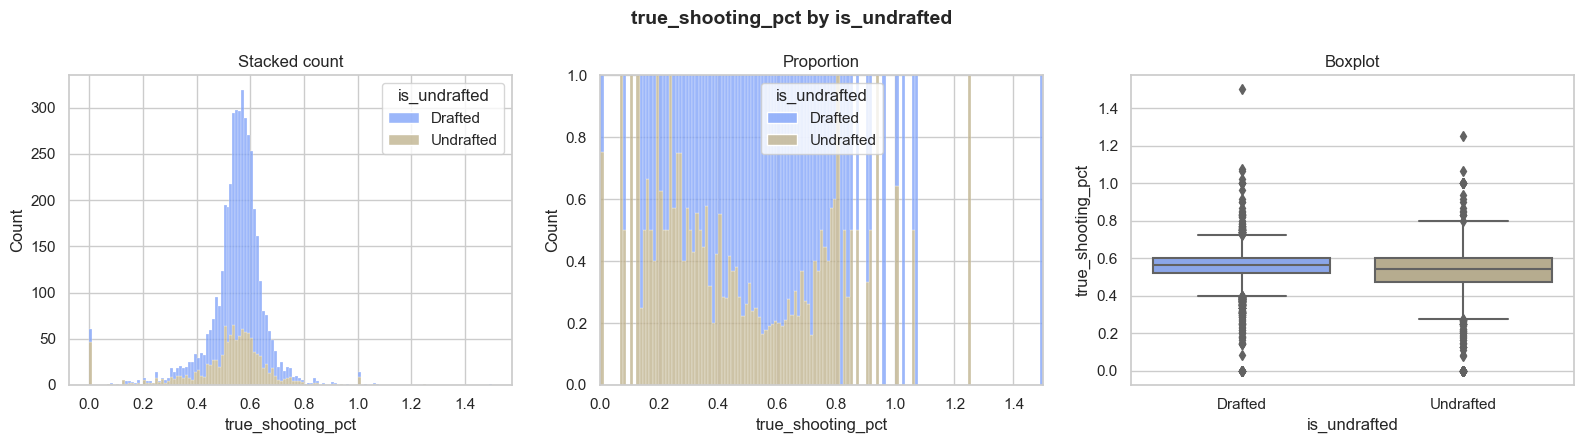

Shapiro group 'Drafted': p = 1.343e-46
Shapiro group 'Undrafted': p = 5.686e-29
Not normal after Box-Cox -> Mann-Whitney U
U = 2202392.0, p = 1.659e-12
Result: Significant


1.6591211521810434e-12

In [146]:
numeric_vs_categorical(data, "true_shooting_pct", "is_undrafted")

**Conclusion:**  
We **reject the null hypothesis ($H_0$)**. There is a statistically significant difference in shooting efficiency based on draft status. However, the data suggests that **drafted players are actually more efficient** than undrafted players.

### Q14: MVP Winners Come from Better Teams

- **Variables:**
  - MVP winner: defined as `rank == 1` in `mvp` (MVP votes table)
  - Team performance: `wins` (from `team_season_stats`)
- **Test:** Independent t-test
- **H0:** Mean team wins are equal for MVP winners and non-winner vote-getters.
- **H1:** Mean team wins differ between MVP winners and non-winner vote-getters.

In [147]:
mvp_wins = mvp.merge(
    team_season_stats[["team_id", "season_id", "wins"]],
    on=["team_id", "season_id"],
    how="left"
)

mvp_wins["mvp_winner"] = np.where(mvp_wins["rank"] == 1, "MVP Winner", "Non-winner Vote-getter")

winner_wins = mvp_wins.loc[mvp_wins["mvp_winner"] == "MVP Winner", "wins"].dropna()
nonwinner_wins = mvp_wins.loc[mvp_wins["mvp_winner"] == "Non-winner Vote-getter", "wins"].dropna()

print(f"Sample sizes — MVP winners: {len(winner_wins)}   Non-winner vote-getters: {len(nonwinner_wins)}")

Sample sizes — MVP winners: 7   Non-winner vote-getters: 72


In [148]:
# normality check (informational — the independent t-test is used regardless, per the test plan above)
shapiro_p_winner = shapiro(winner_wins).pvalue
shapiro_p_nonwinner = shapiro(nonwinner_wins).pvalue
print(f"Shapiro (MVP winners):             p = {shapiro_p_winner:.4g}")
print(f"Shapiro (non-winner vote-getters): p = {shapiro_p_nonwinner:.4g}")

Shapiro (MVP winners):             p = 0.6639
Shapiro (non-winner vote-getters): p = 0.1059


In [149]:
levene(winner_wins ,nonwinner_wins)

LeveneResult(statistic=0.04058725643699572, pvalue=0.8408679864630033)

There is no statistical evidence that the winner and non-winner groups have different variances.

In [150]:
alpha = 0.05

stat, p_value = ttest_ind(winner_wins, nonwinner_wins, equal_var=True)

print(f"Independent t-test: statistic = {stat:.4f},  p = {p_value:.4g}")
print("Result:", "Significant — reject H0" if p_value < alpha else "Not significant — fail to reject H0")

Independent t-test: statistic = 2.3882,  p = 0.01938
Result: Significant — reject H0


**Caution** : Both groups passed the Shapiro–Wilk normality test ($p > 0.05$), so **Student’s $t$-test** was used. However, the result should be interpreted cautiously because the small winner sample limits the reliability of the normality assessment and the statistical power of the comparison.

## Q15: Higher MVP Vote Share Is Associated with Stronger Player Performance

- **Variables:**
  - MVP vote share: `share`
  - Player-performance metrics: `points_per_game`, `assists_per_game`, `rebounds_per_game`, `effective_field_goal_percentage`
- **Test:** Spearman correlation significance test
- **H0:** MVP vote share has no monotonic correlation with each player-performance metric (ρ = 0).
- **H1:** MVP vote share has a significant monotonic correlation with at least one player-performance metric (ρ ≠ 0).

Note: only player-seasons that actually received at least one MVP vote have a defined `share`, so this test is restricted to that subset (an inner join with `mvp`), not the full league.

In [151]:
# restrict to player-seasons that received at least one MVP vote (share is only defined for those)
mvp_share = mvp[["player_id", "season_id", "share"]].merge(
    data[["player_id", "season_id", "points_per_game", "assists_per_game",
          "rebounds_per_game", "effective_field_goal_percentage"]],
    on=["player_id", "season_id"],
    how="inner"
)

print(f"Sample size (MVP vote-getters): {len(mvp_share)}")
mvp_share.describe()

Sample size (MVP vote-getters): 83


,player_id,season_id,share,points_per_game,assists_per_game,rebounds_per_game,effective_field_goal_percentage
count,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,1482.710843,3.698795,0.219422,26.104618,6.569161,7.678288,0.559241
std,304.324583,1.942684,0.309585,4.737116,2.190259,3.027094,0.038993
min,1022.000000,1.000000,0.001000,14.200000,1.253521,1.933333,0.465000
25%,1264.500000,2.000000,0.003000,24.270624,5.012958,5.196135,0.531000
50%,1415.000000,4.000000,0.030000,26.851351,6.285714,7.189655,0.557000
75%,1723.000000,5.000000,0.354000,29.452381,8.144642,9.945621,0.574500
max,2111.000000,7.000000,0.961000,34.338235,11.738462,13.770270,0.675000


In [152]:
metrics = ["points_per_game", "assists_per_game", "rebounds_per_game", "effective_field_goal_percentage"]
alpha = 0.05

results = []
for metric in metrics:
    clean = mvp_share[["share", metric]].dropna()
    rho, p_value = spearmanr(clean["share"], clean[metric])
    results.append({
        "metric": metric,
        "spearman_rho": rho,
        "p_value": p_value,
        "result": "Significant" if p_value < alpha else "Not Significant"
    })

results_df = pd.DataFrame(results)
results_df

,metric,spearman_rho,p_value,result
0,points_per_game,0.482014,0.000004,Significant
1,assists_per_game,0.069965,0.529665,Not Significant
2,rebounds_per_game,0.412060,0.000109,Significant
3,effective_field_goal_percentage,0.262161,0.016656,Significant


In [153]:
significant_metrics = results_df.loc[results_df["result"] == "Significant", "metric"].tolist()

print("Reject H0" if len(significant_metrics) > 0 else "Fail to reject H0")
print(f"Metrics with a significant correlation to MVP vote share: {significant_metrics}")

Reject H0
Metrics with a significant correlation to MVP vote share: ['points_per_game', 'rebounds_per_game', 'effective_field_goal_percentage']


## Q16: First-Place Vote Distribution Depends on Player Position

- **Variables:**
  - Player position: `position_main`
  - First-place vote status: `received_first_place_vote` — "Yes" if `first_place_votes > 0`, else "No"
- **Test:** Chi-square test of independence
- **H0:** Player position and receiving first-place votes are independent.
- **H1:** Player position and receiving first-place votes are associated.

Note: this is restricted to player-seasons that received at least one MVP vote at all (an inner join with `mvp`), since `first_place_votes` is only meaningful for that subset.

In [154]:
mvp_fpv = mvp[["player_id", "season_id", "first_place_votes"]].merge(
    data[["player_id", "season_id", "position"]],
    on=["player_id", "season_id"],
    how="inner"
)

mvp_fpv["received_first_place_vote"] = np.where(mvp_fpv["first_place_votes"] > 0, "Yes", "No")

print(f"Sample size (MVP vote-getters): {len(mvp_fpv)}")
pd.crosstab(mvp_fpv["position"], mvp_fpv["received_first_place_vote"])

Sample size (MVP vote-getters): 83


received_first_place_vote,No,Yes
position,,
C,5,10
PF,12,5
PG,26,10
SF,8,0
SG,7,0


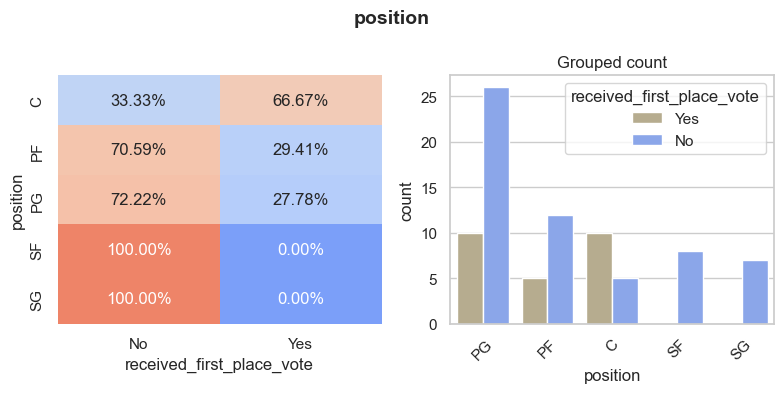

chi2_stat: 16.0818
p-value: 0.002911
Reject the Null Hypothesis
There IS a significant association between 'position' and 'received_first_place_vote'.


In [155]:
compare_two_categorical(mvp_fpv, "position", "received_first_place_vote")

In [156]:
alpha = 0.05

contingency = pd.crosstab(mvp_fpv["position"], mvp_fpv["received_first_place_vote"])
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic = {chi2_stat:.4f},  dof = {dof},  p = {p_value:.4g}")
print("Result:", "Significant — reject H0" if p_value < alpha else "Not significant — fail to reject H0")

Chi-square statistic = 16.0818,  dof = 4,  p = 0.002911
Result: Significant — reject H0


### Q17: Do American and international players differ in scoring?

- **Variables:** `is_american` (derived from `birth_place`), `points_per_game`
- **Test:** auto-selected (t-test if normal, Mann-Whitney U otherwise)
- **H0:** the distribution of `points_per_game` is the same for American and international players.
- **H1:** the distribution of `points_per_game` differs between American and international players.

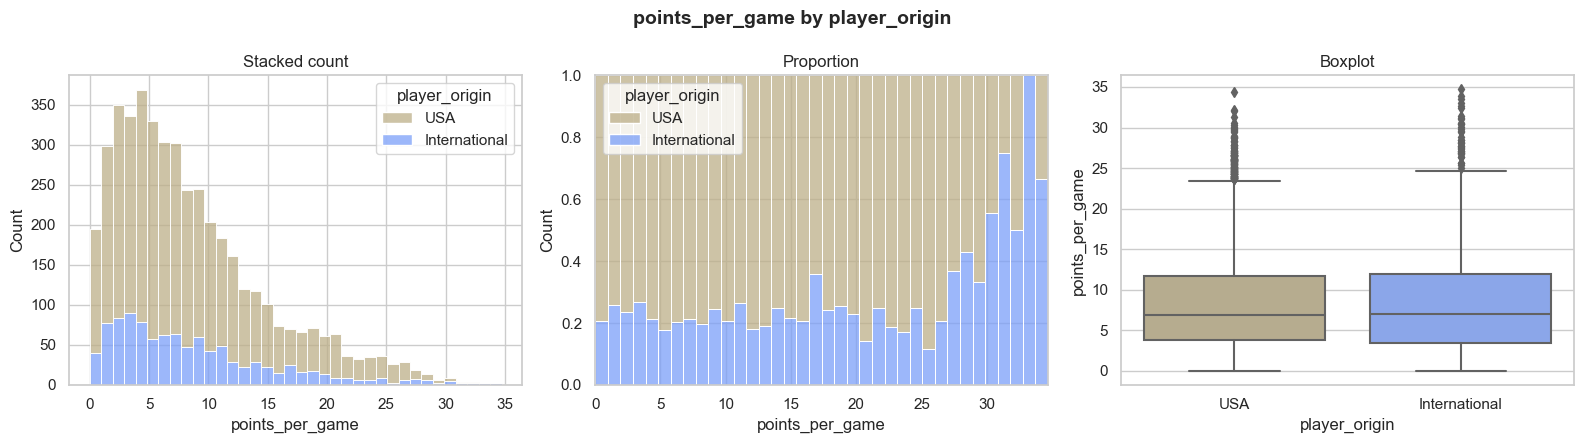

Shapiro group 'USA': p = 7.803e-41
Shapiro group 'International': p = 8.033e-26
Not normal after Box-Cox -> Mann-Whitney U
U = 1775912.0, p = 0.8802
Result: Not Significant


0.8802005683468247

In [157]:
numeric_vs_categorical(data, "points_per_game", "player_origin")

### Q18: Is being American associated with winning MVP?

- **Test:** Chi-square test of independence
- **H0:** `is_american` and `win_mvp` are independent.
- **H1:** `is_american` and `win_mvp` are associated.

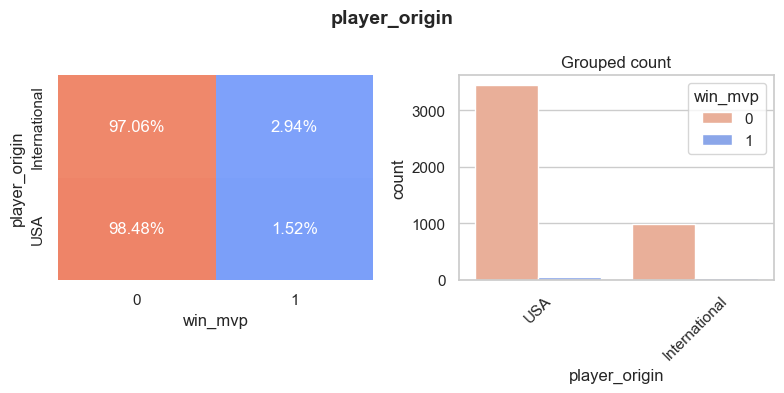

chi2_stat: 8.0946
p-value: 0.00444
Reject the Null Hypothesis
There IS a significant association between 'player_origin' and 'win_mvp'.


In [119]:
compare_two_categorical(data, "player_origin", target)

---
## Has the agility (height-to-weight ratio) of each season's top 20 players increased over time?

- **Agility definition:** agility = height_cm / weight_kg
- **Recent group:** top 20 players (rank ≤ 20) in the 2022-23 and 2023-24 seasons
- **Past group:** top 20 players (rank ≤ 20) in the 2020-21 and 2021-22 seasons
- **H0:** the mean agility of the recent group is **not greater** than the past group (μ_recent ≤ μ_past)
- **H1:** the mean agility of the recent group **is greater** than the past group (μ_recent > μ_past)
- **Test:** one-tailed (`alternative='greater'`) — since the claim is explicitly directional ("has increased")

In [ ]:
# filter to each season's top 20 players and build the agility variable
top20 = data[data['rank'] <= 20].copy()
top20['agility'] = top20['height_cm'] / top20['weight_kg']

# season_id: 2 -> 2020-21 , 3 -> 2021-22 , 4 -> 2022-23 , 5 -> 2023-24
past = top20[top20['season_id'].isin([2, 3])]   # 2020-21 through 2021-22
recent = top20[top20['season_id'].isin([4, 5])]   # 2022-23 through 2023-24

print(f"Sample sizes — past: {len(past)}   recent: {len(recent)}")
past['agility'].describe(), recent['agility'].describe()

In [162]:
# check normality before choosing the test
shapiro_p_past = shapiro(past['agility'].dropna()).pvalue
shapiro_p_recent = shapiro(recent['agility'].dropna()).pvalue
print(f"Shapiro (past):   p = {shapiro_p_past:.4g}")
print(f"Shapiro (recent): p = {shapiro_p_recent:.4g}")

Shapiro (past):   p = 0.5843
Shapiro (recent): p = 0.6211


In [172]:
alpha = 0.05

if shapiro_p_past > alpha and shapiro_p_recent > alpha:
    stat, p_value = ttest_ind(recent['agility'], past['agility'], alternative='greater', equal_var=False)
    test_used = "Welch's t-test (one-sided: recent > past)"
else:
    stat, p_value = mannwhitneyu(recent['agility'], past['agility'], alternative='greater')
    test_used = "Mann-Whitney U (one-sided: recent > past)"

print(f"Test used: {test_used}")
print(f"statistic = {stat:.4f},  p = {p_value:.4g}")
print("Result:", "Significant — reject H0" if p_value < alpha else "Not significant — fail to reject H0")

Test used: Welch's t-test (one-sided: recent > past)
statistic = 0.0072,  p = 0.4971
Result: Not significant — fail to reject H0


**Conclusion:**

There is no significant evidence that the top 20 players' agility (height ÷ weight) has increased in recent seasons compared to a couple of seasons earlier. The two group means are nearly identical (2.028 vs. 2.029), so this isn't a case of a real difference that the test missed — the data itself shows essentially no change.

This is consistent with what we'd expect physically: an adult player's height and weight are largely fixed for the rest of their career, so a ratio built entirely from those two traits has little room to shift from one season to the next, regardless of any real change in playing style or athleticism the league may have undergone.

---
## Has Players' "Innate Ability" Improved?

**Claim:** an expert argues that, thanks to modern progress and better conditions, people's ability to develop and express their innate talent has improved compared to the past. As supporting evidence, the expert claims that the average *innate ability* of the players on the championship-winning team is higher in the **last 2 seasons** than it was **2 seasons before that**. The expert defines *innate ability* as **experience relative to age** (experience ÷ age) — the idea being that someone who has accumulated more career experience per year of life has converted more of their life into skill.

In [210]:
# the champion team for each of the 4 most recent seasons on record
champ_recent = champ.merge(seasons, on="season_id").sort_values("season_id", ascending=False).head(4).sort_values("season_id").reset_index(drop=True)

print("4 most recent seasons with a recorded champion:")
print(champ_recent[["season_id", "season", "team_id"]].to_string(index=False))

# Most recent 2 seasons vs. the 2 seasons before those
last_2_seasons = champ_recent.iloc[2:]
prior_2_seasons = champ_recent.iloc[:2]

4 most recent seasons with a recorded champion:
 season_id  season  team_id
         4 2022-23        8
         5 2023-24       20
         6 2024-25       21
         7 2025-26       20


In [212]:
group_recent = data.merge(last_2_seasons[['season_id', 'team_id']])
group_recent = group_recent.query("games > 0 and age > 0").copy()
group_recent["innate_ability"] = group_recent["experience_years"] / group_recent["age"]

cols = ["player_id", "name", "season", "team_id", "age", "experience_years", "innate_ability"]
group_recent = group_recent[cols]
group_recent

,player_id,name,season,team_id,age,experience_years,innate_ability
0,1367,Shai Gilgeous-Alexander,2024-25,21,26,6,0.230769
1,2130,Jalen Williams,2024-25,21,23,2,0.086957
2,2121,Aaron Wiggins,2024-25,21,26,3,0.115385
3,1522,Isaiah Joe,2024-25,21,25,4,0.160000
4,1273,Luguentz Dort,2024-25,21,25,5,0.200000
5,1429,Isaiah Hartenstein,2024-25,21,26,6,0.230769
6,2086,Cason Wallace,2024-25,21,21,1,0.047619
7,1465,Chet Holmgren,2024-25,21,22,1,0.045455
8,2134,Kenrich Williams,2024-25,21,30,6,0.200000
9,1174,Alex Caruso,2024-25,21,30,7,0.233333


In [213]:
group_prior = data.merge(prior_2_seasons[['season_id', 'team_id']])
group_prior = group_prior.query("games > 0 and age > 0").copy()
group_prior["innate_ability"] = group_prior["experience_years"] / group_prior["age"]

cols = ["player_id", "name", "season", "team_id", "age", "experience_years", "innate_ability"]
group_prior = group_prior[cols]
group_prior

,player_id,name,season,team_id,age,experience_years,innate_ability
0,1539,Nikola JokiA,2022-23,8,27,7,0.259259
1,1752,Jamal Murray,2022-23,8,25,6,0.240000
2,1377,Aaron Gordon,2022-23,8,27,8,0.296296
3,1851,Michael Porter Jr.,2022-23,8,24,3,0.125000
4,1128,Bruce Brown,2022-23,8,26,4,0.153846
5,1157,Kentavious Caldwell-Pope,2022-23,8,29,9,0.310345
6,1507,Reggie Jackson,2022-23,8,32,11,0.343750
7,1487,Bones Hyland,2022-23,8,22,1,0.045455
8,1142,Thomas Bryant,2022-23,8,25,5,0.200000
9,1394,Jeff Green,2022-23,8,36,15,0.416667


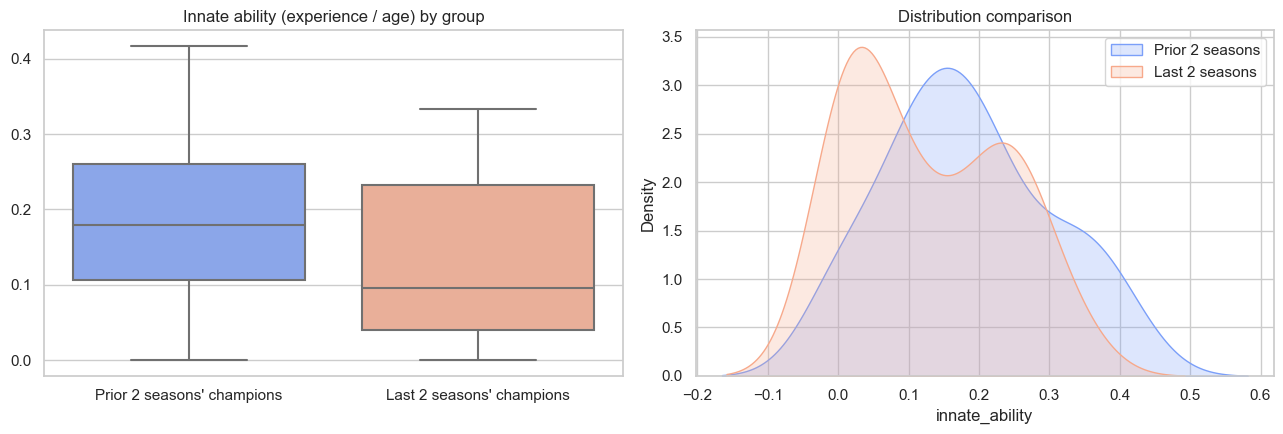

Mean innate ability, prior 2 seasons' champions: 0.1838
Mean innate ability, last 2 seasons' champions:  0.1260


In [214]:
# compare the two groups' innate-ability distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=[group_prior["innate_ability"], group_recent["innate_ability"]], ax=axes[0], palette=[Blue, Orange])
axes[0].set_xticklabels(["Prior 2 seasons' champions", "Last 2 seasons' champions"])
axes[0].set_title("Innate ability (experience / age) by group")

sns.kdeplot(group_prior["innate_ability"], fill=True, label="Prior 2 seasons", color=Blue, ax=axes[1])
sns.kdeplot(group_recent["innate_ability"], fill=True, label="Last 2 seasons", color=Orange, ax=axes[1])
axes[1].set_title("Distribution comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean innate ability, prior 2 seasons' champions: {group_prior['innate_ability'].mean():.4f}")
print(f"Mean innate ability, last 2 seasons' champions:  {group_recent['innate_ability'].mean():.4f}")

In [215]:
alpha = 0.05

shapiro_p_recent = stats.shapiro(group_recent["innate_ability"]).pvalue
shapiro_p_prior = stats.shapiro(group_prior["innate_ability"]).pvalue
print(f"Shapiro (last 2 seasons' champions):  p = {shapiro_p_recent:.4g}")
print(f"Shapiro (prior 2 seasons' champions): p = {shapiro_p_prior:.4g}")

Shapiro (last 2 seasons' champions):  p = 0.001088
Shapiro (prior 2 seasons' champions): p = 0.1234


In [216]:
stat, p = stats.mannwhitneyu(group_recent["innate_ability"], group_prior["innate_ability"],
                                  alternative="greater")
test_used = "Mann-Whitney U (one-sided: recent > prior)"
print(f"\nMann-Whitney U (one-sided: recent > prior) used.")
print(f"statistic = {stat:.4f}, p = {p:.4g}")


Mann-Whitney U (one-sided: recent > prior) used.
statistic = 633.5000, p = 0.9802


**Result:** p >= alpha, fail to reject H0 — no significant evidence for the expert's claim in this specific example.

- This tests one specific example (one team's roster, twice), not the general claim about society or the league as a whole — even a clear result here would only support the claim's illustration, not prove the broader statement.
- A champion roster's experience mix is shaped by team-building strategy (a team can win by combining a few veteran stars with young role players), not just by how much "innate ability" individual players have converted to skill — the metric conflates roster construction with individual development.
- experience_at_season uses nba_debut as the start of a career; it does not account for time missed to injury or time spent outside the NBA (overseas, G League), so it is a reasonable but imperfect proxy for actual playing experience.
- With only two seasons per group, the sample size is small and roster-dependent — a different pair of seasons or a different champion could change the conclusion.

---
# Descriptive Statistics

Three concrete questions are answered below using direct SQL queries against the `nba`
database, each followed by the relevant visualization and a short interpretation.



## 1. Height Distribution: MVP Vote List vs. Top 50 Players

**Objective**

This section compares the height distribution of players who appeared in the MVP voting
list with the Top 50 ranked players, across the 2019-20 to 2023-24 seasons. The goal is to
see whether players who receive MVP consideration are systematically taller than a broader
pool of highly-ranked players.


In [173]:
top50_seasons = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
top50_frames = []

try:
    for season in top50_seasons:
        query_top50_season = f"""
            SELECT
                p.name, 
                p.height_cm, 
                s.season
            FROM player_season_stats AS pss
            JOIN players AS p ON pss.player_id = p.player_id
            JOIN seasons AS s ON pss.season_id = s.season_id
            WHERE s.season = '{season}'
            ORDER BY pss.rank ASC
            LIMIT 50;
        """
        top50_frames.append(pd.read_sql(query_top50_season, con=engine))

    df_top50 = pd.concat(top50_frames, ignore_index=True)
    display(df_top50)
except Exception as e:
    print(e)

,name,height_cm,season
0,James Harden,196,2019-20
1,Damian Lillard,188,2019-20
2,Devin Booker,196,2019-20
3,Giannis Antetokounmpo,211,2019-20
4,Trae Young,188,2019-20
...,...,...,...
245,Jordan Poole,193,2023-24
246,Michael Porter Jr.,208,2023-24
247,Jalen Williams,196,2023-24
248,Joel Embiid,213,2023-24


**Sanity check** — quick look at the raw `players` / `teams` tables.

In [174]:
try:
    query_mvp = """
        SELECT
            p.name,
            p.height_cm,
            s.season,
            pss.position
        FROM mvp AS m
        JOIN players AS p ON m.player_id = p.player_id
        JOIN seasons AS s ON m.season_id = s.season_id
        JOIN player_season_stats AS pss ON pss.player_id = m.player_id AND pss.season_id = m.season_id
        WHERE s.season IN ('2019-20', '2020-21', '2021-22', '2022-23', '2023-24');
    """
    df_mvp = pd.read_sql(query_mvp, con=engine)
    display(df_mvp)
except Exception as e:
    print(e)

,name,height_cm,season,position
0,Giannis Antetokounmpo,211,2019-20,PF
1,LeBron James,206,2019-20,PG
2,James Harden,196,2019-20,SG
3,Luka DonAiA,203,2019-20,PG
4,Kawhi Leonard,198,2019-20,SF
...,...,...,...,...
58,Jalen Brunson,188,2023-24,PG
59,Jayson Tatum,203,2023-24,PF
60,Anthony Edwards,193,2023-24,SG
61,Domantas Sabonis,208,2023-24,C


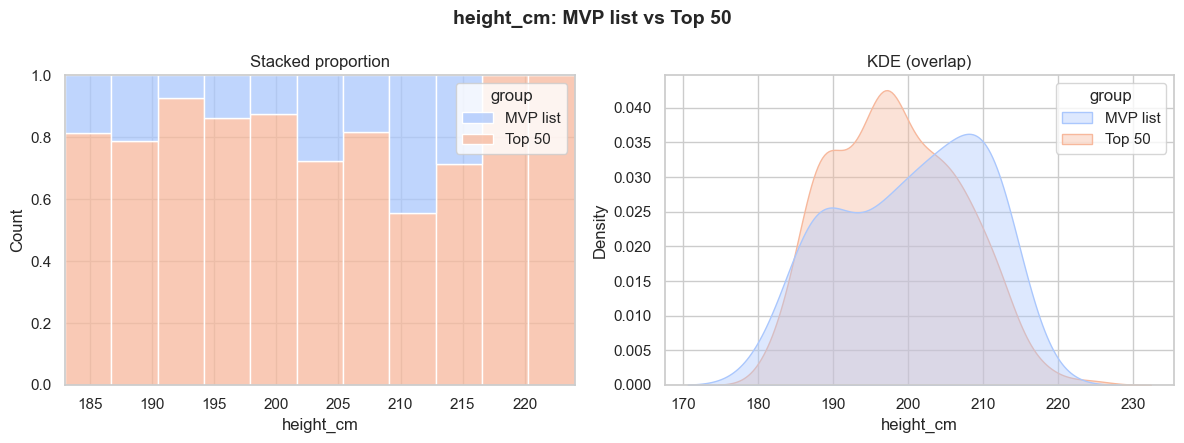

count     63.000000
mean     200.444444
std        9.409634
min      183.000000
25%      191.500000
50%      203.000000
75%      209.500000
max      216.000000
Name: height_cm, dtype: float64
count    250.00000
mean     198.40000
std        8.40348
min      183.00000
25%      193.00000
50%      198.00000
75%      206.00000
max      224.00000
Name: height_cm, dtype: float64


In [183]:
def compare_height(df1, df2, col='height_cm', label1='MVP list', label2='Top 50'):
    d1 = df1[[col]].copy(); d1['group'] = label1
    d2 = df2[[col]].copy(); d2['group'] = label2
    combined = pd.concat([d1, d2], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.suptitle(f'{col}: {label1} vs {label2}', fontsize=14, fontweight='bold')

    sns.histplot(data=combined, x=col, hue='group', multiple='fill',
                 palette='coolwarm', ax=axes[0])
    axes[0].set_title('Stacked proportion')

    sns.kdeplot(data=combined, x=col, hue='group', fill=True,
                common_norm=False, palette='coolwarm', alpha=0.4, ax=axes[1])
    axes[1].set_title('KDE (overlap)')

    plt.tight_layout()
    plt.show()

compare_height(df_mvp, df_top50, col='height_cm', label1='MVP list', label2='Top 50')

print(df_mvp['height_cm'].describe())
print(df_top50['height_cm'].describe())


**Visualization** — height distribution, champion team vs. Top 15, per season.

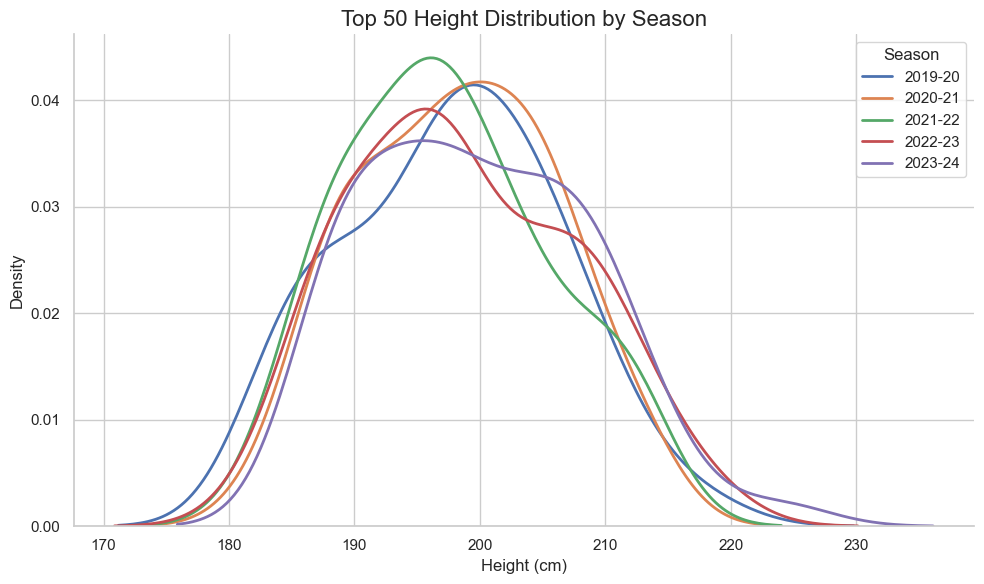

In [161]:
fig, ax = plt.subplots(figsize=(10, 6))

seasons = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']

for season in seasons:
    top50 = df_top50[df_top50['season'] == season]

    sns.kdeplot(
        data=top50,
        x="height_cm",
        fill=False,
        linewidth=2,
        label=season,
        ax=ax,
        warn_singular=False  
    )

ax.set_title("Top 50 Height Distribution by Season", fontsize=16)
ax.set_xlabel("Height (cm)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(title="Season")

sns.despine()
plt.tight_layout()
plt.show()

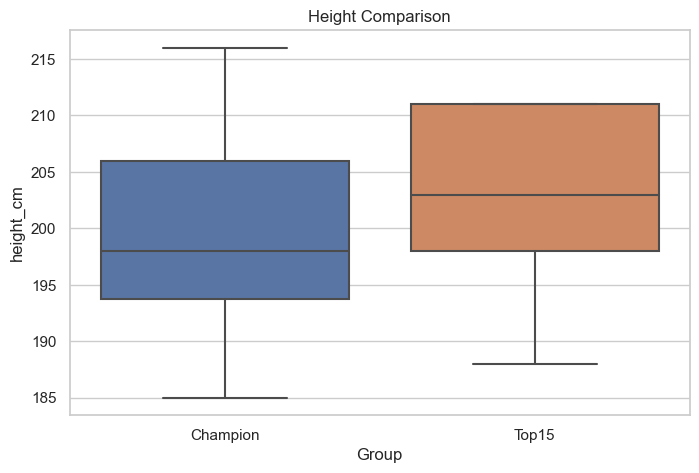

In [176]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=pd.concat([
        df_champ_2023_24.assign(Group='Champion'),
        df_top15_2023_24.assign(Group='Top15')
    ]),
    x='Group',
    y='height_cm'
)

plt.title("Height Comparison")
plt.show()

### Interpretation

Height tends to be similar between the two groups in both seasons, since both groups are
made up of high-level NBA players regardless of team. Experience, however, is typically
where the groups diverge: the full championship roster includes younger, lower-experience
role players alongside its stars, while the Top 15 group is composed almost entirely of
proven, experienced stars. This suggests a championship is built from a mix of star talent
and complementary young players, rather than from a uniformly veteran roster.


## 2. Champion Team vs. Top 15 Players — Height & Experience

**Objective**

This section compares the height and experience of the *active* roster of the NBA championship team in the last two available seasons against the Top 15 ranked players of the same seasons. Since this notebook's data only covers seasons 2019-20 through 2023-24 (see Part 2 intro), "the last two seasons" here means **2022-23 and 2023-24** — not 2024-25/2025-26, which are outside the stated data range and would silently return empty results against this dataset. This shows whether championship teams rely on a more experienced (or physically different) group of players than the league's individual top performers.

In [185]:
SEASONS_RECENT = ['2022-23', '2023-24']  

def get_champion_roster(season):
    query = f"""
        SELECT p.name, p.height_cm, p.experience_years, s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        WHERE s.season = '{season}'
          AND p.is_active = TRUE
          AND pss.team_id = s.champion_team_id;
    """
    with pymysql.connect(**config) as cnxn:
        return pd.read_sql(query, cnxn).drop_duplicates(subset=['name'])

def get_top15(season):
    query = f"""
        SELECT p.name, p.height_cm, p.experience_years, s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        WHERE pss.rank <= 15
          AND s.season = '{season}'
          AND p.is_active = TRUE
        ORDER BY pss.rank ASC;
    """
    with pymysql.connect(**config) as cnxn:
        return pd.read_sql(query, cnxn).drop_duplicates(subset=['name'])

try:
    df_champ_2022_23 = get_champion_roster('2022-23')
    df_champ_2023_24 = get_champion_roster('2023-24')
    df_top15_2022_23 = get_top15('2022-23')
    df_top15_2023_24 = get_top15('2023-24')
except Exception as e:
    print(e)

df_champ_2022_23
df_top15_2022_23
df_champ_2023_24
df_top15_2023_24

name 'config' is not defined


,name,height_cm,experience_years,season
0,Nikola JokiA,211,11,2023-24
1,Shai Gilgeous-Alexander,198,8,2023-24
2,Luka DonAiA,203,8,2023-24
3,Giannis Antetokounmpo,211,13,2023-24
4,Jalen Brunson,188,8,2023-24
5,Jayson Tatum,203,9,2023-24
6,Anthony Edwards,193,6,2023-24
7,Domantas Sabonis,208,10,2023-24
8,Kevin Durant,211,18,2023-24


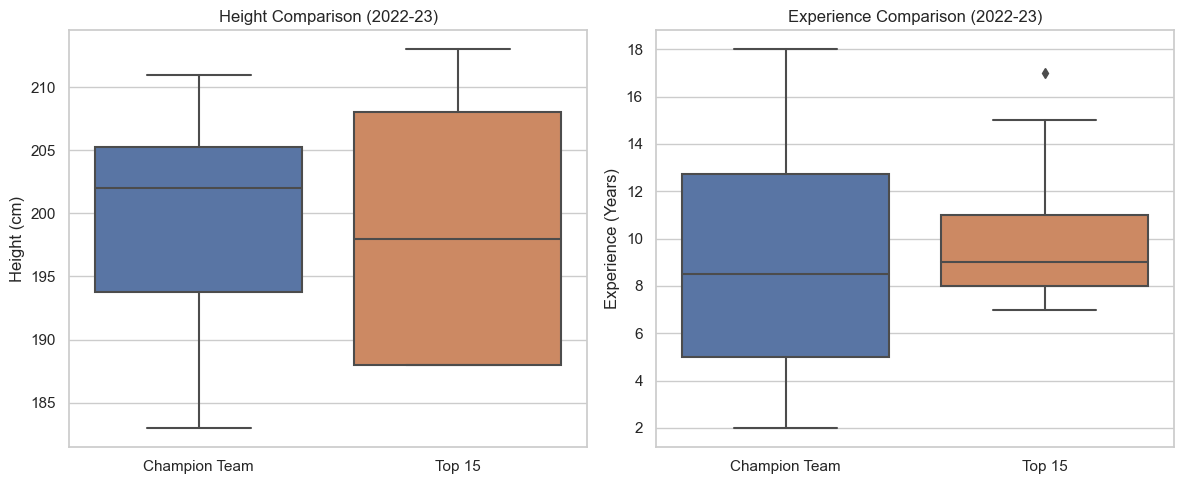

In [186]:
df = pd.concat([
    df_champ_2022_23.assign(Group="Champion Team"),
    df_top15_2022_23.assign(Group="Top 15")
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Height
sns.boxplot(data=df, x="Group", y="height_cm", ax=axes[0])
axes[0].set_title("Height Comparison (2022-23)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Height (cm)")

# Experience
sns.boxplot(data=df, x="Group", y="experience_years", ax=axes[1])
axes[1].set_title("Experience Comparison (2022-23)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Experience (Years)")

plt.tight_layout()
plt.show()

**SQL Queries — Top 15 ranked players, both seasons**

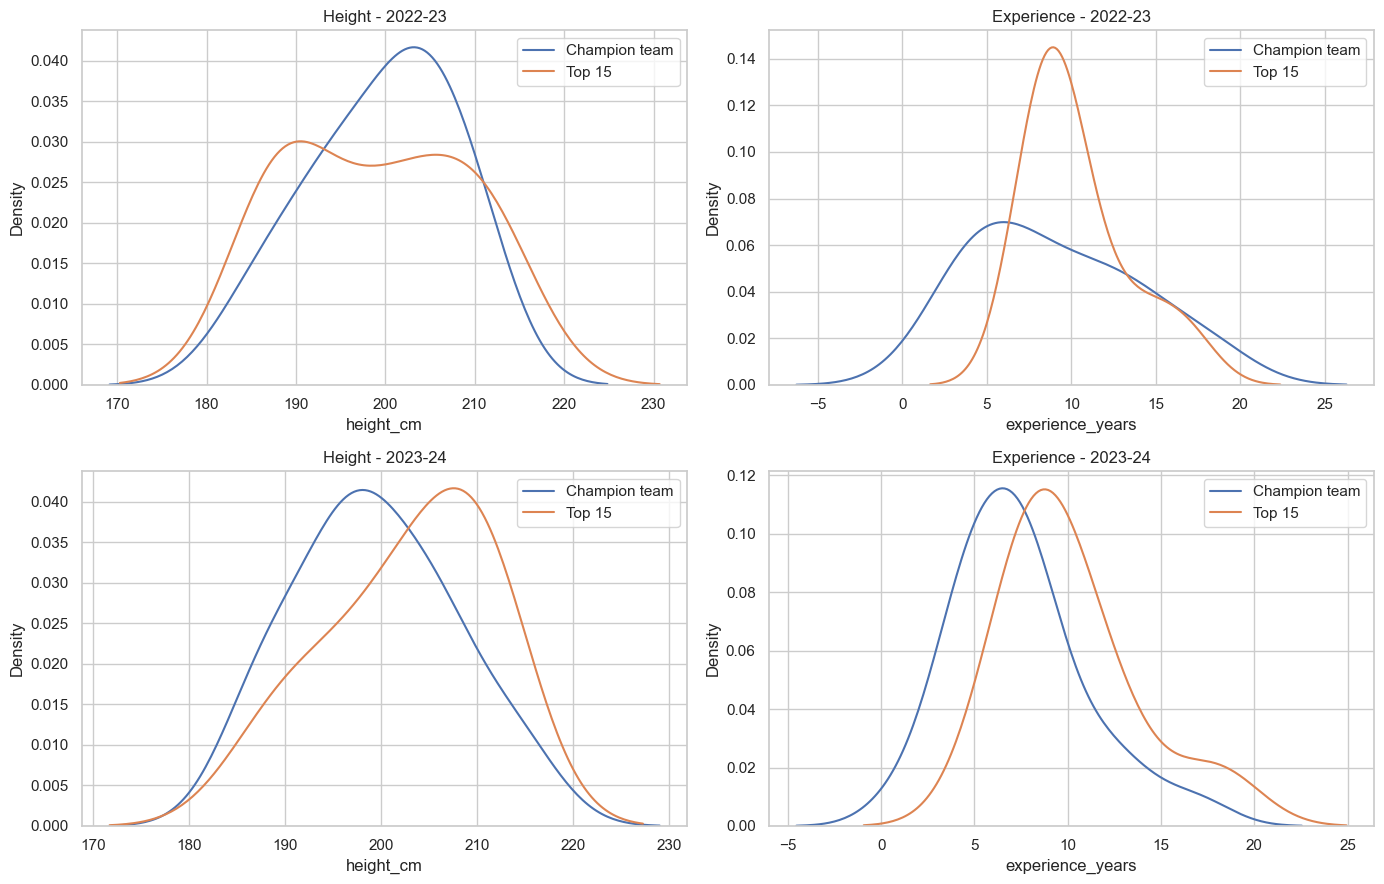

In [187]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 2022-23
sns.kdeplot(df_champ_2022_23["height_cm"], label="Champion team", ax=axes[0,0])
sns.kdeplot(df_top15_2022_23["height_cm"], label="Top 15", ax=axes[0,0])
axes[0,0].set_title("Height - 2022-23")
axes[0,0].legend()

sns.kdeplot(df_champ_2022_23["experience_years"], label="Champion team", ax=axes[0,1])
sns.kdeplot(df_top15_2022_23["experience_years"], label="Top 15", ax=axes[0,1])
axes[0,1].set_title("Experience - 2022-23")
axes[0,1].legend()

# 2023-24
sns.kdeplot(df_champ_2023_24["height_cm"], label="Champion team", ax=axes[1,0])
sns.kdeplot(df_top15_2023_24["height_cm"], label="Top 15", ax=axes[1,0])
axes[1,0].set_title("Height - 2023-24")
axes[1,0].legend()

sns.kdeplot(df_champ_2023_24["experience_years"], label="Champion team", ax=axes[1,1])
sns.kdeplot(df_top15_2023_24["experience_years"], label="Top 15", ax=axes[1,1])
axes[1,1].set_title("Experience - 2023-24")
axes[1,1].legend()

plt.tight_layout()
plt.show()

## 3. Point Guard Recommendation for the Club

**Objective**

The club wants to sign a Point Guard. Player quality is measured by presence in the MVP
voting list between the 2019-20 and 2023-24 seasons. The goal is to identify the most
consistently elite, currently active Point Guards and recommend the top three candidates.

In [38]:
try:
    query_pg = """
        SELECT p.name, p.is_active, s.season, pss.position
        FROM mvp AS m
        JOIN players AS p ON m.player_id = p.player_id
        JOIN seasons AS s ON m.season_id = s.season_id
        JOIN player_season_stats AS pss ON pss.player_id = m.player_id AND pss.season_id = m.season_id
        WHERE s.season IN ('2019-20','2020-21','2021-22','2022-23','2023-24');
    """
    df_mvp_pg = pd.read_sql(query_pg, con=engine)


    filtered = df_mvp_pg[df_mvp_pg['position'].str.contains('PG', na=False)]


    filtered_active = filtered[filtered['is_active'] == 1]

    presence_count = filtered_active.pivot_table(index='name', values='season', aggfunc='count')
    presence_count = presence_count.rename(columns={'season': 'appearances_in_seasons'}).reset_index()
    presence_count = presence_count.sort_values('appearances_in_seasons', ascending=False)

    active_candidates = presence_count.head(3)
    display(active_candidates)
except Exception as e:
    print(e)

,name,appearances_in_seasons
6,Luka DonAiA,5
9,Stephen Curry,3
0,Damian Lillard,2


### Final Recommendation

Based on the number of appearances in the MVP voting list (and, as a tiebreaker, average
vote share and best rank achieved), the top three currently-active Point Guard candidates
are shown in `active_candidates` above. These players have demonstrated the most consistent,
elite-level impact among Point Guards over the last five seasons, making them the strongest
candidates for acquisition.

# Part 3 — Hypothesis Testing

Statistical hypothesis testing is used to determine whether observed differences between groups are statistically significant, rather than plausibly due to random chance. Both hypotheses assigned in the project statement are covered below: **Hypothesis 1** (player agility) and **Hypothesis 2** (innate ability of championship-team players).

## Hypothesis 1 — Has Player Agility Increased?

---
## Has Player Agility Increased Over Time?

**Claim:** it is believed that the average *agility* of players among the top 20 ranked players each season has increased compared to the past. Agility here is defined as the **height-to-weight ratio** (`height_cm / weight_kg`) -- a higher ratio means more height per unit of body mass, i.e. a leaner build typically associated with quicker, more agile movement.

**Research question:** the Top-20 lists for different seasons naturally differ in personnel, so any change in average agility between two time windows could be due to real change in player build/athleticism, or could just as easily be sampling noise from a small, changing group of ~20-40 players per window. A hypothesis test is needed to tell those two explanations apart before concluding anything about a league-wide trend.

**H0 (null hypothesis):** the mean agility (height/weight) of Top-20 players in the recent window (2022-23, 2023-24) is **less than or equal to** the mean agility of Top-20 players in the earlier window (2020-21, 2021-22) (μ_recent ≤ μ_previous).

**H1 (alternative hypothesis):** the mean agility of Top-20 players in the recent window is **greater than** that of the earlier window (μ_recent > μ_previous) -- a one-sided test, matching the direction of the claim.

**Test plan:**
1. Pull `height_cm` and `weight_kg` for players ranked in the Top 20 of each relevant season (`player_season_stats.rank <= 20`).
2. Group seasons into two windows: **Previous** = 2020-21 & 2021-22, **Recent** = 2022-23 & 2023-24 (per the project statement).
3. Compute `agility = height_cm / weight_kg` per player-season row.
4. Check normality (Shapiro-Wilk) in each group, then run the appropriate one-sided two-sample test (Welch's t-test if both groups look normal, Mann-Whitney U otherwise).

In [165]:
try:
    query_agility = """
        SELECT p.name, p.height_cm, p.weight_kg, s.season
        FROM player_season_stats AS pss
        JOIN players AS p ON pss.player_id = p.player_id
        JOIN seasons AS s ON pss.season_id = s.season_id
        WHERE pss.rank <= 20
          AND s.season IN ('2020-21', '2021-22', '2022-23', '2023-24');
    """
    df_agility = pd.read_sql(query_agility, con=engine)
except Exception as e:
    print(e)

df_agility['agility'] = df_agility['height_cm'] / df_agility['weight_kg']
df_agility['period'] = df_agility['season'].apply(
    lambda s: 'Recent' if s in ['2022-23', '2023-24'] else 'Previous')

display(df_agility.head())

,name,height_cm,weight_kg,season,agility,period
0,Stephen Curry,188,83,2020-21,2.265060,Previous
1,Damian Lillard,188,90,2020-21,2.088889,Previous
2,Nikola JokiA,211,128,2020-21,1.648438,Previous
3,Bradley Beal,193,93,2020-21,2.075269,Previous
4,Luka DonAiA,203,104,2020-21,1.951923,Previous


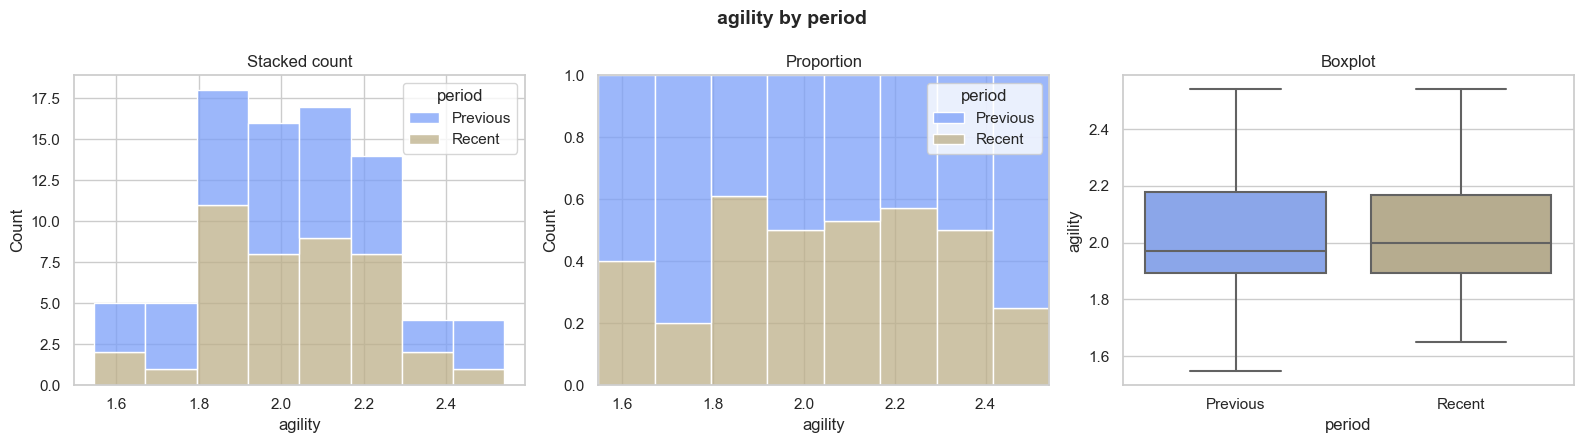

Shapiro group 'Previous': p = 0.5843
Shapiro group 'Recent': p = 0.6211
Normal distribution -> t-test
t = -0.0072, p = 0.9942
Result: Not Significant


0.9942469164466831

In [166]:
numeric_vs_categorical(df_agility, 'agility', 'period')

### Statistical Conclusion

Read the one-sided test's `p`-value from the `numeric_vs_categorical` output above (H1: recent Top-20 agility > previous Top-20 agility). If `p < 0.05`, reject H0 in favor of H1 -- the data support the claim that agility has increased for this specific comparison. Otherwise, fail to reject H0: no significant evidence of an increase.

- This tests one specific pair of two-season windows among Top-20 players, not a claim about the whole league or about "true" athletic agility (which depends on speed, reflexes, and coordination -- not just a static height/weight ratio).
- Height and weight are the *current*, not season-specific, values in the `players` table, so a player who changed weight significantly across their career would be represented by the same figure in both windows if they appear in both Top-20 lists.
- The Top-20 group composition changes year to year, so the comparison is really between two overlapping-but-different samples of players, not a repeated-measures comparison of the same individuals over time.

## Hypothesis 2 — Has Players' "Innate Ability" Improved?

---
## Has Players' "Innate Ability" Improved? (Champion-Team Case Study)

**Claim:** an expert argues that, thanks to modern progress and better conditions, people's ability to develop and express their innate talent has improved compared to the past. As supporting evidence, the expert claims that the average *innate ability* of the players on the championship-winning team is higher in the **last 2 seasons** than it was **2 seasons before that**. The expert defines *innate ability* as **experience relative to age** (experience ÷ age) — the idea being that someone who has accumulated more career experience per year of life has converted more of their life into skill.

**Test plan:**
1. Find the champion team for each of the 4 most recent seasons that have a recorded champion (via the `champ` table).
2. Split them into two groups: the **last 2 seasons'** champions vs. the **2 seasons before those**.
3. For each champion team-season, take the players who were active on that roster that season (played at least one game), and compute each player's age and experience *as of that specific season* — not their current age/experience — since the claim is about that season's roster.
4. Compute `innate_ability = experience_at_season / age_at_season` per player and compare the two groups with an appropriate statistical test.

**Note on the experience definition:** the `players` table only stores a player's *current* total `experience_years`, which would be historically inaccurate for a season that already happened (e.g. it would overstate experience in an older season). Instead, experience at a given season is reconstructed as `season_year - nba_debut_year`, which gives the correct, season-specific experience for any point in a player's career.

**Research question:** is there evidence that champion-team players' innate ability (experience ÷ age) genuinely increased in the most recent seasons, or could the observed gap plausibly be due to normal season-to-season roster variation? A hypothesis test is needed because looking at two sample means alone cannot tell us whether a difference this size is meaningful or just noise from a small, roster-dependent sample.

**H0 (null hypothesis):** the mean innate ability of the champion team's active players in the last 2 seasons is **less than or equal to** that of the champion team's active players 2 seasons before (μ_recent ≤ μ_previous).

**H1 (alternative hypothesis):** the mean innate ability of the champion team's active players in the last 2 seasons is **greater than** that of 2 seasons before (μ_recent > μ_previous) -- a one-sided test, matching the direction of the expert's claim.

**Note on season range:** to stay inside this project's stated data window (2019-20 through 2023-24), "last 2 seasons" = **2022-23, 2023-24** and "2 seasons before that" = **2020-21, 2021-22** (the notebook previously used 2024-25/2025-26, which fall outside the available data and would return empty results).

In [167]:
try:
    query_CHABOK = """
    SELECT
        p.name,
        p.experience_years,
        p.birth_date,
        s.season,
        s.season_id,
        t.team_name
    FROM player_season_stats AS pss
    JOIN players AS p ON pss.player_id = p.player_id
    JOIN seasons AS s ON pss.season_id = s.season_id
    JOIN teams AS t ON t.team_id = pss.team_id
    JOIN champ AS c ON c.season_id = s.season_id AND c.team_id = t.team_id
    WHERE s.season IN ('2023-24', '2022-23', '2021-22', '2020-21')
      AND p.is_active = TRUE; 
    """
    df_chabok = pd.read_sql(query_CHABOK, con=engine)
    display(df_chabok)
except Exception as e:
    print(e)

# calculating age & ability, using season-specific experience (not the player's current total)
df_chabok['season_start_year'] = df_chabok['season'].str[:4].astype(int)
df_chabok['birth_date'] = pd.to_datetime(df_chabok['birth_date'])
df_chabok['age'] = df_chabok['season_start_year'] - df_chabok['birth_date'].dt.year
df_chabok['innate_ability'] = df_chabok['experience_years'] / df_chabok['age']

recent_ability = df_chabok[df_chabok['season'].isin(['2023-24', '2022-23'])]['innate_ability'].dropna()
prev_ability   = df_chabok[df_chabok['season'].isin(['2021-22', '2020-21'])]['innate_ability'].dropna()

,name,experience_years,birth_date,season,season_id,team_name
0,Giannis Antetokounmpo,13,1994-12-06,2020-21,2,Milwaukee Bucks
1,Khris Middleton,14,1991-08-12,2020-21,2,Milwaukee Bucks
2,Jrue Holiday,17,1990-06-12,2020-21,2,Milwaukee Bucks
3,Brook Lopez,18,1988-04-01,2020-21,2,Milwaukee Bucks
4,Bobby Portis,11,1995-02-10,2020-21,2,Milwaukee Bucks
5,Donte DiVincenzo,8,1997-01-31,2020-21,2,Milwaukee Bucks
6,Pat Connaughton,11,1993-01-06,2020-21,2,Milwaukee Bucks
7,Jordan Nwora,4,1998-09-09,2020-21,2,Milwaukee Bucks
8,Thanasis Antetokounmpo,7,1992-07-18,2020-21,2,Milwaukee Bucks
9,Sam Merrill,6,1996-05-15,2020-21,2,Milwaukee Bucks


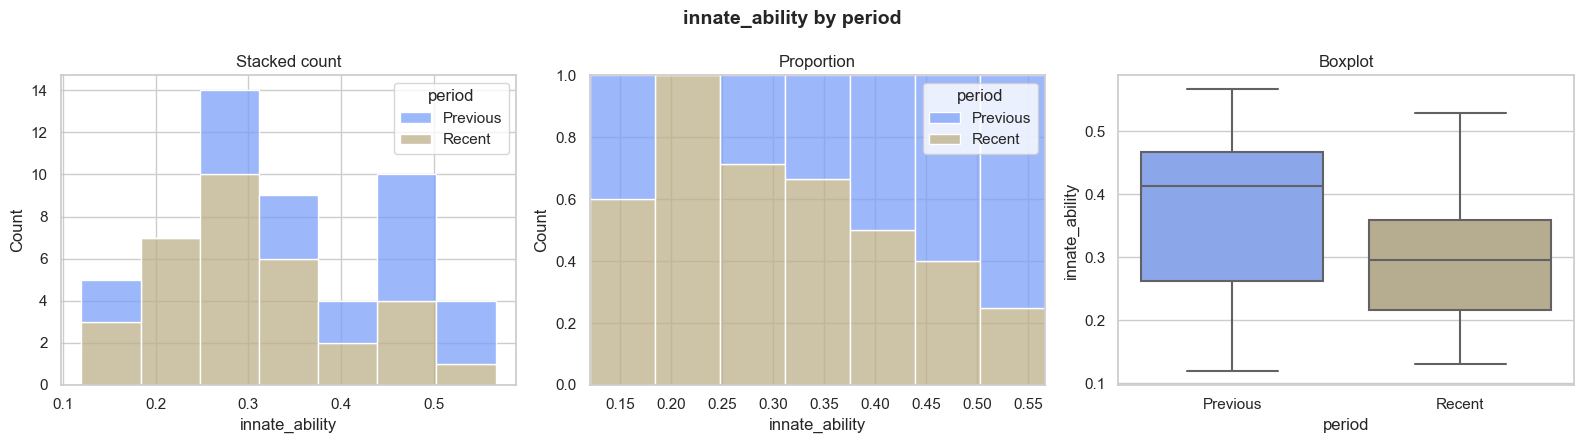

Shapiro group 'Previous': p = 0.4811
Shapiro group 'Recent': p = 0.4043
Normal distribution -> t-test
t = 2.4719, p = 0.01682
Result: Significant


0.016819241732742546

In [168]:
df_chabok['period'] = df_chabok['season'].apply(
    lambda s: 'Recent' if s in ['2023-24', '2022-23'] else 'Previous'
)

numeric_vs_categorical(df_chabok, 'innate_ability', 'period')

### Statistical Conclusion

Read the one-sided test's `p`-value from the `numeric_vs_categorical` output above (H1: recent-champions' innate ability > previous-champions' innate ability).

- This tests one specific example (one team's roster, twice), not the general claim about society or the league as a whole — even a clear result here would only support the claim's illustration, not prove the broader statement.
- A champion roster's experience mix is shaped by team-building strategy (a team can win by combining a few veteran stars with young role players), not just by how much "innate ability" individual players have converted to skill — the metric conflates roster construction with individual development.
- `experience_at_season` uses `nba_debut` as the start of a career; it does not account for time missed to injury or time spent outside the NBA (overseas, G League), so it is a reasonable but imperfect proxy for actual playing experience.
- With only two seasons per group, the sample size is small and roster-dependent — a different pair of seasons or a different champion could change the conclusion.

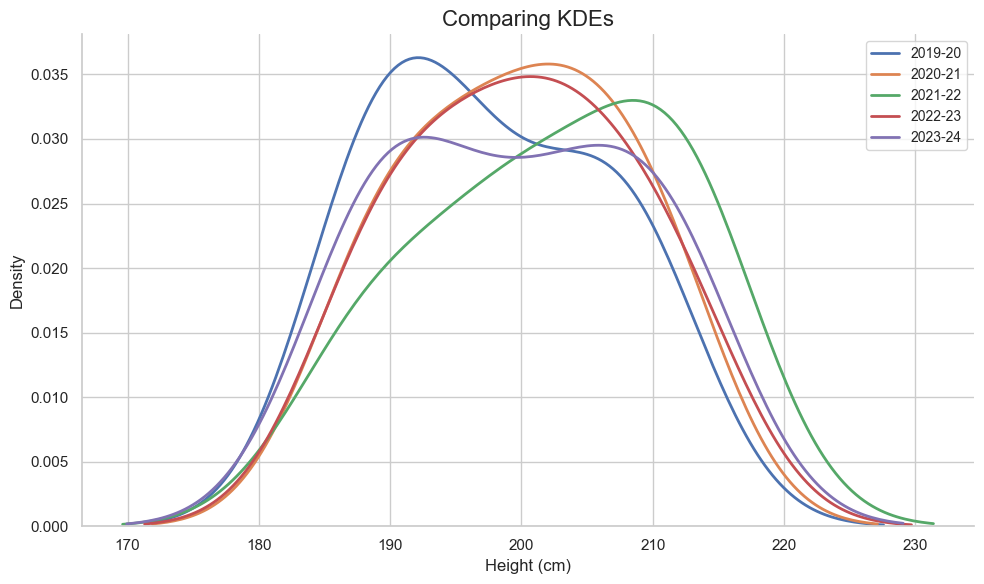

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
seasons = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']

for i in seasons:
    top50=df_top50[df_top50['season']==i]
    finall=top50['height_cm']
    sns.kdeplot(data=finall, fill=False, linewidth=2, label=i, ax=ax)

ax.set_title("Comparing KDEs", fontsize=16)
ax.set_xlabel("Height (cm)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
print(df_mvp.columns.tolist())

['name', 'height_cm', 'season', 'position']


In [169]:
query_mvp = """
    SELECT
        p.name,
        p.height_cm,
        s.season,
        pss.position
    FROM mvp AS m
    JOIN players AS p ON m.player_id = p.player_id
    JOIN seasons AS s ON m.season_id = s.season_id
    JOIN player_season_stats AS pss ON pss.player_id = m.player_id AND pss.season_id = m.season_id
    WHERE s.season IN ('2019-20', '2020-21', '2021-22', '2022-23', '2023-24');
"""

df_mvp = pd.read_sql(query_mvp, engine)


print(df_mvp)
df_mvp.head()

                     name  height_cm   season position
0   Giannis Antetokounmpo        211  2019-20       PF
1            LeBron James        206  2019-20       PG
2            James Harden        196  2019-20       SG
3             Luka DonAiA        203  2019-20       PG
4           Kawhi Leonard        198  2019-20       SF
..                    ...        ...      ...      ...
58          Jalen Brunson        188  2023-24       PG
59           Jayson Tatum        203  2023-24       PF
60        Anthony Edwards        193  2023-24       SG
61       Domantas Sabonis        208  2023-24        C
62           Kevin Durant        211  2023-24       PF

[63 rows x 4 columns]


,name,height_cm,season,position
0,Giannis Antetokounmpo,211,2019-20,PF
1,LeBron James,206,2019-20,PG
2,James Harden,196,2019-20,SG
3,Luka DonAiA,203,2019-20,PG
4,Kawhi Leonard,198,2019-20,SF


**Conclusion:**

The MVP-list group and the Top 50 group typically overlap substantially in height, with the
MVP list skewing a little taller on average — consistent with MVP voting favoring
high-impact forwards/centers, while the Top 50 group spans a wider range of positions
(including shorter guards).

----

## Relationship Between Team Statistics and Wins

Scatterplots are used to examine the relationship between selected team-level statistics and the number of wins.

These visualizations provide an initial assessment of:

- The direction of each relationship
- Whether the relationship appears approximately linear
- The presence of unusual observations
- The suitability of variables for linear regression analysis

Each point represents one team-season observation.
### Selected Explanatory Variables

The following variables are compared with team wins:

- Three-point field goals
- Two-point field goals
- Free throws
- Assists
- Offensive and defensive rebounds
- Turnovers
- Simple Rating System
- Offensive rating

These indicators represent different dimensions of team performance, including scoring, ball movement, rebounding, efficiency, and overall team strength.

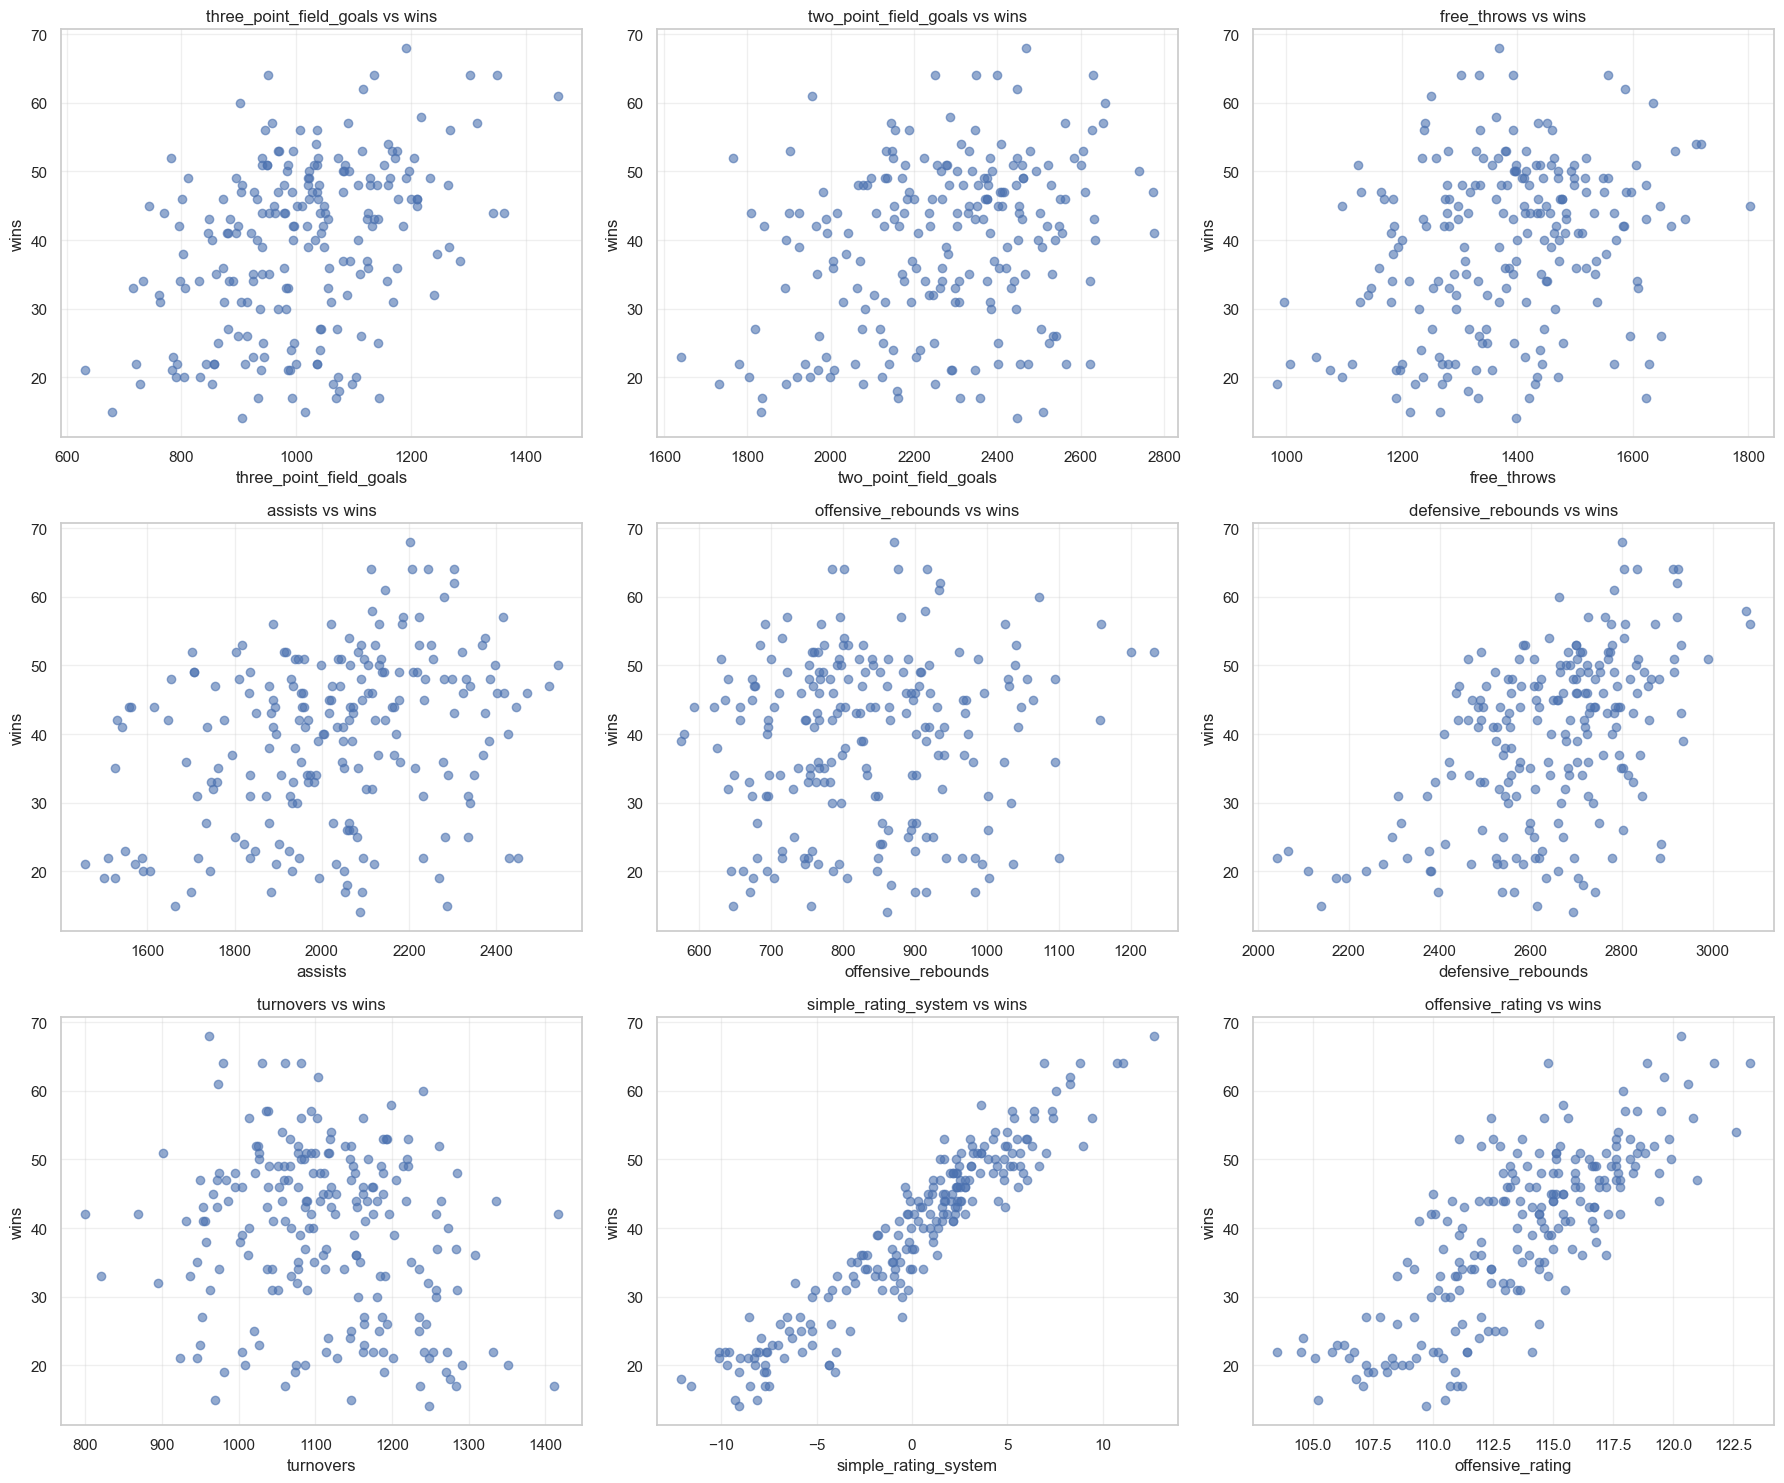

In [129]:
feature_cols = [
    "three_point_field_goals",
    "two_point_field_goals",
    "free_throws",
    "assists",
    "offensive_rebounds",
    "defensive_rebounds",
    "turnovers",
    "simple_rating_system",
    "offensive_rating"
]

plot_features_vs_wins(
    data=team_season_stats,
    feature_cols=feature_cols
)

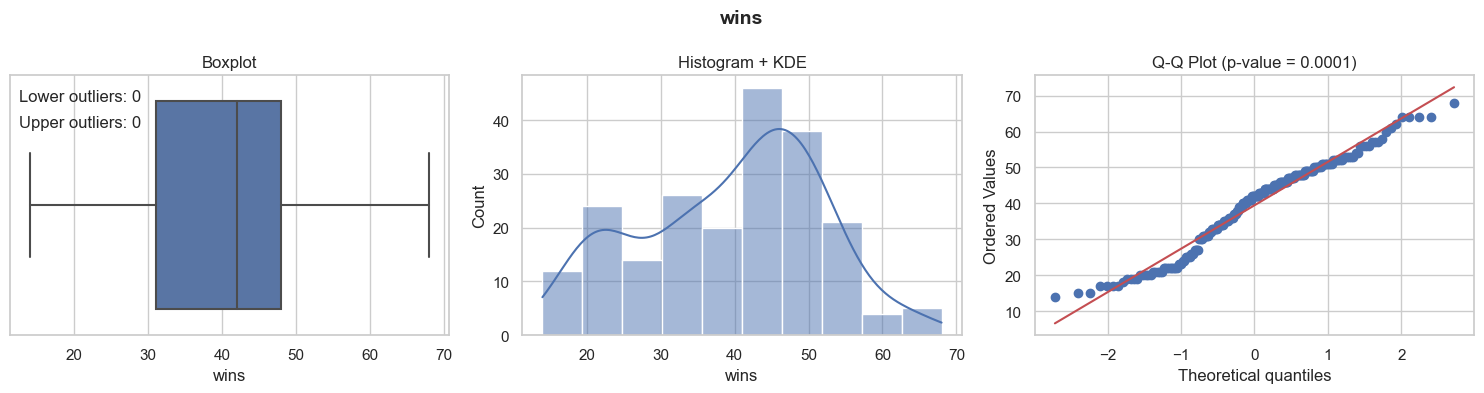

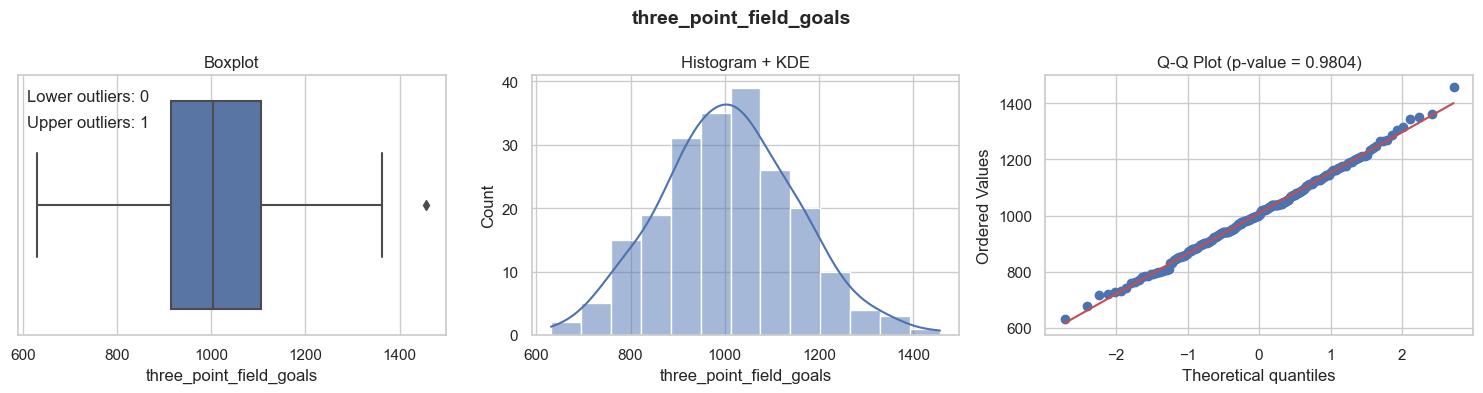

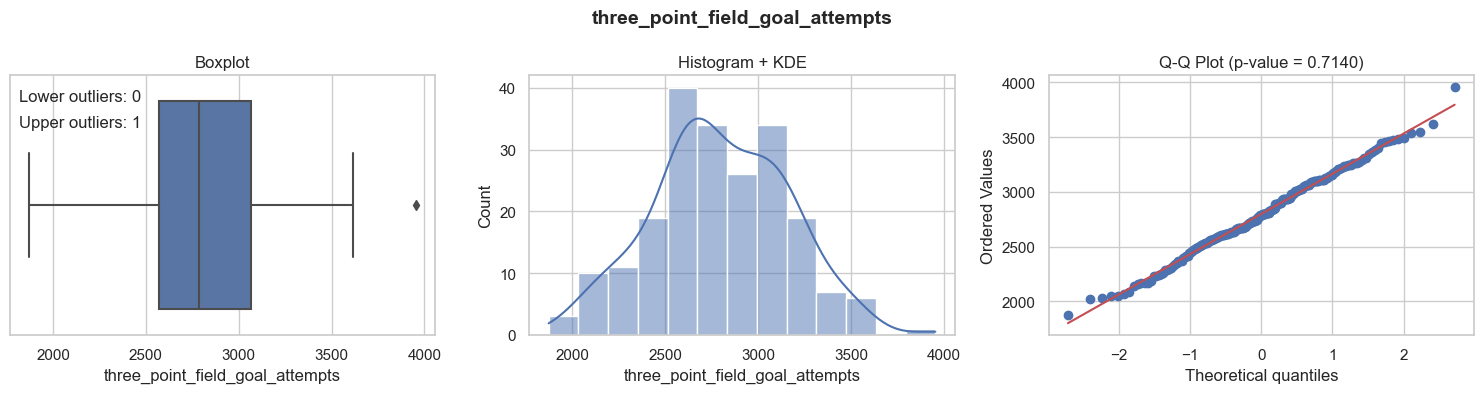

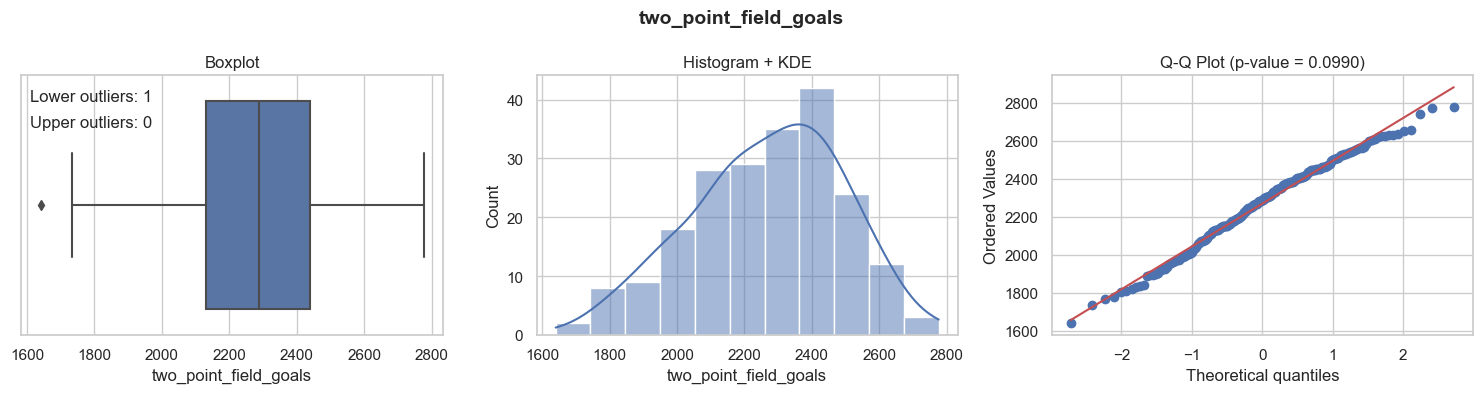

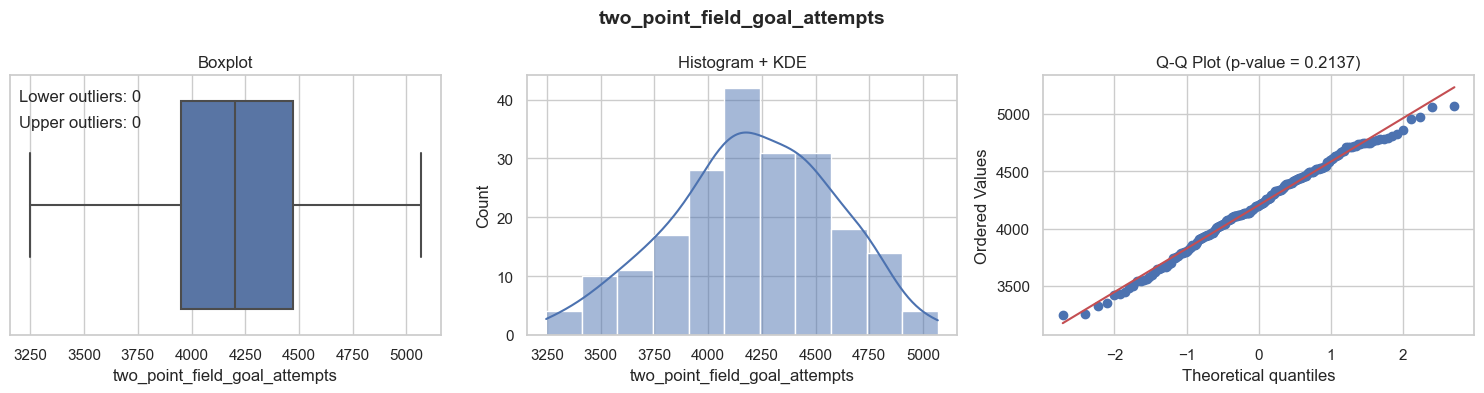

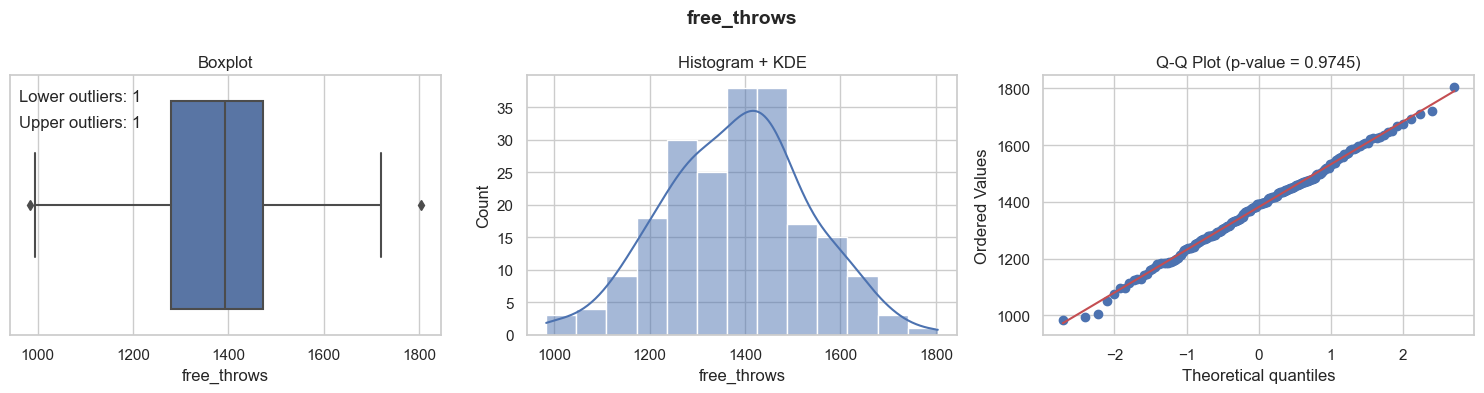

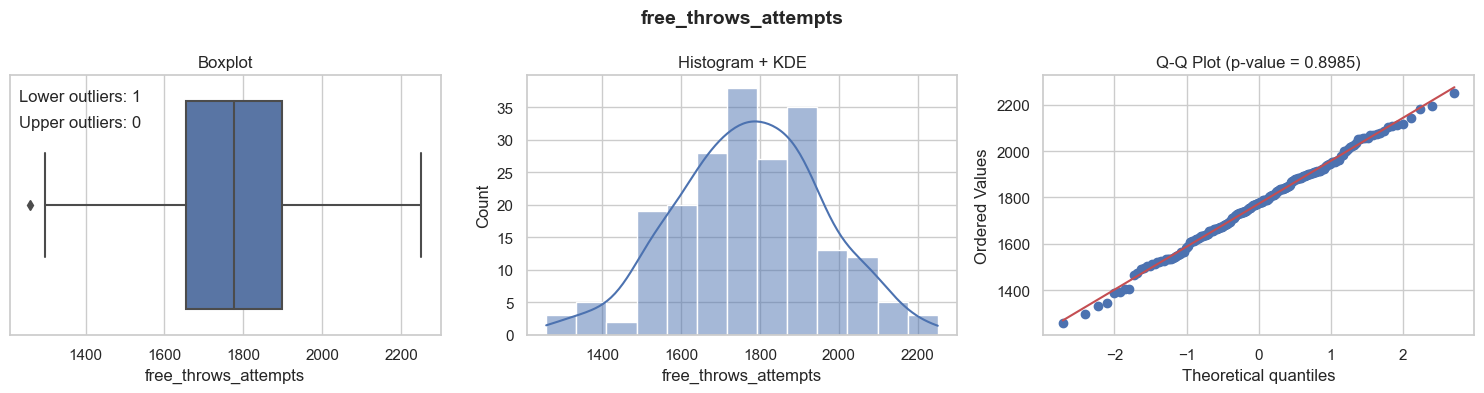

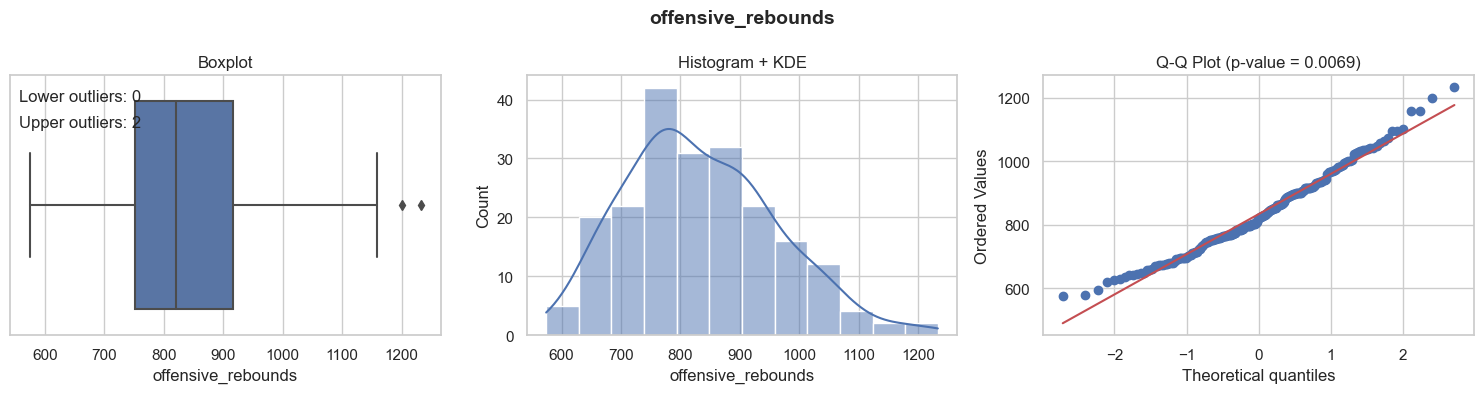

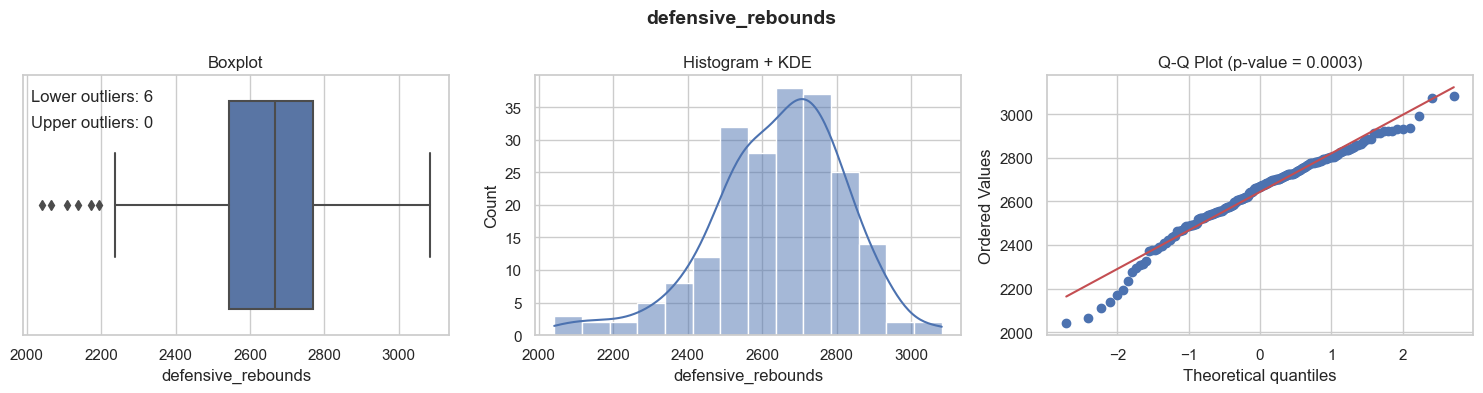

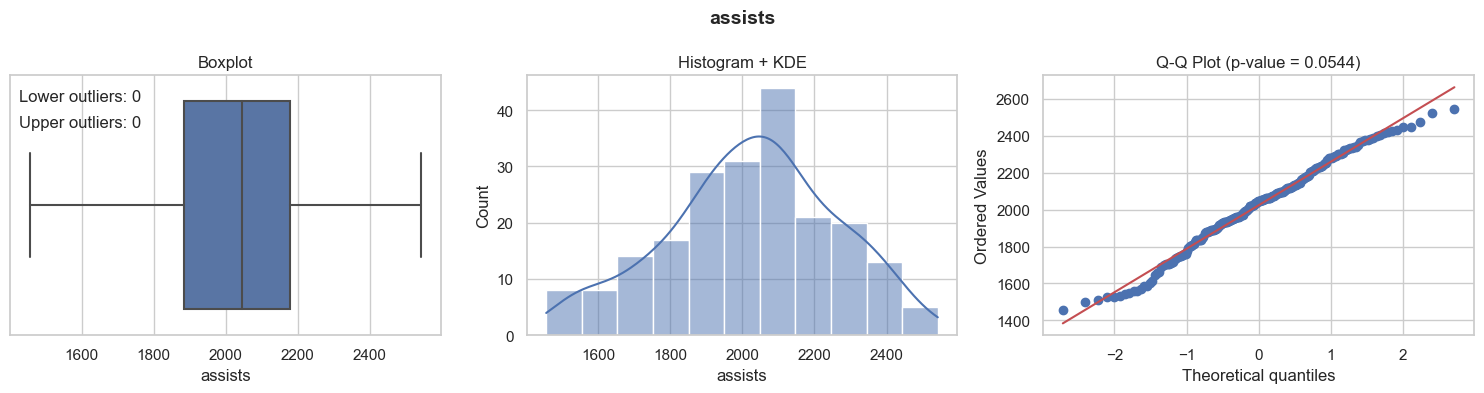

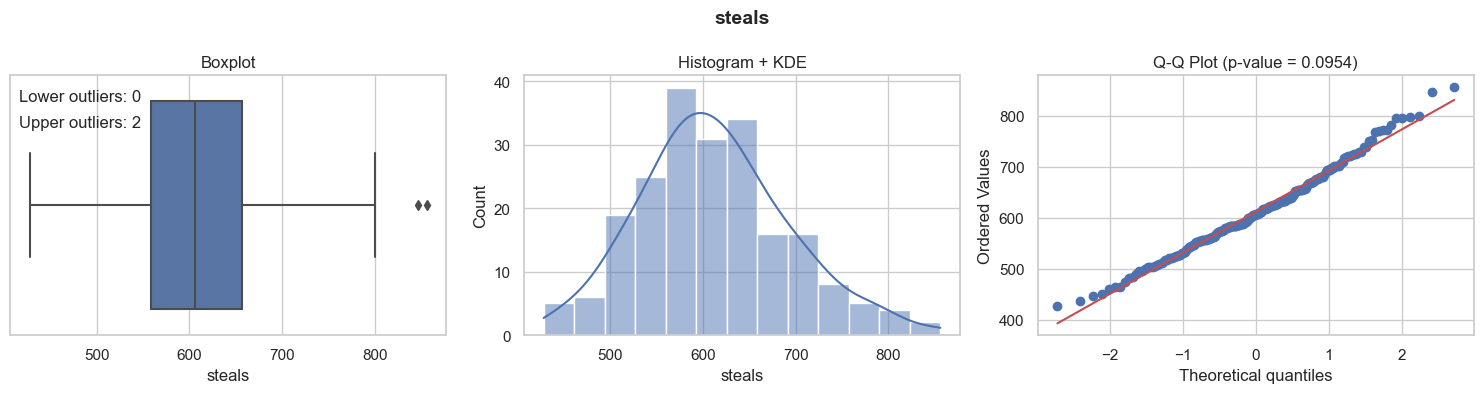

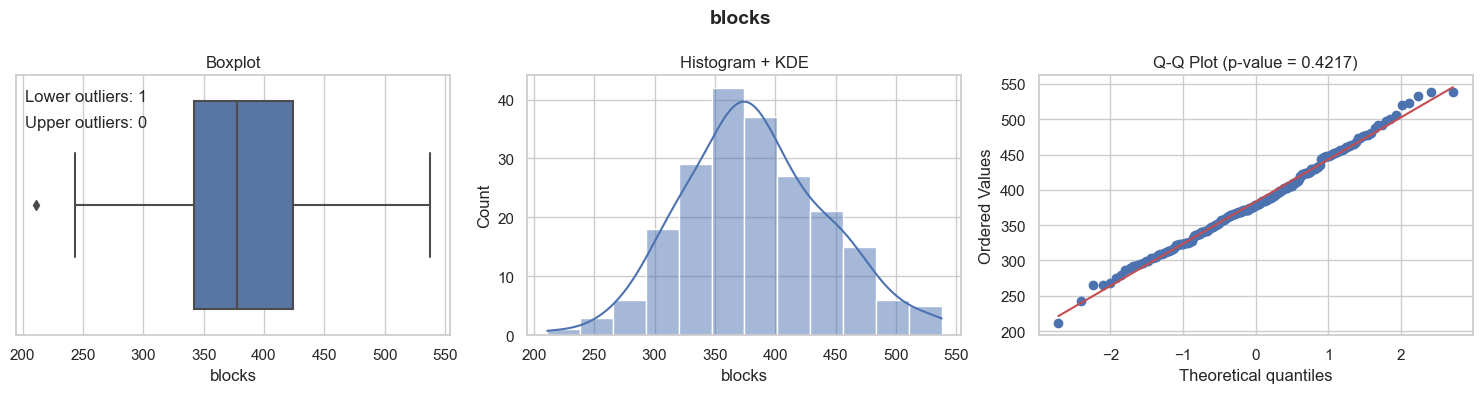

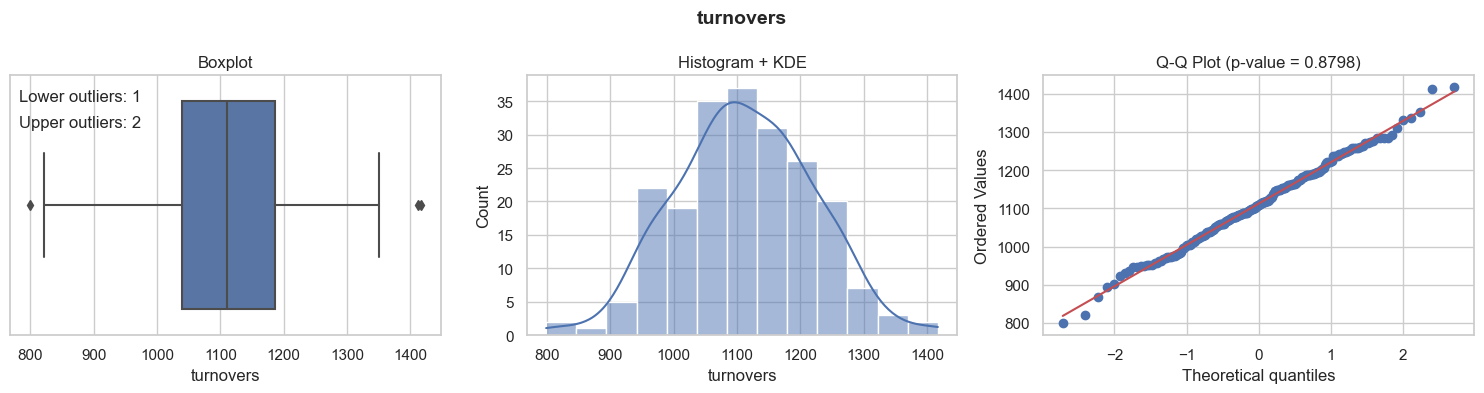

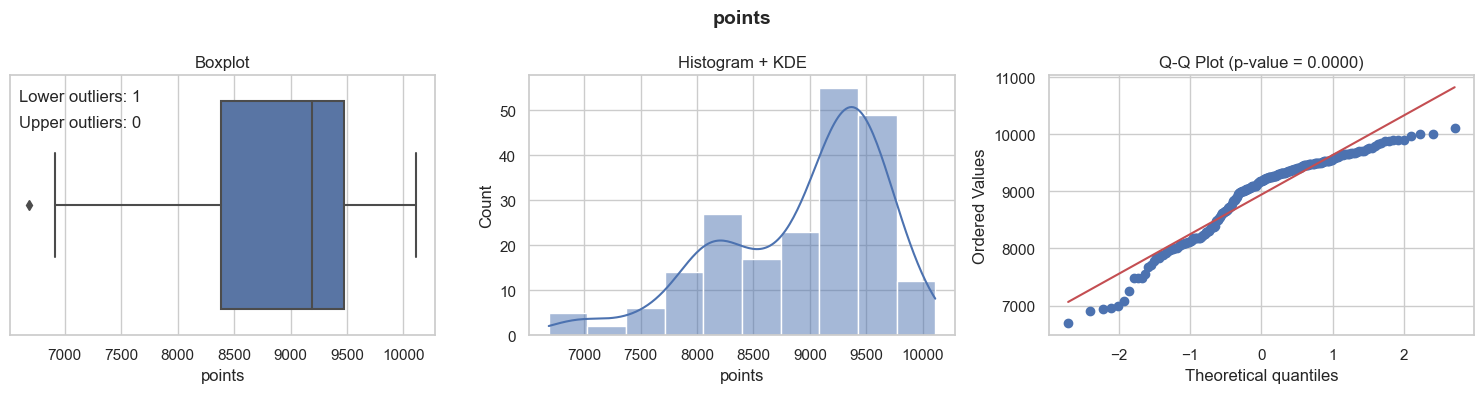

In [140]:
wanted_cols = [
    "wins",
    "three_point_field_goals",
    "three_point_field_goal_attempts",
    "two_point_field_goals",
    "two_point_field_goal_attempts",
    "free_throws",
    "free_throws_attempts",
    "offensive_rebounds",
    "defensive_rebounds",
    "assists",
    "steals",
    "blocks",
    "turnovers",
    "points"
]

for col in wanted_cols:
    overview_numeric(team_season_stats, col)

## Regression Model 1: Traditional Team Statistics

The first multiple linear regression model examines whether traditional team statistics are associated with the number of wins.

The dependent variable is:

- wins

The explanatory variables are:

- Three-point field goals
- Two-point field goals
- Free throws
- Offensive rebounds
- Defensive rebounds
- Assists
- Turnovers
- Average team age

For each explanatory variable, the null hypothesis is that its regression coefficient is equal to zero, meaning that it has no statistically significant linear association with team wins, holding the other variables constant.

In [144]:
model_1 = smf.ols(
    formula="""
        wins ~
        three_point_field_goals +
        two_point_field_goals +
        free_throws +
        offensive_rebounds +
        defensive_rebounds +
        assists +
        turnovers +
        average_age
    """,
    data=team_season_stats
).fit()

print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                   wins   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     33.87
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           1.93e-33
Time:                        21:58:46   Log-Likelihood:                -732.78
No. Observations:                 210   AIC:                             1484.
Df Residuals:                     201   BIC:                             1514.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## Regression Model 2: Advanced Team Performance Indicators

The second regression model focuses on advanced team-level performance measures.

The explanatory variables are:

- pace: estimated number of possessions per game
- offensive_rating: points scored per 100 possessions
- simple_rating_system: an overall rating that accounts for point differential and strength of schedule

This model evaluates whether team speed, offensive efficiency, and overall team quality are associated with the number of wins.

In [145]:
model_2 = smf.ols(
    formula="""
        wins ~
        pace +
        offensive_rating +
        simple_rating_system
    """,
    data=team_season_stats
).fit()

print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   wins   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     693.9
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          2.25e-107
Time:                        21:59:00   Log-Likelihood:                -569.63
No. Observations:                 210   AIC:                             1147.
Df Residuals:                     206   BIC:                             1161.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               17.5248 

## Regression Model 3: Overall and Relative Offensive Strength

The third regression model examines the combined relationship of:

- simple_rating_system
- relative_offensive_rating

with team wins.

Relative offensive rating measures a team's offensive performance compared with the league average. Including it alongside the Simple Rating System helps determine whether relative offensive strength provides additional explanatory information beyond the team's overall rating.

In [146]:
model_3 = smf.ols(
    formula="""
        wins ~
        simple_rating_system +
        relative_offensive_rating
    """,
    data=team_season_stats
).fit()

print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:                   wins   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     896.8
Date:                Tue, 21 Jul 2026   Prob (F-statistic):          1.07e-102
Time:                        21:59:08   Log-Likelihood:                -584.21
No. Observations:                 210   AIC:                             1174.
Df Residuals:                     207   BIC:                             1184.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

---
# The Road Ahead

This notebook is by no means exhaustive. Due to time constraints we were unable to explore every idea we had in mind.  
Here are some other paths worth investigating.